In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')


In [2]:
import pandas as pd

# Load the data
Kintampo = pd.read_csv('KINTAMPO_1991_2023.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
Kintampo[['day', 'month', 'year']] = Kintampo['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
Kintampo['day'] = Kintampo['day'].astype(int)
Kintampo['month'] = Kintampo['month'].astype(int)
Kintampo['year'] = Kintampo['year'].astype(int)
Kintampo = Kintampo.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in Kintampo.columns if col not in ['day', 'month', 'year']]
Kintampo = Kintampo[columns_order]

# Load the data
Navrongo = pd.read_csv('NAVRONGO_1991_2023.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
Navrongo[['day', 'month', 'year']] = Navrongo['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
Navrongo['day'] = Navrongo['day'].astype(int)
Navrongo['month'] = Navrongo['month'].astype(int)
Navrongo['year'] = Navrongo['year'].astype(int)
Navrongo = Navrongo.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in Navrongo.columns if col not in ['day', 'month', 'year']]
Navrongo = Navrongo[columns_order]


# Load the data
Tema = pd.read_csv('ASKA_1991_2023.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
Tema[['day', 'month', 'year']] = Tema['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
Tema['day'] = Tema['day'].astype(int)
Tema['month'] = Tema['month'].astype(int)
Tema['year'] = Tema['year'].astype(int)
Tema = Tema.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in Tema.columns if col not in ['day', 'month', 'year']]
Tema = Tema[columns_order]


In [3]:
Kintampo

,day,month,year,Tmin,Tmax,Tmean,Rain,RH,UTCI,Humidex,HI
0,1,1,1991,16.80,30.72,23.76,0.0,26.61,19.90,31.69,29.19
1,2,1,1991,15.71,31.49,23.60,0.0,31.41,20.34,33.98,30.40
2,3,1,1991,16.82,32.10,24.46,0.0,30.29,21.48,34.57,30.96
3,4,1,1991,17.48,33.77,25.62,0.0,32.53,24.52,37.68,33.43
4,5,1,1991,18.96,34.13,26.55,0.0,37.49,25.52,39.70,35.02
...,...,...,...,...,...,...,...,...,...,...,...
12048,27,12,2023,19.97,34.71,27.34,0.0,28.64,24.30,37.94,34.00
12049,28,12,2023,18.54,34.55,26.54,0.0,32.65,25.28,38.92,34.58
12050,29,12,2023,21.09,34.21,27.65,0.0,36.35,25.54,39.49,34.88
12051,30,12,2023,20.35,34.55,27.45,0.0,38.06,25.38,40.56,35.87


In [12]:
a = Kintampo
a

,day,month,year,Tmin,Tmax,Tmean,Rain,RH,UTCI,Humidex,HI
0,1,1,1991,16.80,30.72,23.76,0.0,26.61,19.90,31.69,29.19
1,2,1,1991,15.71,31.49,23.60,0.0,31.41,20.34,33.98,30.40
2,3,1,1991,16.82,32.10,24.46,0.0,30.29,21.48,34.57,30.96
3,4,1,1991,17.48,33.77,25.62,0.0,32.53,24.52,37.68,33.43
4,5,1,1991,18.96,34.13,26.55,0.0,37.49,25.52,39.70,35.02
...,...,...,...,...,...,...,...,...,...,...,...
12048,27,12,2023,19.97,34.71,27.34,0.0,28.64,24.30,37.94,34.00
12049,28,12,2023,18.54,34.55,26.54,0.0,32.65,25.28,38.92,34.58
12050,29,12,2023,21.09,34.21,27.65,0.0,36.35,25.54,39.49,34.88
12051,30,12,2023,20.35,34.55,27.45,0.0,38.06,25.38,40.56,35.87


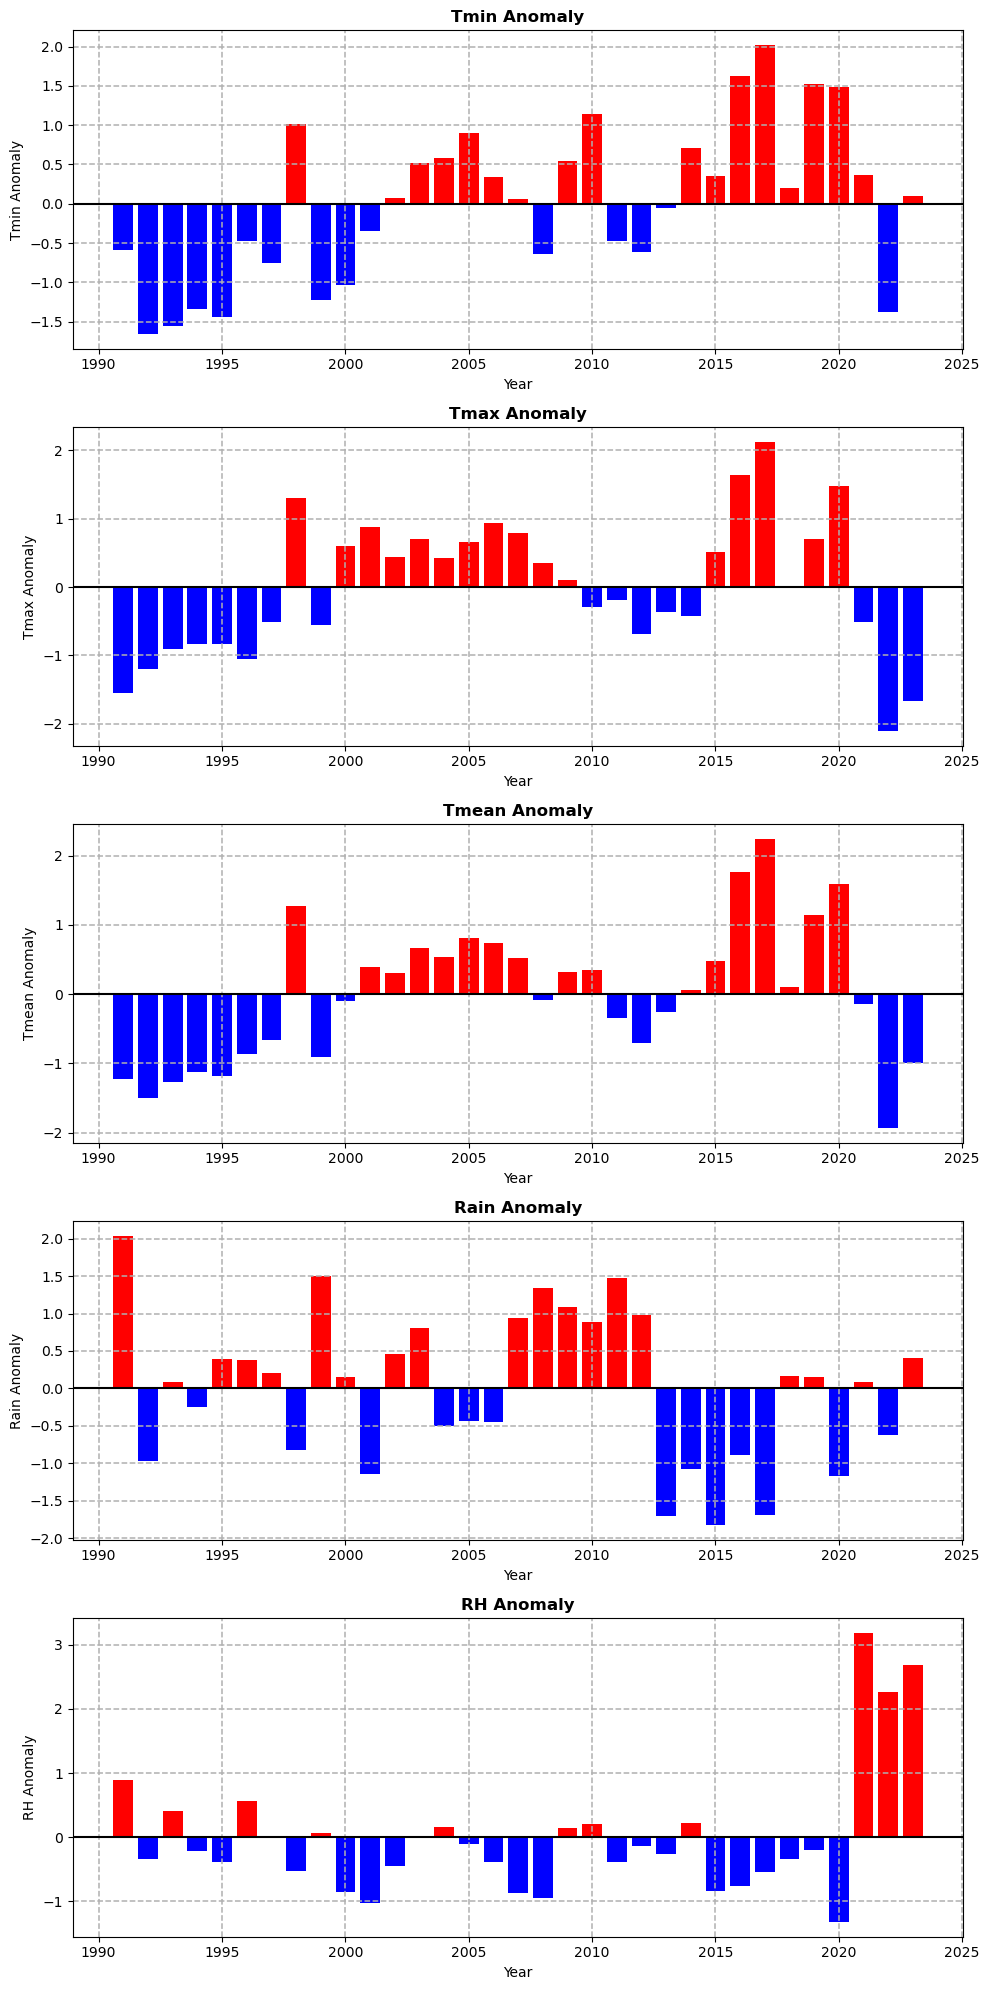

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
#file_path = 'your_dataset.csv'  # Replace with the path to your dataset
data = Kintampo

# Function to calculate anomalies
def calculate_anomalies(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    return annual_mean

# Variables to calculate anomalies for
variables = ['Tmin', 'Tmax', 'Tmean', 'Rain', 'RH']

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies
for i, variable in enumerate(variables):
    # Calculate anomalies
    anomalies = calculate_anomalies(data, variable)

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting as bar plot on the respective subplot
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=variable)

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linewidth=1.5)

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the final figure with subplots
plt.show()

# Optionally, save the entire figure
#fig.savefig('anomaly_barplots.png', bbox_inches='tight', dpi=500)


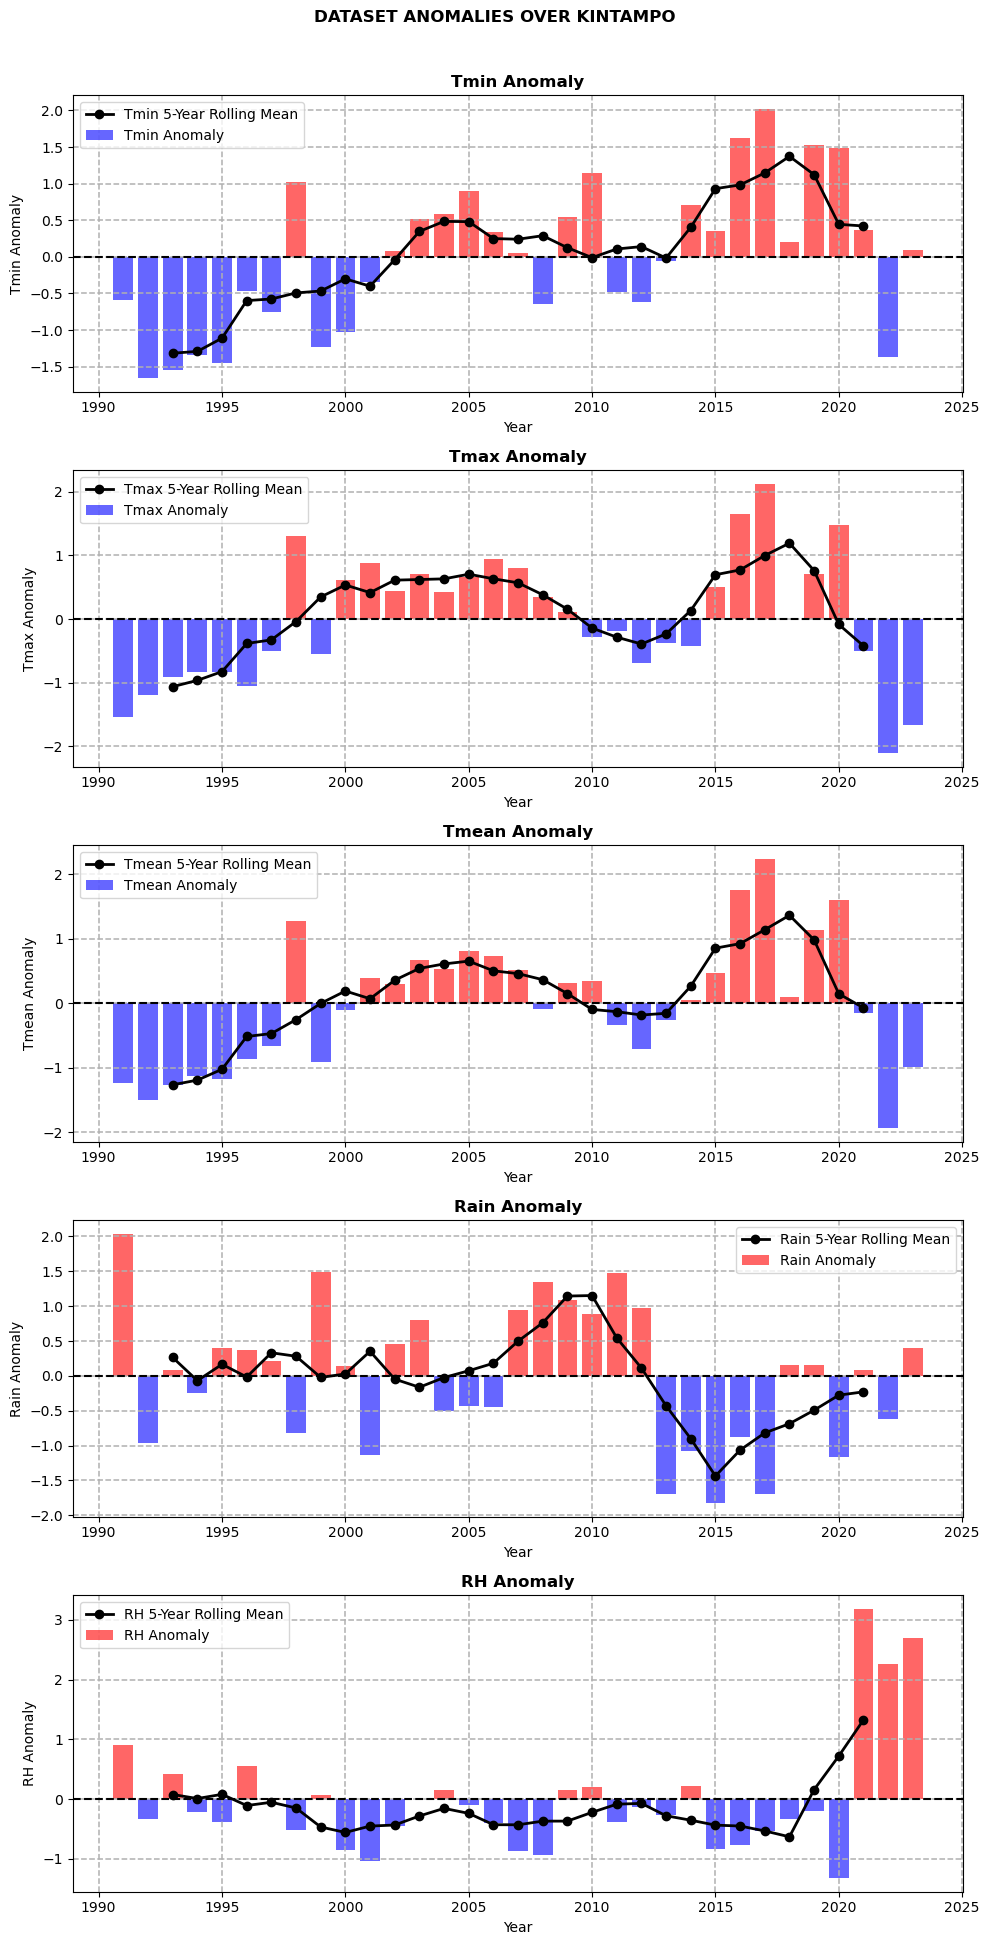

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = Kintampo

# Function to calculate anomalies
def calculate_anomalies(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    return annual_mean

# Variables to calculate anomalies for
variables = ['Tmin', 'Tmax', 'Tmean', 'Rain', 'RH']

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies
for i, variable in enumerate(variables):
    # Calculate anomalies
    anomalies = calculate_anomalies(data, variable)

    # Compute 5-year rolling mean on standardized anomalies
    anomalies[f'rolling_mean_{variable}'] = anomalies[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting bar plot of anomalies
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'{variable} Anomaly', alpha=0.6)

    # Plotting rolling mean
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2,marker ='o', label=f'{variable} 5-Year Rolling Mean')

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)
    axes[i].legend()

# Adjust layout to avoid overlap
# plt.tight_layout()
plt.suptitle('DATASET ANOMALIES OVER KINTAMPO', fontsize=12, fontweight='bold',y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Show the final figure with subplots
plt.show()

# Optionally, save the figure
fig.savefig('KINTAMPO.png', bbox_inches='tight', dpi=500)


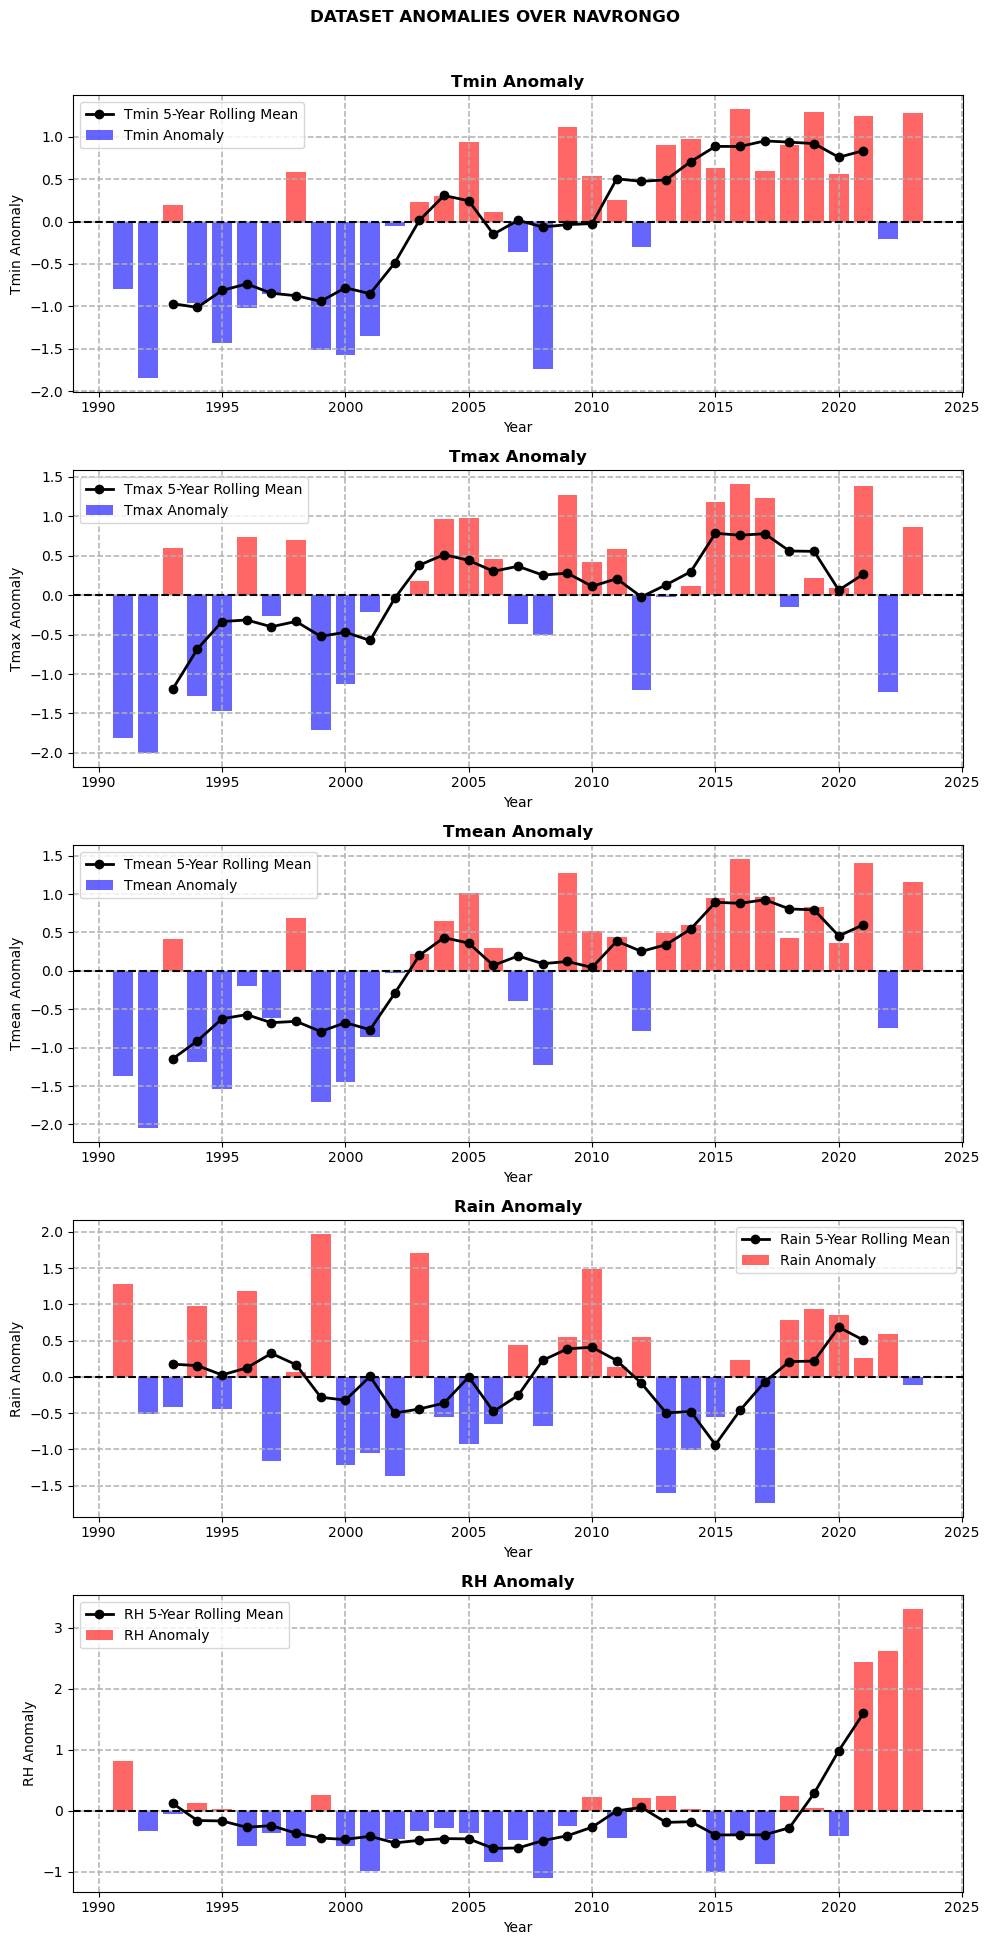

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = Navrongo

# Function to calculate anomalies
def calculate_anomalies(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    return annual_mean

# Variables to calculate anomalies for
variables = ['Tmin', 'Tmax', 'Tmean', 'Rain', 'RH']

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies
for i, variable in enumerate(variables):
    # Calculate anomalies
    anomalies = calculate_anomalies(data, variable)

    # Compute 5-year rolling mean on standardized anomalies
    anomalies[f'rolling_mean_{variable}'] = anomalies[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting bar plot of anomalies
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'{variable} Anomaly', alpha=0.6)

    # Plotting rolling mean
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2,marker ='o', label=f'{variable} 5-Year Rolling Mean')

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)
    axes[i].legend()

plt.suptitle('DATASET ANOMALIES OVER NAVRONGO', fontsize=12, fontweight='bold',y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Show the final figure with subplots
plt.show()

# Optionally, save the figure
fig.savefig('NAVRONGO.png', bbox_inches='tight', dpi=500)


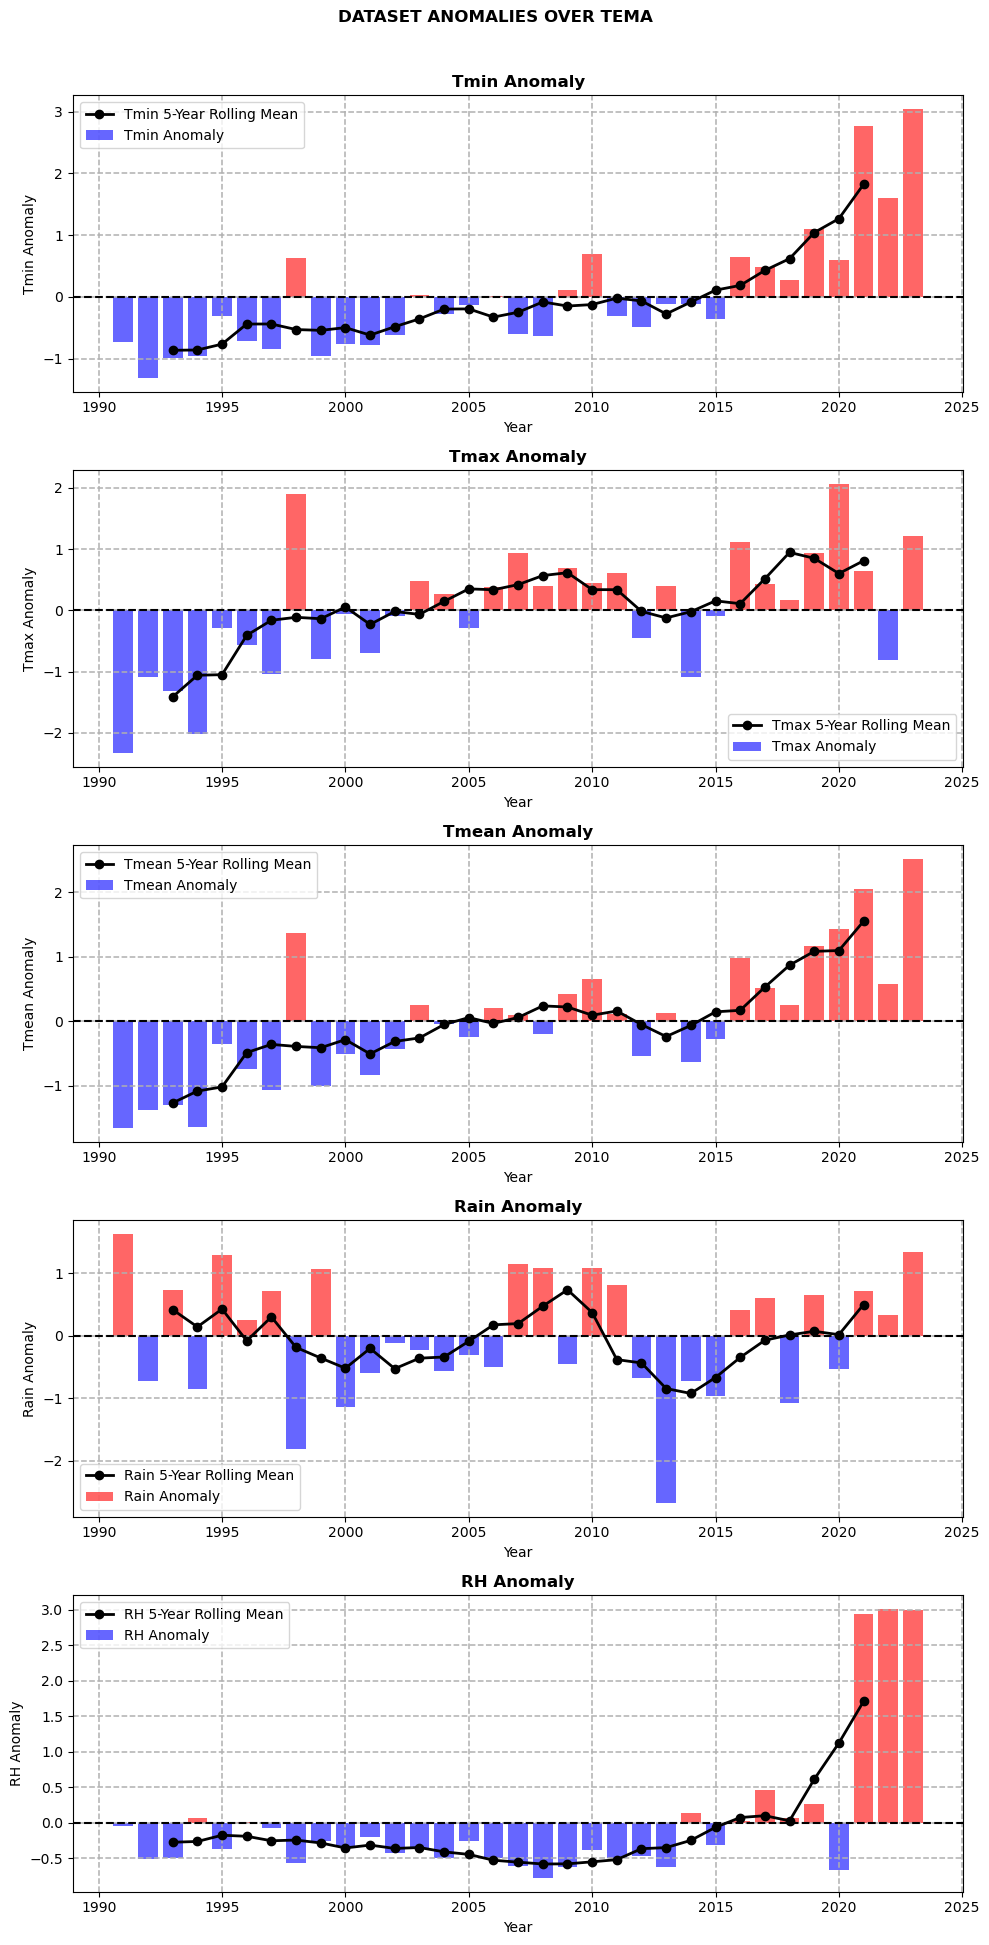

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = Tema

# Function to calculate anomalies
def calculate_anomalies(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    return annual_mean

# Variables to calculate anomalies for
variables = ['Tmin', 'Tmax', 'Tmean', 'Rain', 'RH']

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies
for i, variable in enumerate(variables):
    # Calculate anomalies
    anomalies = calculate_anomalies(data, variable)

    # Compute 5-year rolling mean on standardized anomalies
    anomalies[f'rolling_mean_{variable}'] = anomalies[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting bar plot of anomalies
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'{variable} Anomaly', alpha=0.6)

    # Plotting rolling mean
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2,marker ='o', label=f'{variable} 5-Year Rolling Mean')

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)
    axes[i].legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.suptitle('DATASET ANOMALIES OVER TEMA', fontsize=12, fontweight='bold',y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Show the final figure with subplots
# Optionally, save the figure
fig.savefig('TEMA.png', bbox_inches='tight', dpi=500)


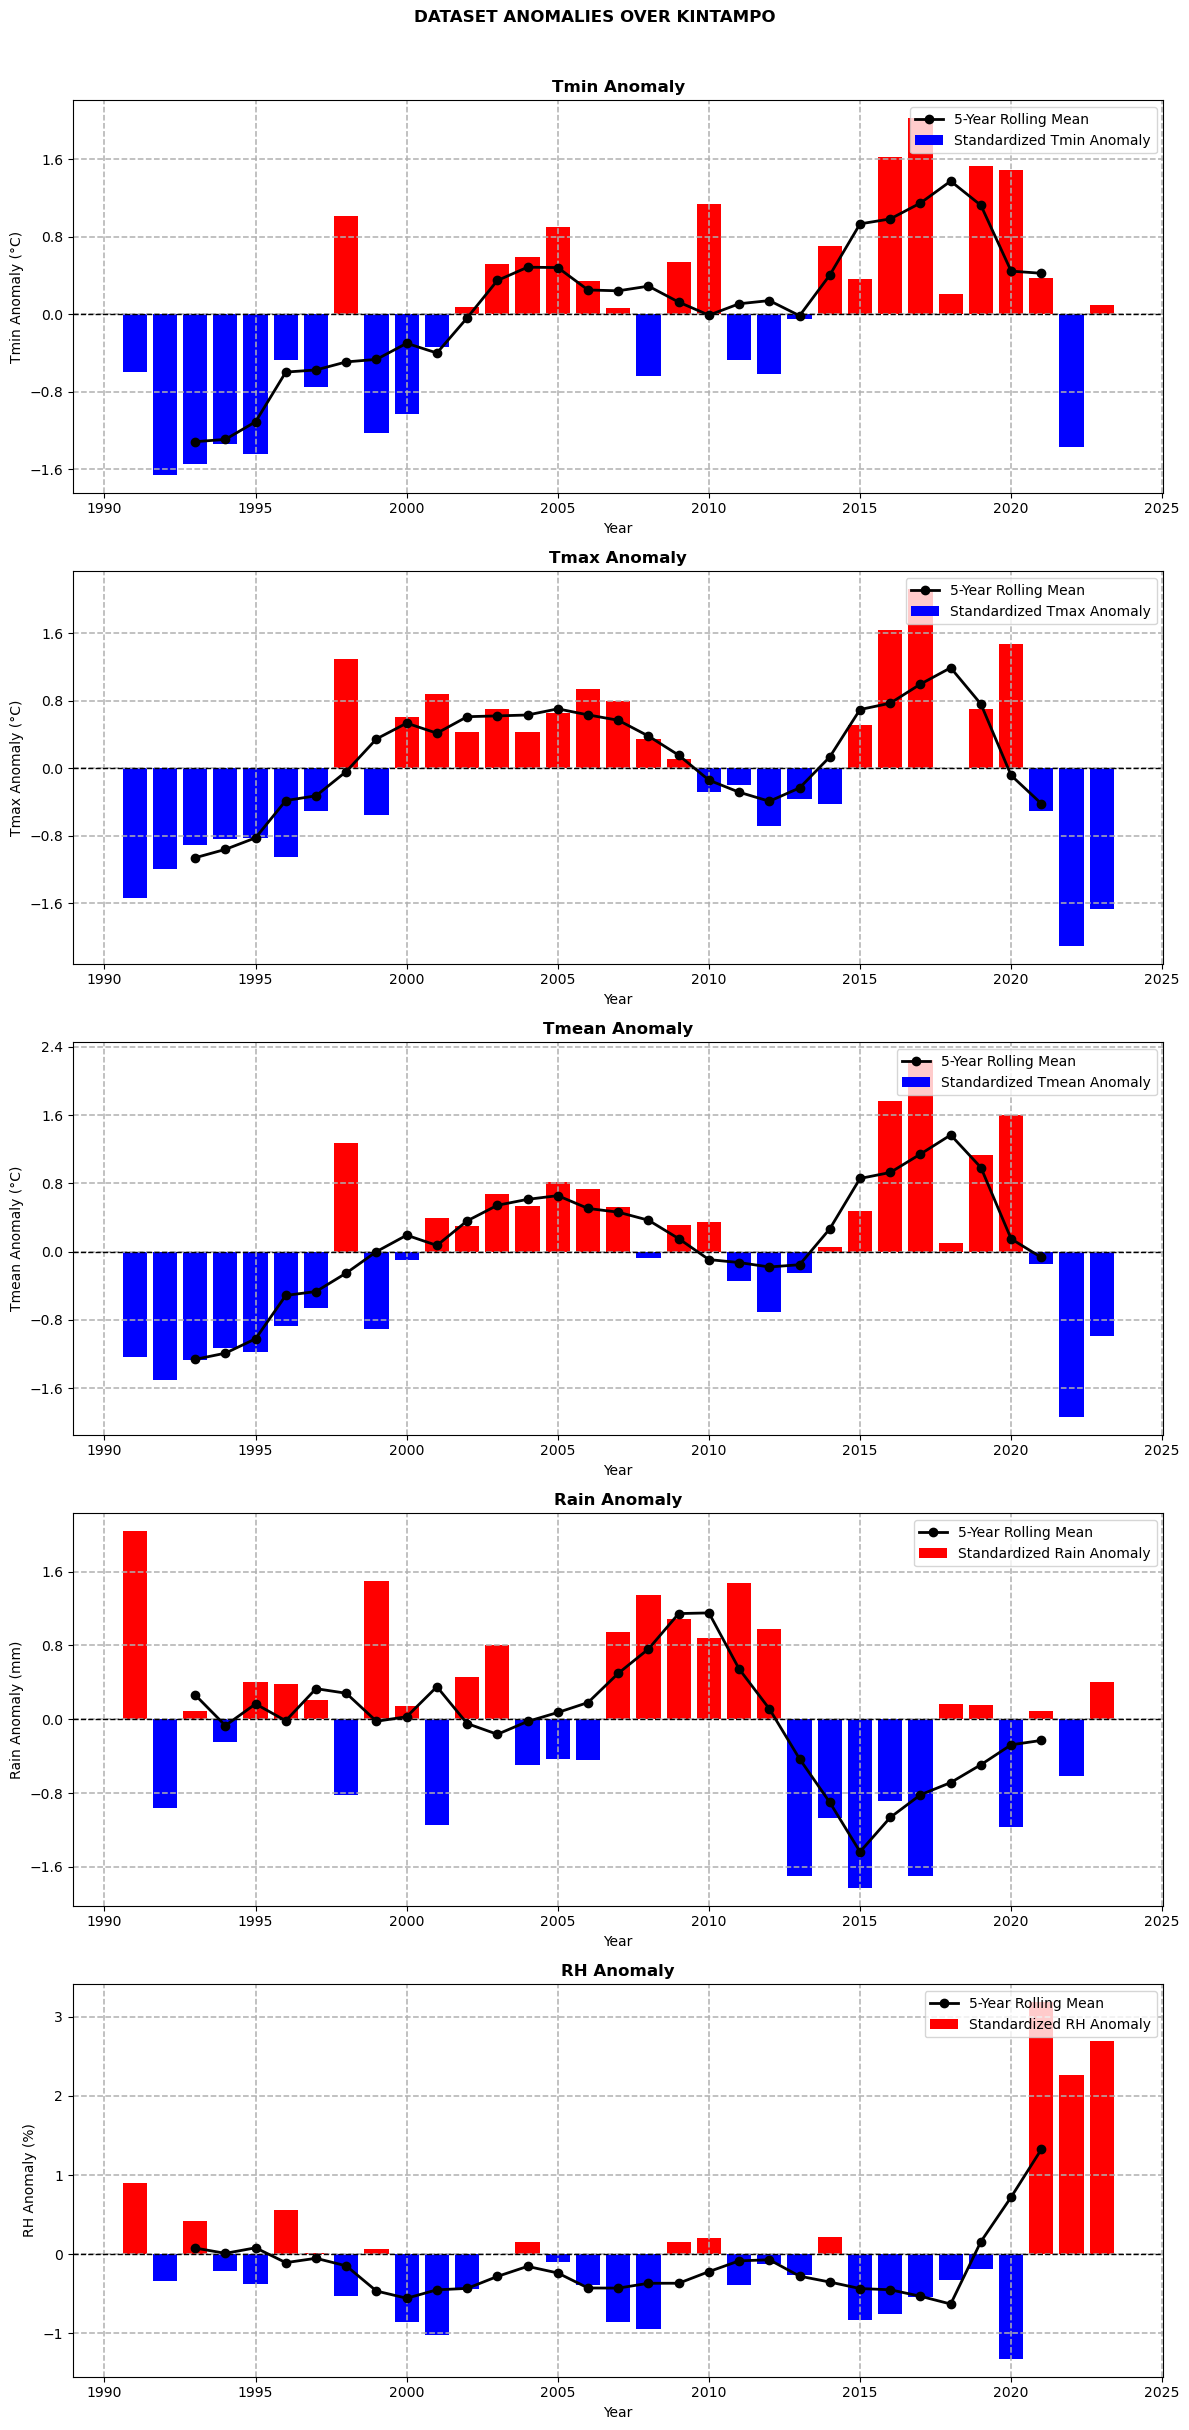

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
#file_path = 'your_dataset.csv'  # Replace with the path to your dataset
data = Kintampo

# Function to calculate anomalies and 5-year rolling mean over anomalies
def calculate_anomalies_and_rolling_mean(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    # Step 5: Calculate the 5-year rolling mean over the standardized anomalies
    annual_mean[f'rolling_mean_{variable}'] = annual_mean[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()

    return annual_mean

# Variables to calculate anomalies and rolling mean for, along with units
variables = {
    'Tmin': '°C',  # Minimum Temperature
    'Tmax': '°C',  # Maximum Temperature
    'Tmean': '°C', # Mean Temperature
    'Rain': 'mm',  # Rainfall
    'RH': '%'      # Relative Humidity
}

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 25))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies and rolling mean
for i, (variable, unit) in enumerate(variables.items()):
    # Calculate anomalies and rolling mean
    anomalies = calculate_anomalies_and_rolling_mean(data, variable)

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting as bar plot on the respective subplot
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'Standardized {variable} Anomaly')

    # Plotting the 5-year rolling mean as a line
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2,marker='o', label='5-Year Rolling Mean')

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly ({unit})', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)

    # Adjust y-axis tick density
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(6))  # Maximum of 6 ticks on the y-axis

    # Add legend
    axes[i].legend(loc='upper right')

plt.tight_layout()
plt.suptitle('DATASET ANOMALIES OVER KINTAMPO', fontsize=12, fontweight='bold',y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Optionally, save the entire figure
fig.savefig('anomaly_barplots_with_rolling_mean.png', bbox_inches='tight', dpi=500)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = Tema

# Function to calculate anomalies
def calculate_anomalies(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    return annual_mean

# Variables to calculate anomalies for
variables = ['Tmin', 'Tmax', 'Tmean', 'Rain', 'RH']

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies
for i, variable in enumerate(variables):
    # Calculate anomalies
    anomalies = calculate_anomalies(data, variable)

    # Compute 5-year rolling mean on standardized anomalies
    anomalies[f'rolling_mean_{variable}'] = anomalies[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting bar plot of anomalies
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'{variable} Anomaly', alpha=0.6)

    # Plotting rolling mean
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2,marker ='o', label=f'{variable} 5-Year Rolling Mean')

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)
    axes[i].legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.suptitle('DATASET ANOMALIES OVER TEMA', fontsize=12, fontweight='bold',y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Show the final figure with subplots
# Optionally, save the figure
fig.savefig('TEMA.png', bbox_inches='tight', dpi=500)


NEW DATASET

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
Kintampo_1991_2023_yyTn = pd.read_csv('Kintampo_1991_2023_yyTn.txt', delim_whitespace=True, header=None, names=["year","Tmin"]).loc[0:29] 
Kintampo_1991_2023_yyTx =pd.read_csv('Kintampo_1991_2023_yyTx.txt', delim_whitespace=True,header=None, names=["year","Tmax"]).loc[0:29] 
Kintampo_1991_2023_yyTm =pd.read_csv('Kintampo_1991_2023_yyTm.txt', delim_whitespace=True,header=None, names=["year","Tmean"]).loc[0:29] 
Kintampo_1991_2023_yyRR =pd.read_csv('Kintampo_1991_2023_yyRR.txt', delim_whitespace=True,header=None, names=["year","RR"]).loc[0:29] 
Kintampo_1991_2023_yyRH =pd.read_csv('Kintampo_1991_2023_yyRH.txt', delim_whitespace=True,header=None, names=["year","RH"]).loc[0:29] 

In [17]:
Kintampo_1991_2023_yyTn

,year,Tmin
0,1991,22.87
1,1992,22.50
2,1993,22.54
3,1994,22.61
4,1995,22.55
5,1996,22.90
6,1997,22.78
7,1998,23.40
8,1999,22.64
9,2000,22.70


ERA5 DATASET

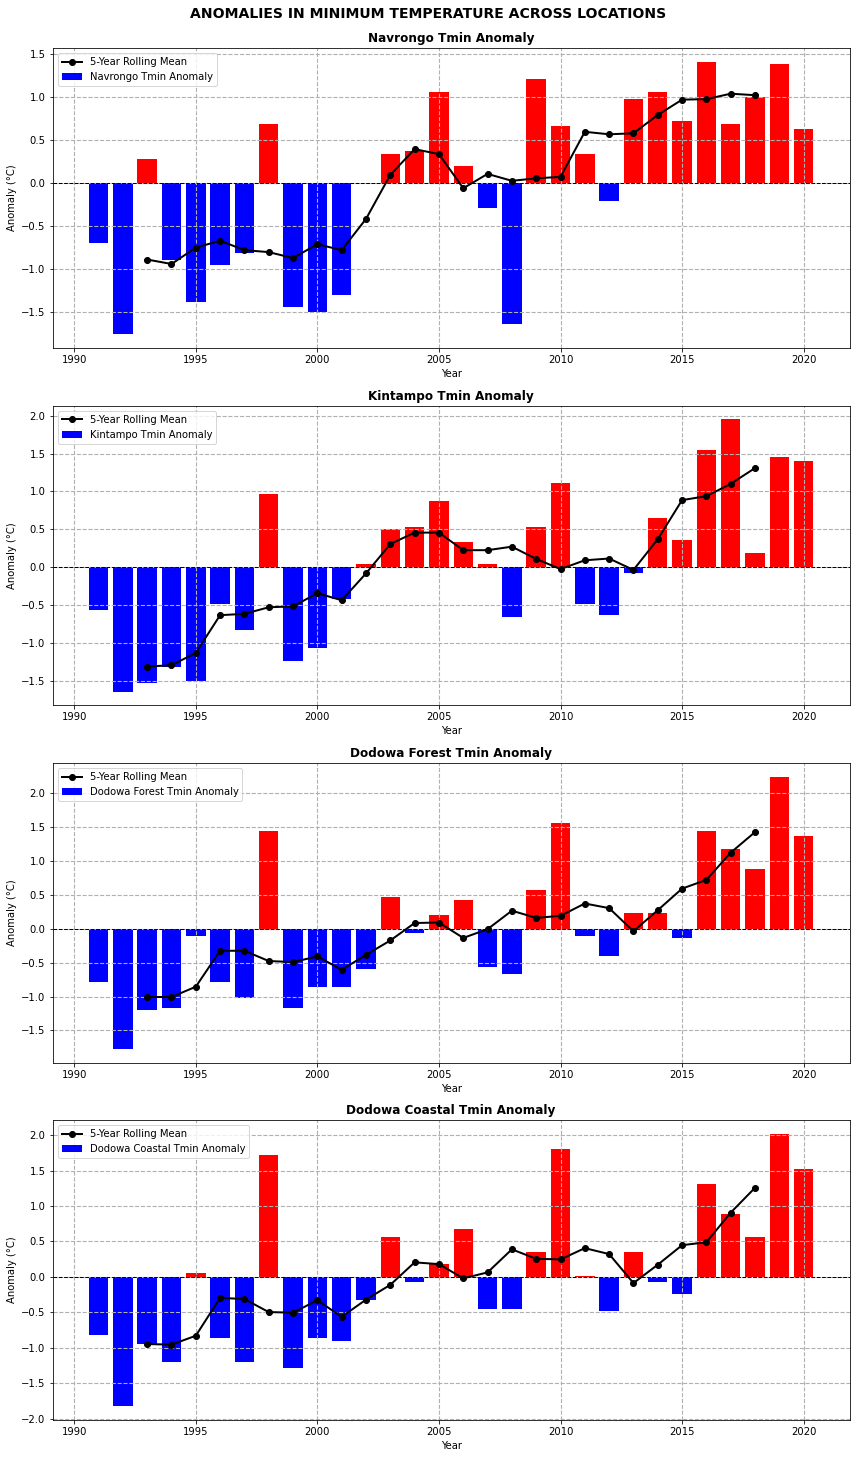

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
Navrongo = pd.read_csv('Navrongo_1991_2023_yyTn.txt', delim_whitespace=True, header=None, names=["year", "Tmin"]).loc[0:29]
Kintampo = pd.read_csv('Kintampo_1991_2023_yyTn.txt', delim_whitespace=True, header=None, names=["year", "Tmin"]).loc[0:29]
Dodowa_Forest = pd.read_csv('Dodowa_Forest_1991_2023_yyTn.txt', delim_whitespace=True, header=None, names=["year", "Tmin"]).loc[0:29]
Dodowa_Coastal = pd.read_csv('Dodowa_Coastal_1991_2023_yyTn.txt', delim_whitespace=True, header=None, names=["year", "Tmin"]).loc[0:29]


# Function to calculate anomalies and rolling mean
def calculate_anomalies_and_rolling_mean(data, variable):
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    long_term_mean = annual_mean[variable].mean()
    std_dev = annual_mean[variable].std()

    # Standardized anomaly
    annual_mean['standardized_anomaly'] = (annual_mean[variable] - long_term_mean) / std_dev

    # 5-year rolling mean
    annual_mean['rolling_mean'] = annual_mean['standardized_anomaly'].rolling(window=5, center=True).mean()

    return annual_mean

# Locations dictionary for easier processing
locations = {
    "Navrongo": Navrongo,
    "Kintampo": Kintampo,
    "Dodowa Forest": Dodowa_Forest,
    "Dodowa Coastal": Dodowa_Coastal,
    
}

# Create 4x1 subplot layout
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 20))  # 4 rows, 1 column
axes = axes.flatten()

# Loop through locations and plot Tmin anomalies
for i, (location, data) in enumerate(locations.items()):
    anomalies = calculate_anomalies_and_rolling_mean(data, "Tmin")
    colors = ['red' if val > 0 else 'blue' for val in anomalies['standardized_anomaly']]

    # Bar plot for standardized anomalies
    axes[i].bar(anomalies['year'], anomalies['standardized_anomaly'], color=colors, label=f'{location} Tmin Anomaly')

    # Line plot for 5-year rolling mean
    axes[i].plot(anomalies['year'], anomalies['rolling_mean'], color='black', linewidth=2, marker='o', label='5-Year Rolling Mean')

    # Horizontal reference line at 0
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)

    # Labels and grid
    axes[i].set_title(f'{location} Tmin Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Anomaly (°C)')
    axes[i].grid(True, linestyle='--', linewidth=1.1)
    axes[i].legend(loc='best')

plt.tight_layout()
plt.suptitle('ANOMALIES IN MINIMUM TEMPERATURE ACROSS LOCATIONS', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('Tmin_Anomalies_All_Locations.png', bbox_inches='tight', dpi=800)
plt.show()


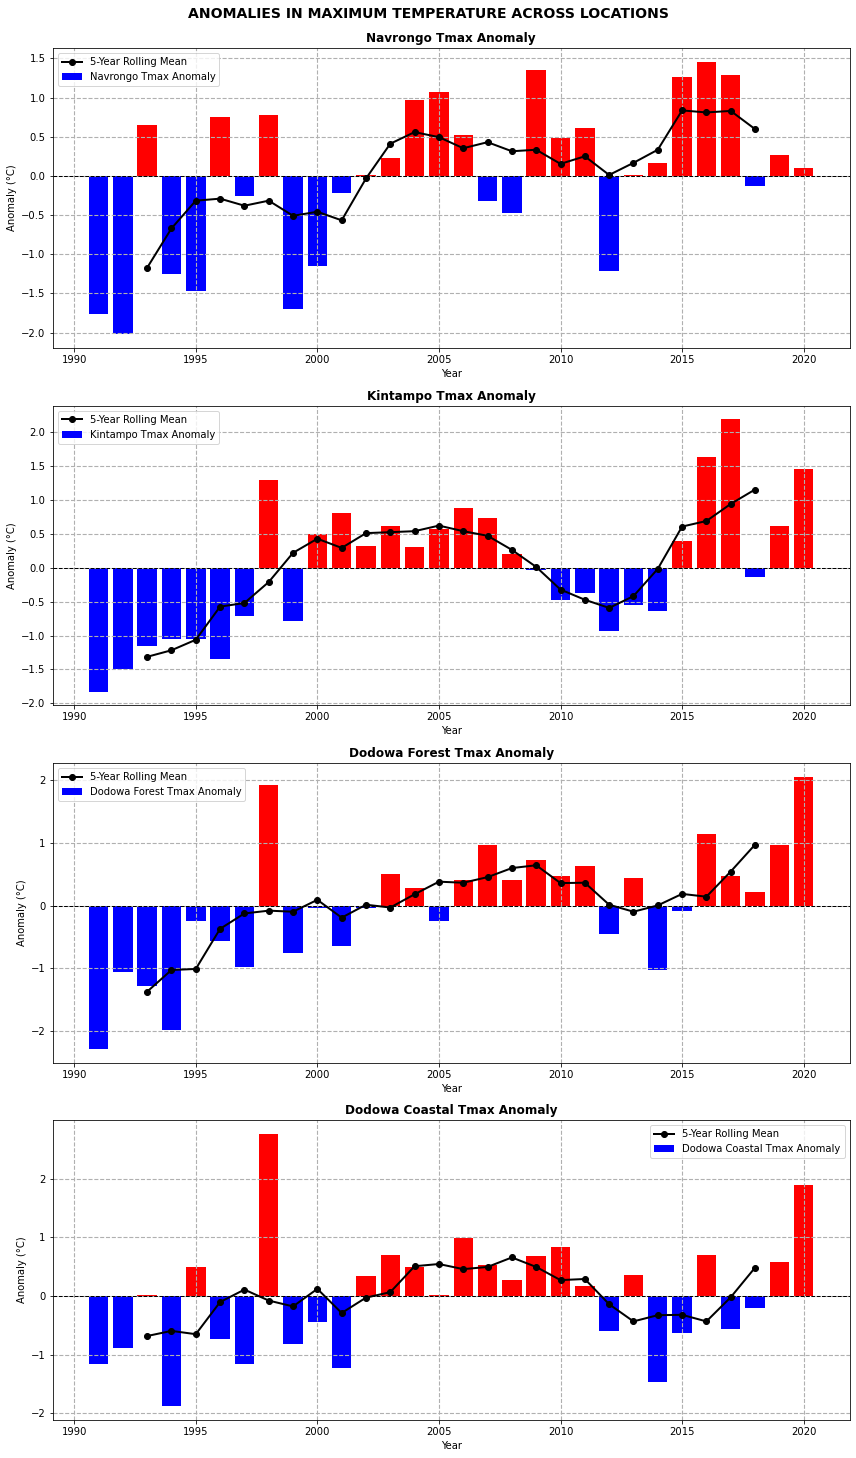

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
Navrongo = pd.read_csv('Navrongo_1991_2023_yyTx.txt', delim_whitespace=True, header=None, names=["year", "Tmax"]).loc[0:29]
Kintampo = pd.read_csv('Kintampo_1991_2023_yyTx.txt', delim_whitespace=True, header=None, names=["year", "Tmax"]).loc[0:29]
Dodowa_Forest = pd.read_csv('Dodowa_Forest_1991_2023_yyTx.txt', delim_whitespace=True, header=None, names=["year", "Tmax"]).loc[0:29]
Dodowa_Coastal = pd.read_csv('Dodowa_Coastal_1991_2023_yyTx.txt', delim_whitespace=True, header=None, names=["year", "Tmax"]).loc[0:29]


# Function to calculate anomalies and rolling mean
def calculate_anomalies_and_rolling_mean(data, variable):
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    long_term_mean = annual_mean[variable].mean()
    std_dev = annual_mean[variable].std()

    # Standardized anomaly
    annual_mean['standardized_anomaly'] = (annual_mean[variable] - long_term_mean) / std_dev

    # 5-year rolling mean
    annual_mean['rolling_mean'] = annual_mean['standardized_anomaly'].rolling(window=5, center=True).mean()

    return annual_mean

# Locations dictionary for easier processing
locations = {
     "Navrongo": Navrongo,
    "Kintampo": Kintampo,
    "Dodowa Forest": Dodowa_Forest,
    "Dodowa Coastal": Dodowa_Coastal
   
}

# Create 4x1 subplot layout
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 20))  # 4 rows, 1 column
axes = axes.flatten()

# Loop through locations and plot Tmin anomalies
for i, (location, data) in enumerate(locations.items()):
    anomalies = calculate_anomalies_and_rolling_mean(data, "Tmax")
    colors = ['red' if val > 0 else 'blue' for val in anomalies['standardized_anomaly']]

    # Bar plot for standardized anomalies
    axes[i].bar(anomalies['year'], anomalies['standardized_anomaly'], color=colors, label=f'{location} Tmax Anomaly')

    # Line plot for 5-year rolling mean
    axes[i].plot(anomalies['year'], anomalies['rolling_mean'], color='black', linewidth=2, marker='o', label='5-Year Rolling Mean')

    # Horizontal reference line at 0
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)

    # Labels and grid
    axes[i].set_title(f'{location} Tmax Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Anomaly (°C)')
    axes[i].grid(True, linestyle='--', linewidth=1.1)
    axes[i].legend(loc='best')

plt.tight_layout()
plt.suptitle('ANOMALIES IN MAXIMUM TEMPERATURE ACROSS LOCATIONS', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('Tmax_Anomalies_All_Locations.png', bbox_inches='tight', dpi=800)
plt.show()


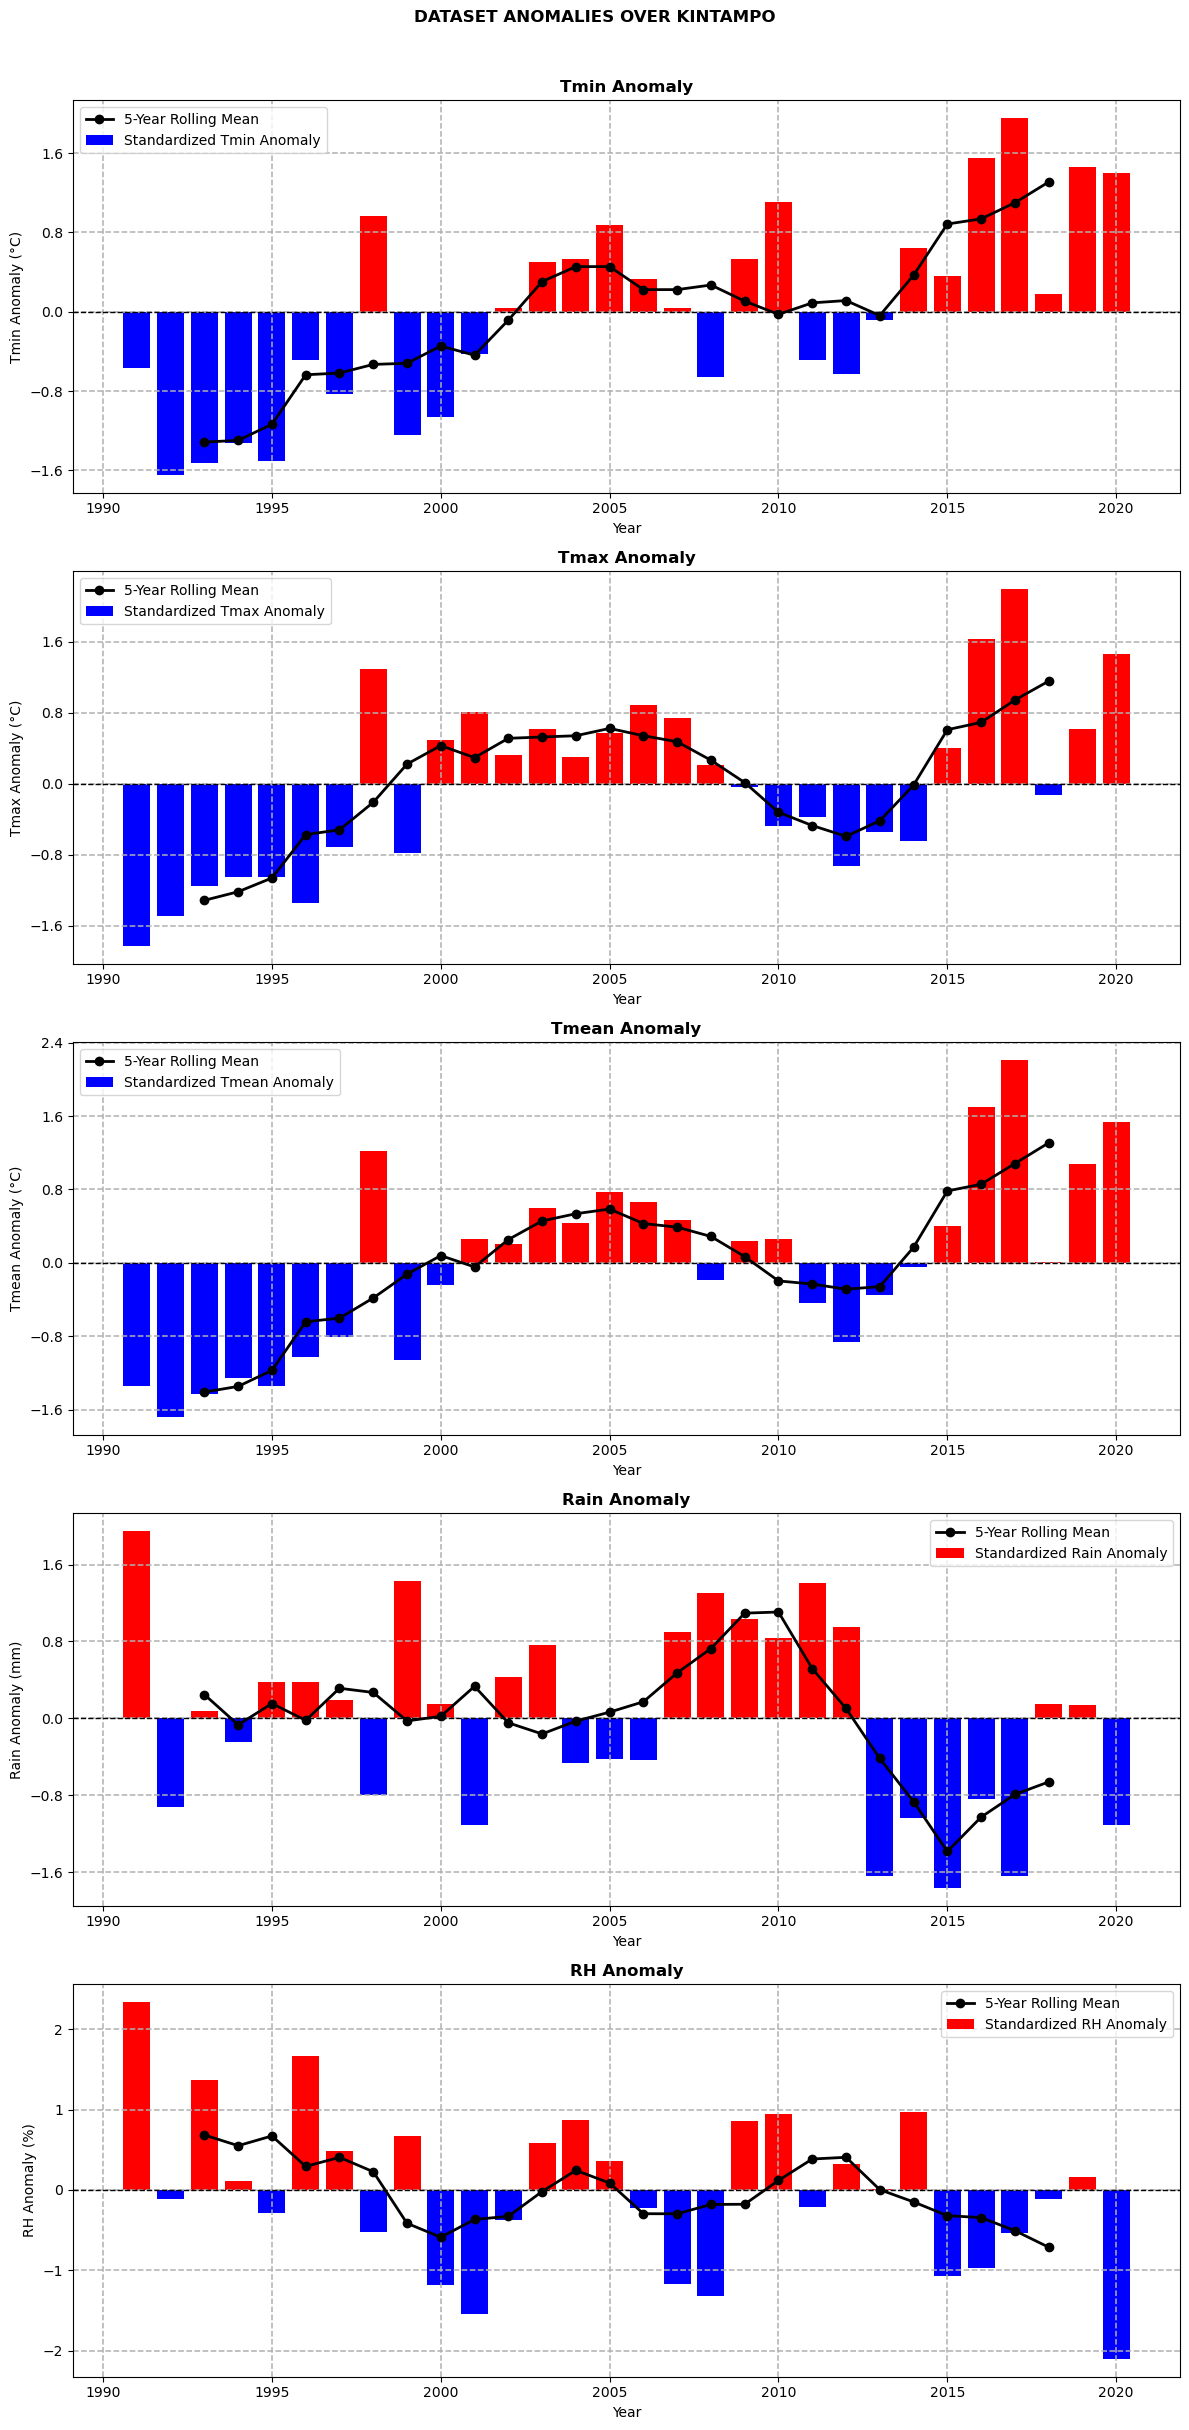

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
Kintampo_1991_2023_yyTn = pd.read_csv('Kintampo_1991_2023_yyTn.txt', delim_whitespace=True, header=None, names=["year", "Tmin"]).loc[0:29]
Kintampo_1991_2023_yyTx = pd.read_csv('Kintampo_1991_2023_yyTx.txt', delim_whitespace=True, header=None, names=["year", "Tmax"]).loc[0:29]
Kintampo_1991_2023_yyTm = pd.read_csv('Kintampo_1991_2023_yyTm.txt', delim_whitespace=True, header=None, names=["year", "Tmean"]).loc[0:29]
Kintampo_1991_2023_yyRR = pd.read_csv('Kintampo_1991_2023_yyRR.txt', delim_whitespace=True, header=None, names=["year", "Rain"]).loc[0:29]
Kintampo_1991_2023_yyRH = pd.read_csv('Kintampo_1991_2023_yyRH.txt', delim_whitespace=True, header=None, names=["year", "RH"]).loc[0:29]

# Merge all datasets into a single DataFrame
Kintampo = pd.merge(Kintampo_1991_2023_yyTn, Kintampo_1991_2023_yyTx, on="year")
Kintampo = pd.merge(Kintampo, Kintampo_1991_2023_yyTm, on="year")
Kintampo = pd.merge(Kintampo, Kintampo_1991_2023_yyRR, on="year")
Kintampo = pd.merge(Kintampo, Kintampo_1991_2023_yyRH, on="year")

# Function to calculate anomalies and 5-year rolling mean over anomalies
def calculate_anomalies_and_rolling_mean(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    # Step 5: Calculate the 5-year rolling mean over the standardized anomalies
    annual_mean[f'rolling_mean_{variable}'] = annual_mean[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()

    return annual_mean

# Variables to calculate anomalies and rolling mean for, along with units
variables = {
    'Tmin': '°C',  # Minimum Temperature
    'Tmax': '°C',  # Maximum Temperature
    'Tmean': '°C', # Mean Temperature
    'Rain': 'mm',  # Rainfall
    'RH': '%'      # Relative Humidity
}

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 25))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies and rolling mean
for i, (variable, unit) in enumerate(variables.items()):
    # Calculate anomalies and rolling mean
    anomalies = calculate_anomalies_and_rolling_mean(Kintampo, variable)

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting as bar plot on the respective subplot
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'Standardized {variable} Anomaly')

    # Plotting the 5-year rolling mean as a line
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2, marker='o', label='5-Year Rolling Mean')

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly ({unit})', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)

    # Adjust y-axis tick density
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(6))  # Maximum of 6 ticks on the y-axis

    # Add legend
    axes[i].legend(loc='best')

plt.tight_layout()
plt.suptitle('DATASET ANOMALIES OVER KINTAMPO', fontsize=12, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Optionally, save the entire figure
fig.savefig('KINTAMPO_30_YEARS.png', bbox_inches='tight', dpi=500)

plt.show()


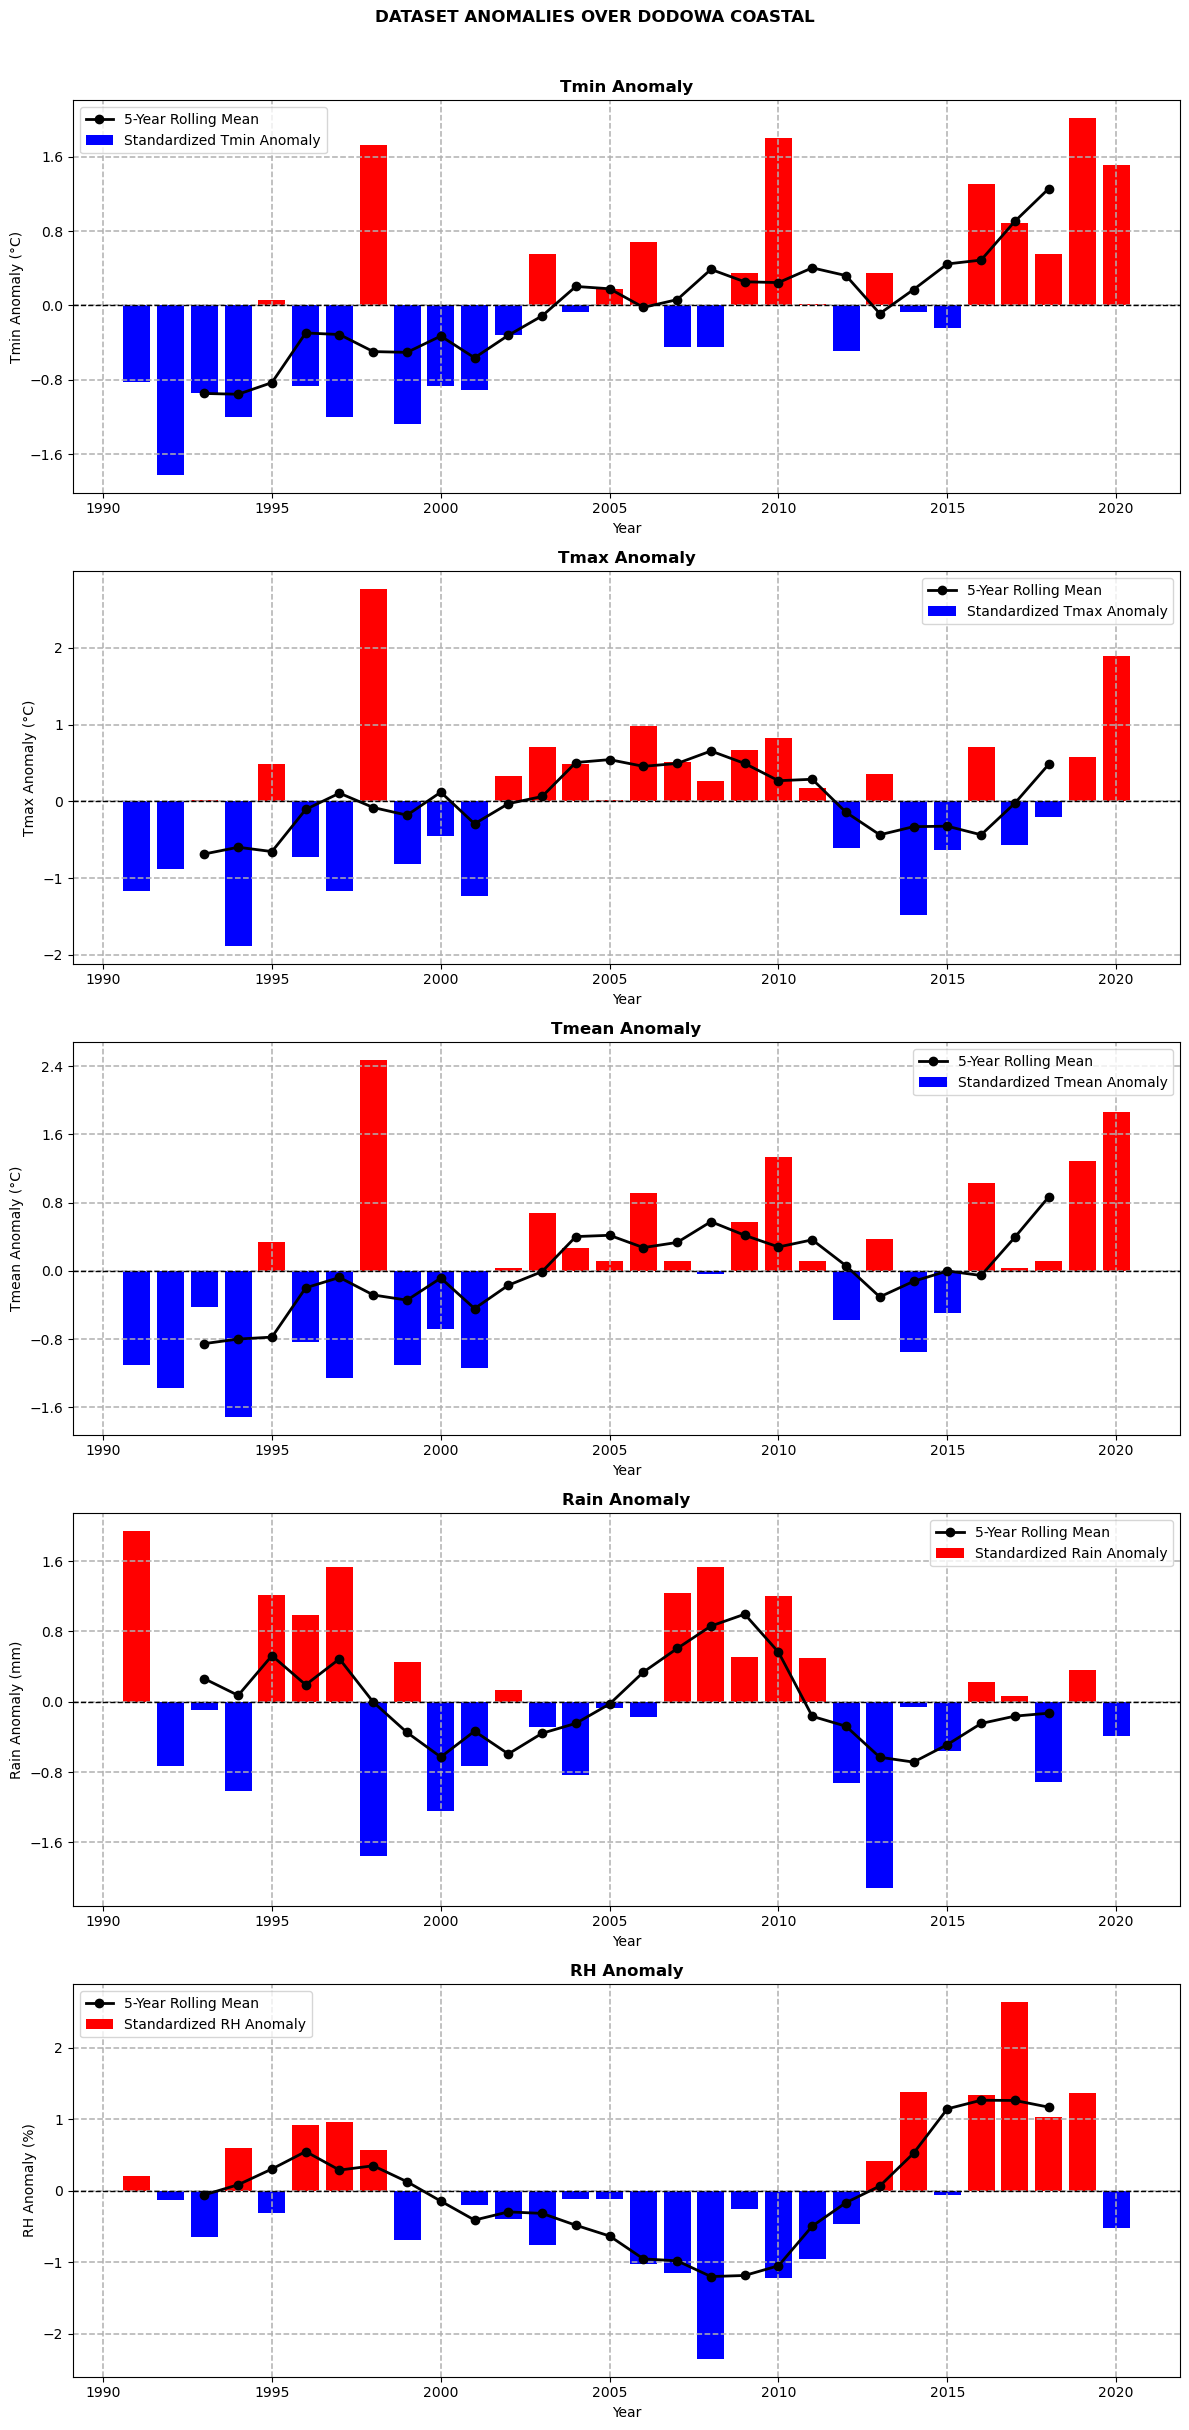

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets

Dodowa_Coastal_1991_2023_yyTn = pd.read_csv('Dodowa_Coastal_1991_2023_yyTn.txt', delim_whitespace=True, header=None, names=["year", "Tmin"]).loc[0:29]
Dodowa_Coastal_1991_2023_yyTx = pd.read_csv('Dodowa_Coastal_1991_2023_yyTx.txt', delim_whitespace=True, header=None, names=["year", "Tmax"]).loc[0:29]
Dodowa_Coastal_1991_2023_yyTm = pd.read_csv('Dodowa_Coastal_1991_2023_yyTm.txt', delim_whitespace=True, header=None, names=["year", "Tmean"]).loc[0:29]
Dodowa_Coastal_1991_2023_yyRR = pd.read_csv('Dodowa_Coastal_1991_2023_yyRR.txt', delim_whitespace=True, header=None, names=["year", "Rain"]).loc[0:29]
Dodowa_Coastal_1991_2023_yyRH = pd.read_csv('Dodowa_Coastal_1991_2023_yyRH.txt', delim_whitespace=True, header=None, names=["year", "RH"]).loc[0:29]

# Merge all datasets into a single DataFrame
Dodowa_Coastal = pd.merge(Dodowa_Coastal_1991_2023_yyTn, Dodowa_Coastal_1991_2023_yyTx, on="year")
Dodowa_Coastal = pd.merge(Dodowa_Coastal, Dodowa_Coastal_1991_2023_yyTm, on="year")
Dodowa_Coastal = pd.merge(Dodowa_Coastal, Dodowa_Coastal_1991_2023_yyRR, on="year")
Dodowa_Coastal = pd.merge(Dodowa_Coastal, Dodowa_Coastal_1991_2023_yyRH, on="year")

# Function to calculate anomalies and 5-year rolling mean over anomalies
def calculate_anomalies_and_rolling_mean(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    # Step 5: Calculate the 5-year rolling mean over the standardized anomalies
    annual_mean[f'rolling_mean_{variable}'] = annual_mean[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()

    return annual_mean

# Variables to calculate anomalies and rolling mean for, along with units
variables = {
    'Tmin': '°C',  # Minimum Temperature
    'Tmax': '°C',  # Maximum Temperature
    'Tmean': '°C', # Mean Temperature
    'Rain': 'mm',  # Rainfall
    'RH': '%'      # Relative Humidity
}

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 25))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies and rolling mean
for i, (variable, unit) in enumerate(variables.items()):
    # Calculate anomalies and rolling mean
    anomalies = calculate_anomalies_and_rolling_mean(Dodowa_Coastal, variable)

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting as bar plot on the respective subplot
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'Standardized {variable} Anomaly')

    # Plotting the 5-year rolling mean as a line
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2, marker='o', label='5-Year Rolling Mean')

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly ({unit})', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)

    # Adjust y-axis tick density
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(6))  # Maximum of 6 ticks on the y-axis

    # Add legend
    axes[i].legend(loc='best')

plt.tight_layout()
plt.suptitle('DATASET ANOMALIES OVER DODOWA COASTAL', fontsize=12, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Optionally, save the entire figure
fig.savefig('DODOWA COASTAL_30_YEARS.png', bbox_inches='tight', dpi=500)

plt.show()


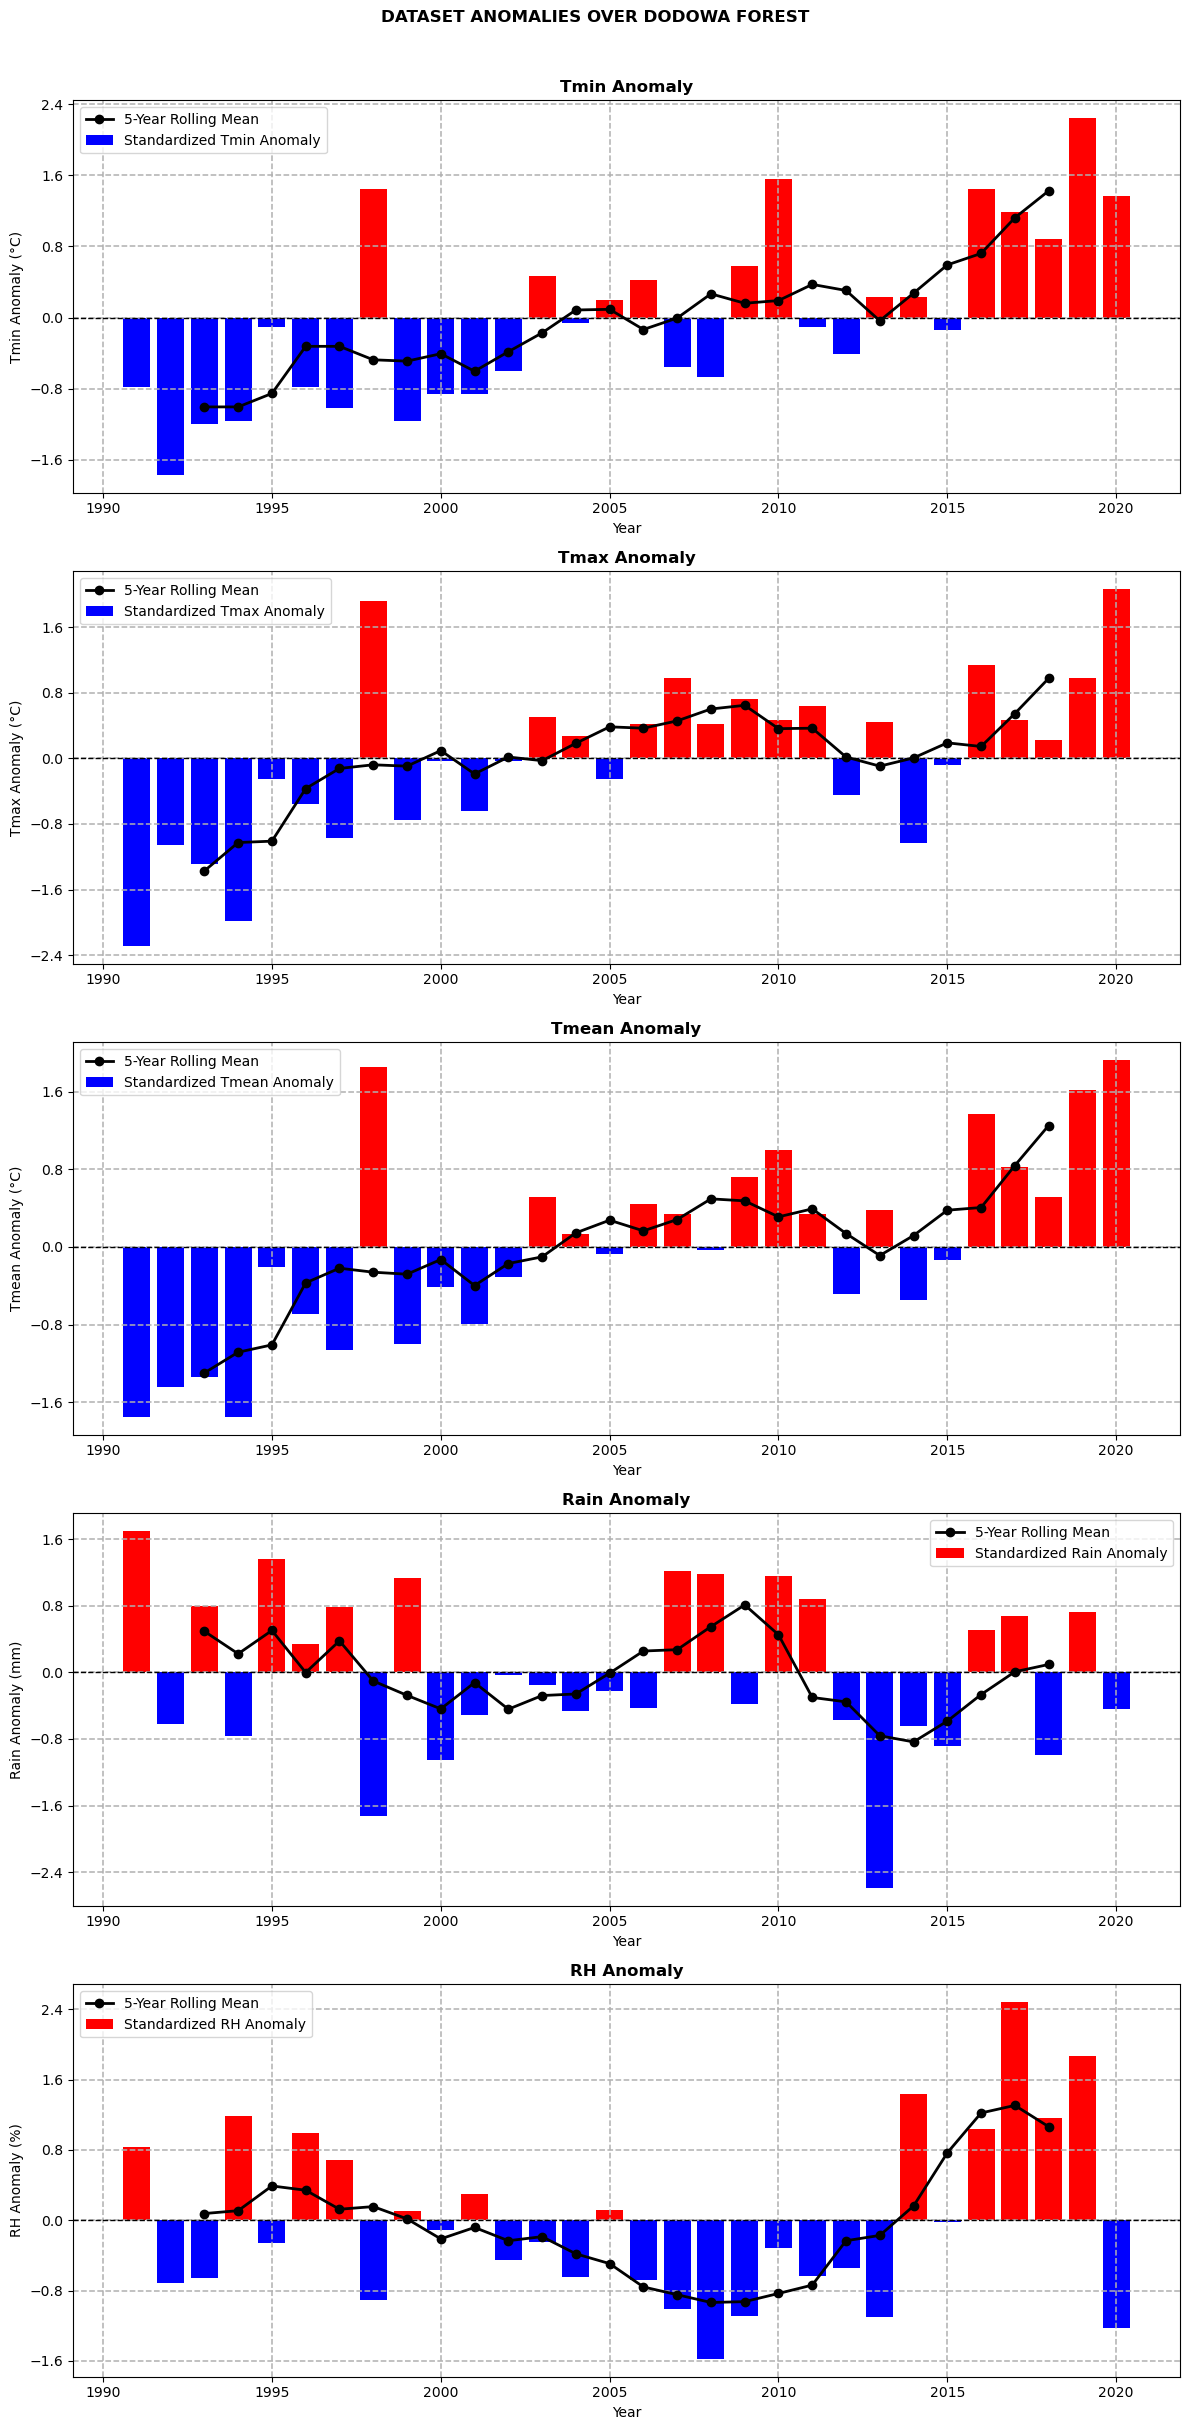

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets

Dodowa_Forest_1991_2023_yyTn = pd.read_csv('Dodowa_Forest_1991_2023_yyTn.txt', delim_whitespace=True, header=None, names=["year", "Tmin"]).loc[0:29]
Dodowa_Forest_1991_2023_yyTx = pd.read_csv('Dodowa_Forest_1991_2023_yyTx.txt', delim_whitespace=True, header=None, names=["year", "Tmax"]).loc[0:29]
Dodowa_Forest_1991_2023_yyTm = pd.read_csv('Dodowa_Forest_1991_2023_yyTm.txt', delim_whitespace=True, header=None, names=["year", "Tmean"]).loc[0:29]
Dodowa_Forest_1991_2023_yyRR = pd.read_csv('Dodowa_Forest_1991_2023_yyRR.txt', delim_whitespace=True, header=None, names=["year", "Rain"]).loc[0:29]
Dodowa_Forest_1991_2023_yyRH = pd.read_csv('Dodowa_Forest_1991_2023_yyRH.txt', delim_whitespace=True, header=None, names=["year", "RH"]).loc[0:29]

# Merge all datasets into a single DataFrame
Dodowa_Forest = pd.merge(Dodowa_Forest_1991_2023_yyTn, Dodowa_Forest_1991_2023_yyTx, on="year")
Dodowa_Forest = pd.merge(Dodowa_Forest, Dodowa_Forest_1991_2023_yyTm, on="year")
Dodowa_Forest = pd.merge(Dodowa_Forest, Dodowa_Forest_1991_2023_yyRR, on="year")
Dodowa_Forest = pd.merge(Dodowa_Forest, Dodowa_Forest_1991_2023_yyRH, on="year")

# Function to calculate anomalies and 5-year rolling mean over anomalies
def calculate_anomalies_and_rolling_mean(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    # Step 5: Calculate the 5-year rolling mean over the standardized anomalies
    annual_mean[f'rolling_mean_{variable}'] = annual_mean[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()

    return annual_mean

# Variables to calculate anomalies and rolling mean for, along with units
variables = {
    'Tmin': '°C',  # Minimum Temperature
    'Tmax': '°C',  # Maximum Temperature
    'Tmean': '°C', # Mean Temperature
    'Rain': 'mm',  # Rainfall
    'RH': '%'      # Relative Humidity
}

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 25))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies and rolling mean
for i, (variable, unit) in enumerate(variables.items()):
    # Calculate anomalies and rolling mean
    anomalies = calculate_anomalies_and_rolling_mean(Dodowa_Forest, variable)

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting as bar plot on the respective subplot
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'Standardized {variable} Anomaly')

    # Plotting the 5-year rolling mean as a line
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2, marker='o', label='5-Year Rolling Mean')

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly ({unit})', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)

    # Adjust y-axis tick density
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(6))  # Maximum of 6 ticks on the y-axis

    # Add legend
    axes[i].legend(loc='best')

plt.tight_layout()
plt.suptitle('DATASET ANOMALIES OVER DODOWA FOREST', fontsize=12, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Optionally, save the entire figure
fig.savefig('DODOWA FOREST_30_YEARS.png', bbox_inches='tight', dpi=500)

plt.show()


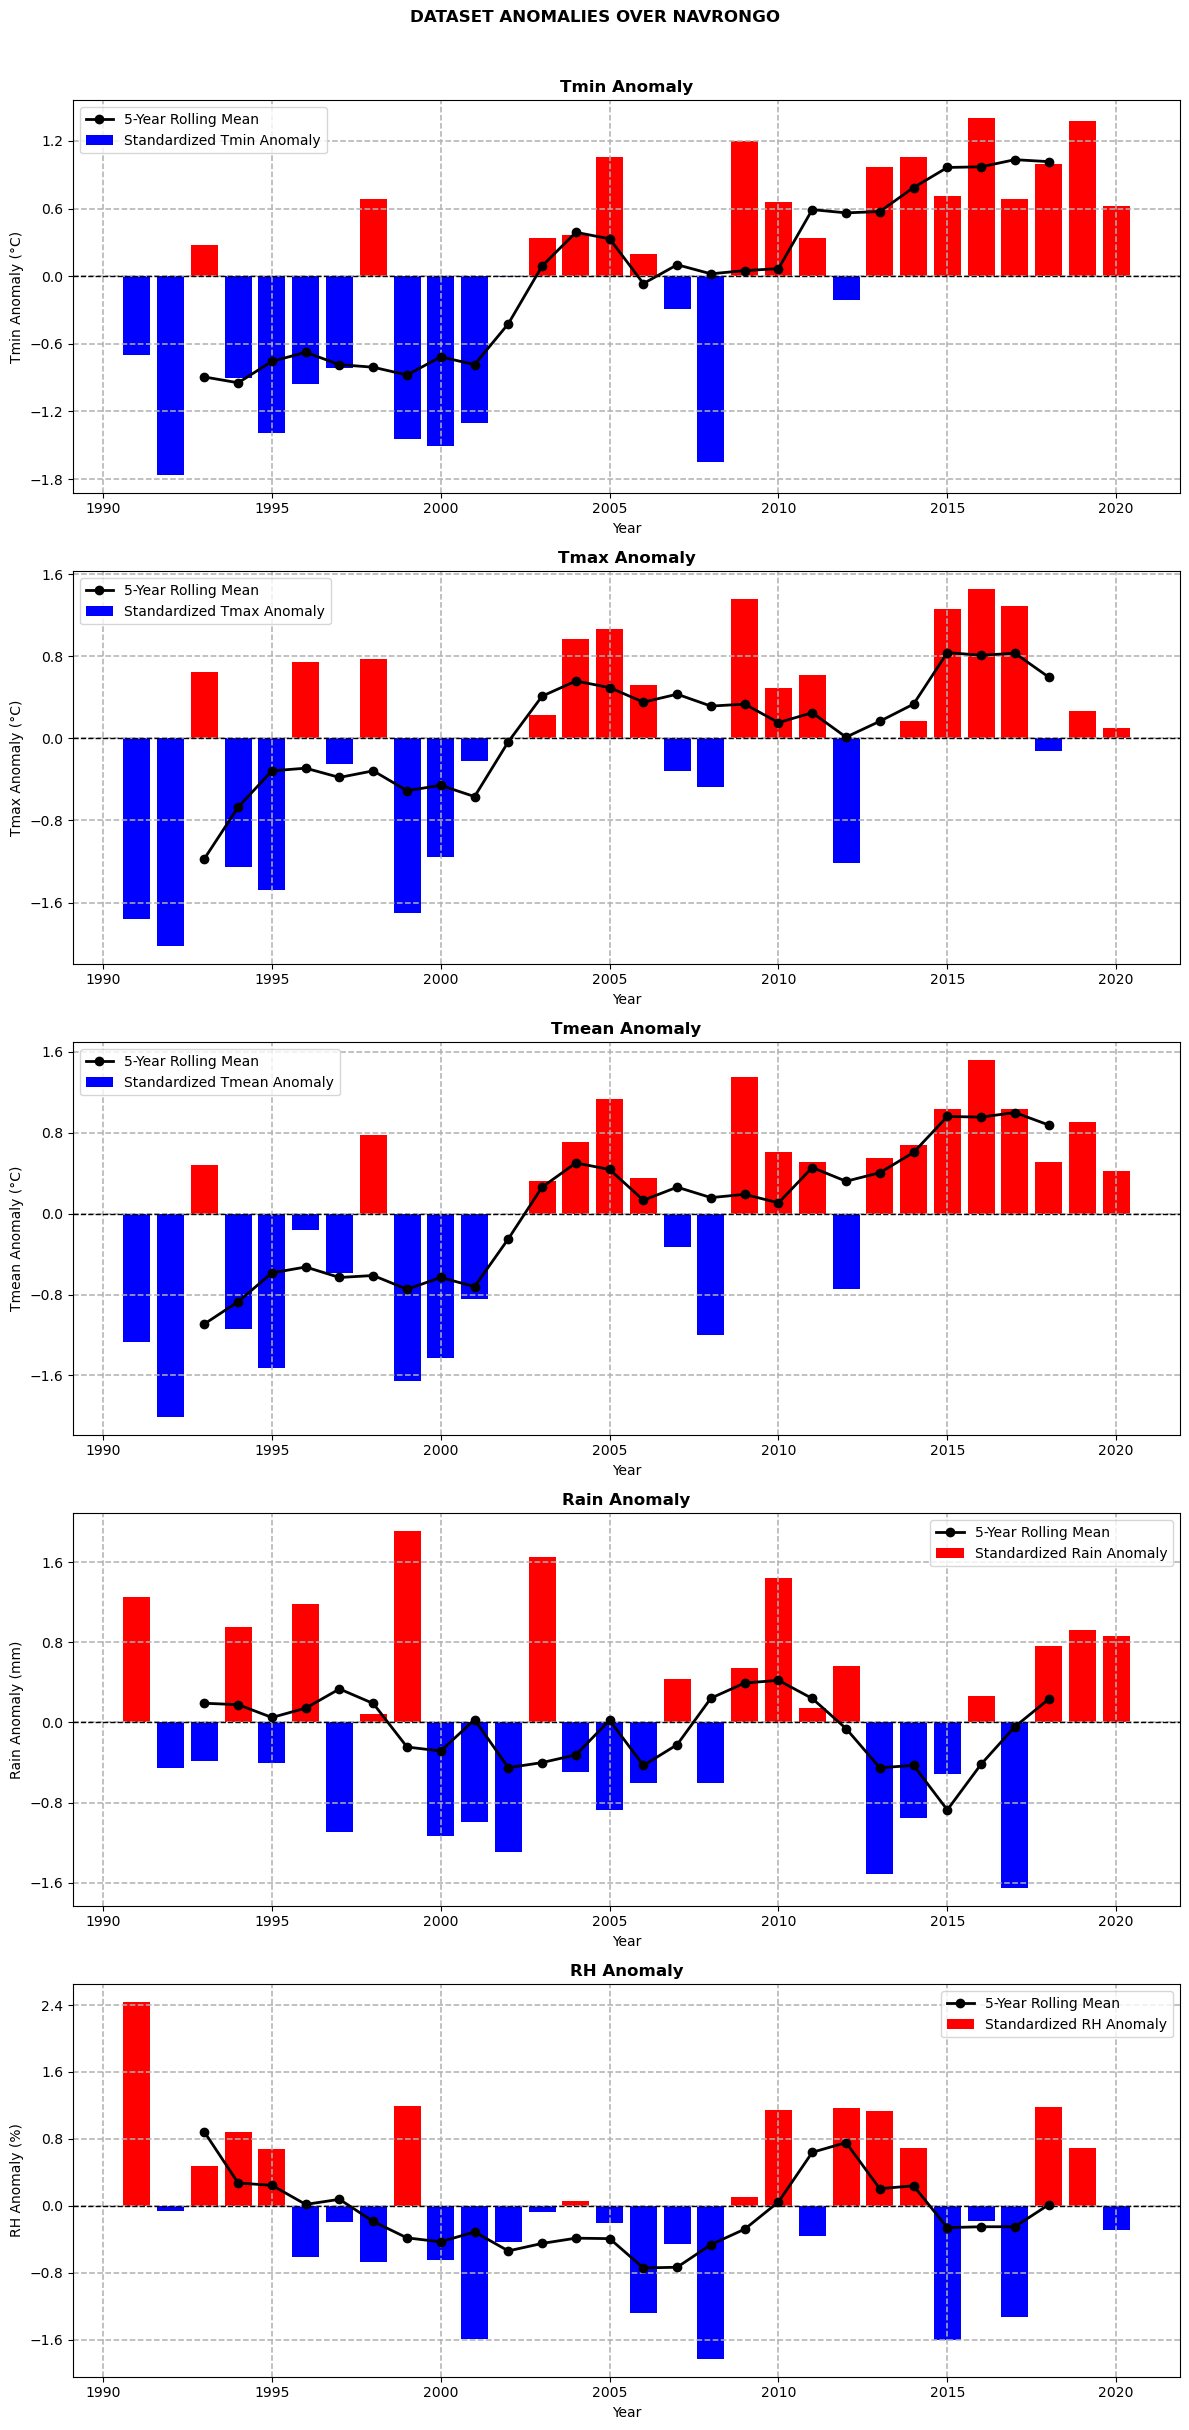

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets

Navrongo_1991_2023_yyTn = pd.read_csv('Navrongo_1991_2023_yyTn.txt', delim_whitespace=True, header=None, names=["year", "Tmin"]).loc[0:29]
Navrongo_1991_2023_yyTx = pd.read_csv('Navrongo_1991_2023_yyTx.txt', delim_whitespace=True, header=None, names=["year", "Tmax"]).loc[0:29]
Navrongo_1991_2023_yyTm = pd.read_csv('Navrongo_1991_2023_yyTm.txt', delim_whitespace=True, header=None, names=["year", "Tmean"]).loc[0:29]
Navrongo_1991_2023_yyRR = pd.read_csv('Navrongo_1991_2023_yyRR.txt', delim_whitespace=True, header=None, names=["year", "Rain"]).loc[0:29]
Navrongo_1991_2023_yyRH = pd.read_csv('Navrongo_1991_2023_yyRH.txt', delim_whitespace=True, header=None, names=["year", "RH"]).loc[0:29]

# Merge all datasets into a single DataFrame
Navrongo = pd.merge(Navrongo_1991_2023_yyTn, Navrongo_1991_2023_yyTx, on="year")
Navrongo = pd.merge(Navrongo, Navrongo_1991_2023_yyTm, on="year")
Navrongo = pd.merge(Navrongo, Navrongo_1991_2023_yyRR, on="year")
Navrongo = pd.merge(Navrongo, Navrongo_1991_2023_yyRH, on="year")

# Function to calculate anomalies and 5-year rolling mean over anomalies
def calculate_anomalies_and_rolling_mean(data, variable):
    # Step 1: Calculate annual mean for the variable
    annual_mean = data.groupby('year')[variable].mean().reset_index()
    annual_mean.columns = ['year', f'mean_{variable}']

    # Step 2: Calculate long-term average (mean for the entire period)
    long_term_mean = annual_mean[f'mean_{variable}'].mean()

    # Step 3: Calculate the standard deviation of the annual mean
    std_dev = annual_mean[f'mean_{variable}'].std()

    # Step 4: Calculate the standardized anomaly
    annual_mean[f'standardized_anomaly_{variable}'] = (annual_mean[f'mean_{variable}'] - long_term_mean) / std_dev

    # Step 5: Calculate the 5-year rolling mean over the standardized anomalies
    annual_mean[f'rolling_mean_{variable}'] = annual_mean[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()

    return annual_mean

# Variables to calculate anomalies and rolling mean for, along with units
variables = {
    'Tmin': '°C',  # Minimum Temperature
    'Tmax': '°C',  # Maximum Temperature
    'Tmean': '°C', # Mean Temperature
    'Rain': 'mm',  # Rainfall
    'RH': '%'      # Relative Humidity
}

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 25))  # 5 rows, 1 column
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each variable and calculate anomalies and rolling mean
for i, (variable, unit) in enumerate(variables.items()):
    # Calculate anomalies and rolling mean
    anomalies = calculate_anomalies_and_rolling_mean(Navrongo, variable)

    # Determine colors for the bars based on anomaly values
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]

    # Plotting as bar plot on the respective subplot
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'Standardized {variable} Anomaly')

    # Plotting the 5-year rolling mean as a line
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2, marker='o', label='5-Year Rolling Mean')

    # Adding a horizontal line at y=0
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)

    # Customize the subplot
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly ({unit})', fontsize=10)
    axes[i].grid(True, which='both', linestyle='--', linewidth=1.1)

    # Adjust y-axis tick density
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(6))  # Maximum of 6 ticks on the y-axis

    # Add legend
    axes[i].legend(loc='best')

plt.tight_layout()
plt.suptitle('DATASET ANOMALIES OVER NAVRONGO', fontsize=12, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Optionally, save the entire figure
fig.savefig('NAVRONGO_30_YEARS.png', bbox_inches='tight', dpi=500)

plt.show()


In [39]:
# Attempt to read the file with whitespace as the delimiter

Navrongo_1991_2023_mmTn = pd.read_csv('Navrongo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0: 359]
Navrongo_1991_2023_mmTx = pd.read_csv('Navrongo_1991_2023_mmTx.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmax"]).loc[0: 359]
Navrongo_1991_2023_mmTm = pd.read_csv('Navrongo_1991_2023_mmTm.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmean"]).loc[0: 359]
Navrongo_1991_2023_mmRR = pd.read_csv('Navrongo_1991_2023_mmRR.txt', delim_whitespace=True, header=None, names=["year", "month", "RR"]).loc[0: 359]
Navrongo_1991_2023_mmRH = pd.read_csv('Navrongo_1991_2023_mmRH.txt', delim_whitespace=True, header=None, names=["year", "month", "RH"]).loc[0: 359]




Kintampo_1991_2023_mmTn = pd.read_csv('Kintampo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0: 359]
Kintampo_1991_2023_mmTx = pd.read_csv('Kintampo_1991_2023_mmTx.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmax"]).loc[0: 359]
Kintampo_1991_2023_mmTm = pd.read_csv('Kintampo_1991_2023_mmTm.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmean"]).loc[0: 359]
Kintampo_1991_2023_mmRR = pd.read_csv('Kintampo_1991_2023_mmRR.txt', delim_whitespace=True, header=None, names=["year", "month", "RR"]).loc[0: 359]
Kintampo_1991_2023_mmRH = pd.read_csv('Kintampo_1991_2023_mmRH.txt', delim_whitespace=True, header=None, names=["year", "month", "RH"]).loc[0: 359]



Dodowa_Forest_1991_2023_mmTn = pd.read_csv('Dodowa_Forest_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0: 359]
Dodowa_Forest_1991_2023_mmTx = pd.read_csv('Dodowa_Forest_1991_2023_mmTx.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmax"]).loc[0: 359]
Dodowa_Forest_1991_2023_mmTm = pd.read_csv('Dodowa_Forest_1991_2023_mmTm.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmean"]).loc[0: 359]
Dodowa_Forest_1991_2023_mmRR = pd.read_csv('Dodowa_Forest_1991_2023_mmRR.txt', delim_whitespace=True, header=None, names=["year", "month", "RR"]).loc[0: 359]
Dodowa_Forest_1991_2023_mmRH = pd.read_csv('Dodowa_Forest_1991_2023_mmRH.txt', delim_whitespace=True, header=None, names=["year", "month", "RH"]).loc[0: 359]




Dodowa_Coastal_1991_2023_mmTn = pd.read_csv('Dodowa_Coastal_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0: 359]
Dodowa_Coastal_1991_2023_mmTx = pd.read_csv('Dodowa_Coastal_1991_2023_mmTx.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmax"]).loc[0: 359]
Dodowa_Coastal_1991_2023_mmTm = pd.read_csv('Dodowa_Coastal_1991_2023_mmTm.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmean"]).loc[0: 359]
Dodowa_Coastal_1991_2023_mmRR = pd.read_csv('Dodowa_Coastal_1991_2023_mmRR.txt', delim_whitespace=True, header=None, names=["year", "month", "RR"]).loc[0: 359]
Dodowa_Coastal_1991_2023_mmRH = pd.read_csv('Dodowa_Coastal_1991_2023_mmRH.txt', delim_whitespace=True, header=None, names=["year", "month", "RH"]).loc[0: 359]



In [40]:
Navrongo_1991_2023_mmTn = pd.read_csv('Navrongo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0: 359]
Kintampo_1991_2023_mmTn = pd.read_csv('Kintampo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0: 359]
Dodowa_Forest_1991_2023_mmTn = pd.read_csv('Dodowa_Forest_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0: 359]
Dodowa_Coastal_1991_2023_mmTn = pd.read_csv('Dodowa_Coastal_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0: 359]


In [41]:
Navrongo_1991_2023_mmTn

,year,month,Tmin
0,1991,1,21.23
1,1991,2,23.64
2,1991,3,25.55
3,1991,4,26.32
4,1991,5,24.72
...,...,...,...
355,2020,8,22.90
356,2020,9,22.46
357,2020,10,21.87
358,2020,11,21.05


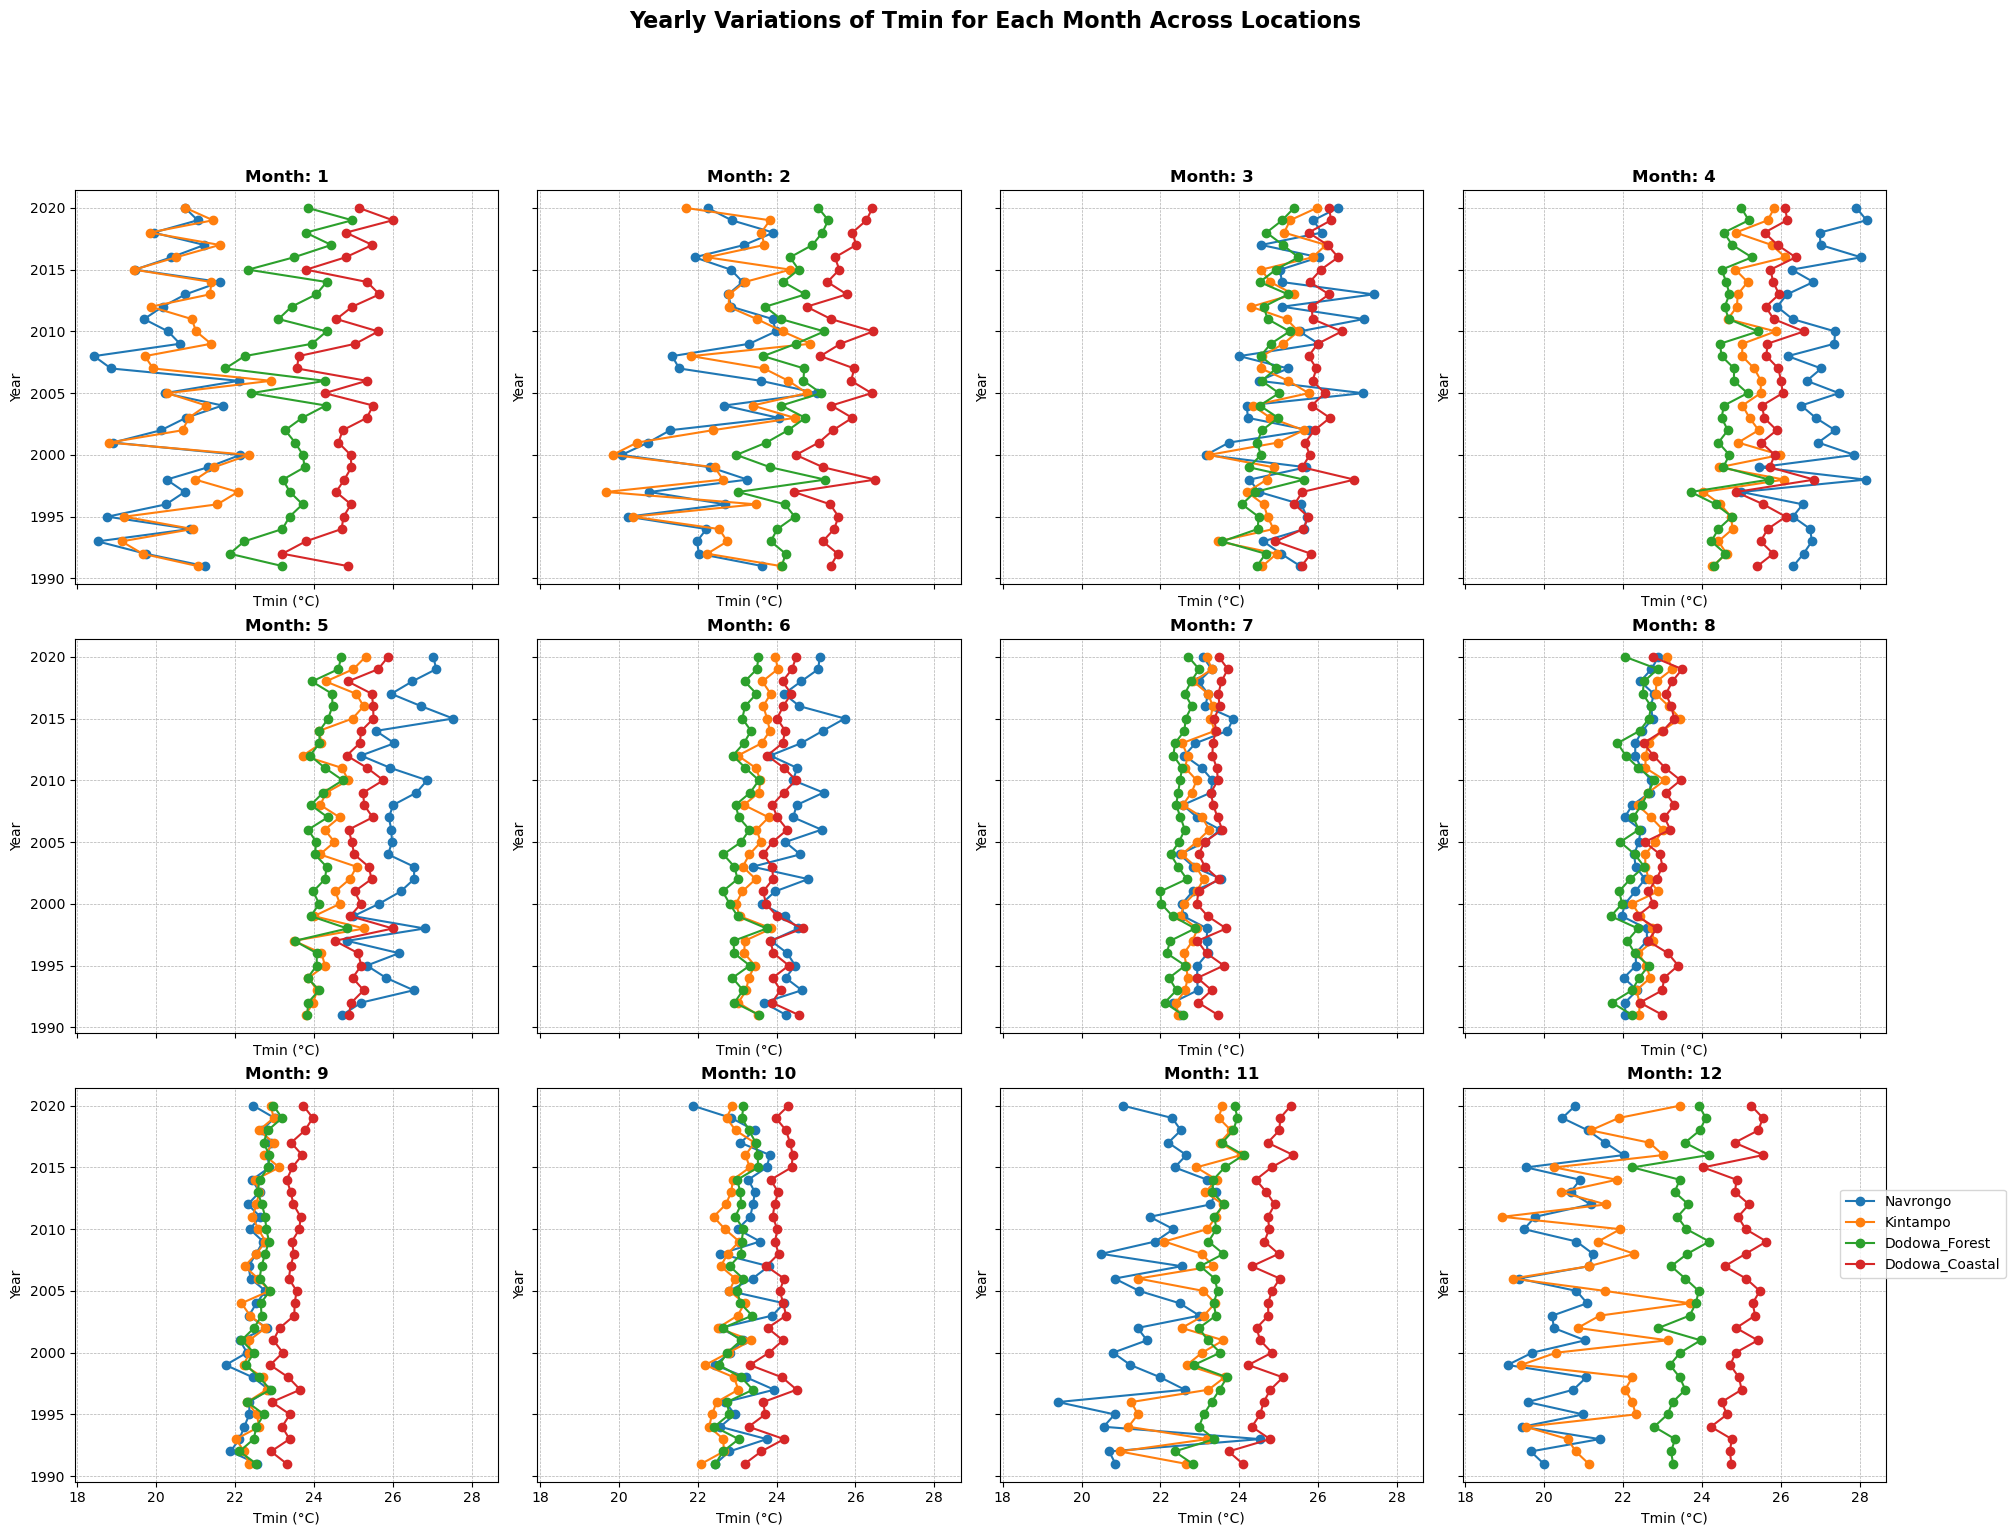

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
Navrongo = pd.read_csv('Navrongo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]
Kintampo = pd.read_csv('Kintampo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]
Dodowa_Forest = pd.read_csv('Dodowa_Forest_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]
Dodowa_Coastal = pd.read_csv('Dodowa_Coastal_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]

# Combine all datasets into a dictionary for easier access
datasets = {
    "Navrongo": Navrongo,
    "Kintampo": Kintampo,
    "Dodowa_Forest": Dodowa_Forest,
    "Dodowa_Coastal": Dodowa_Coastal
}

# Initialize the 3x4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the 3x4 grid for easier indexing

# Loop through each month (1 to 12)
for month in range(1, 13):
    ax = axes[month - 1]  # Select the subplot for the current month

    # Loop through each location dataset
    for location, data in datasets.items():
        # Filter data for the current month
        monthly_data = data[data['month'] == month]

        # Plot the Tmin values against the year for the current location
        ax.plot(monthly_data['Tmin'], monthly_data['year'], label=location, marker='o', linestyle='-')

    # Customize each subplot
    ax.set_title(f"Month: {month}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Tmin (°C)", fontsize=10)
    ax.set_ylabel("Year", fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.5)

# Add a legend to the last subplot
axes[11].legend(loc='lower right', bbox_to_anchor=(1.3, 0.5))

# Adjust layout for better appearance
plt.tight_layout()
plt.suptitle("Yearly Variations of Tmin for Each Month Across Locations", fontsize=16, fontweight='bold', y=1.02)
plt.subplots_adjust(top=0.9)

# Save the plot
#plt.savefig('yearly_variations_subplots.png', bbox_inches='tight', dpi=300)

# Show the plot
plt.show()


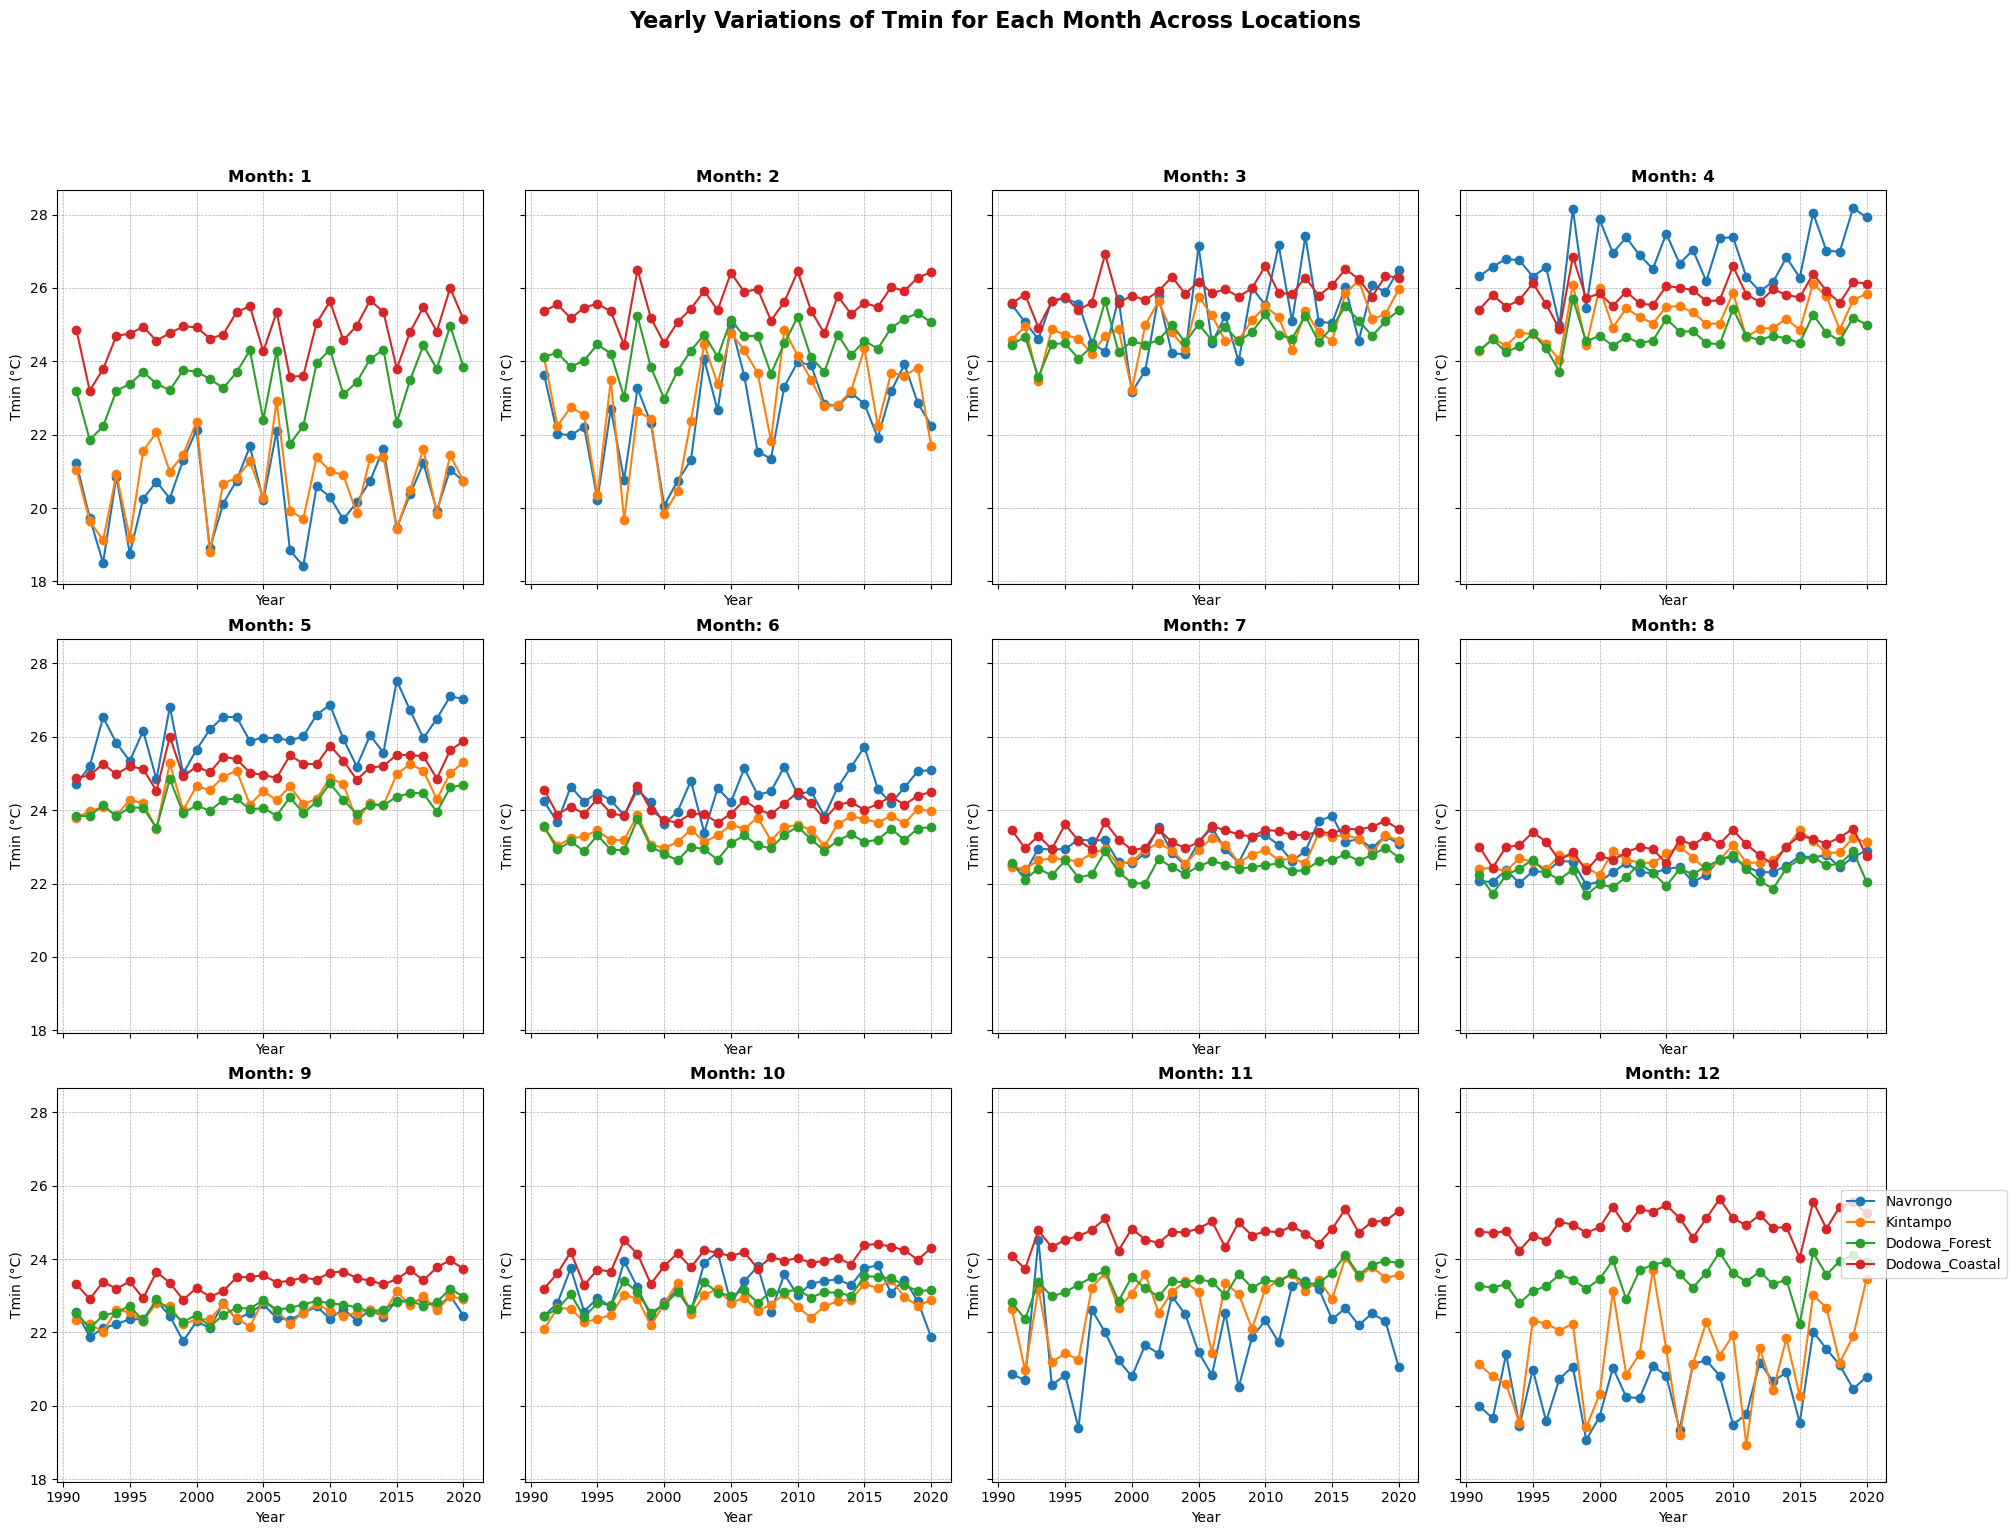

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
Navrongo = pd.read_csv('Navrongo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]
Kintampo = pd.read_csv('Kintampo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]
Dodowa_Forest = pd.read_csv('Dodowa_Forest_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]
Dodowa_Coastal = pd.read_csv('Dodowa_Coastal_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]

# Combine all datasets into a dictionary for easier access
datasets = {
    "Navrongo": Navrongo,
    "Kintampo": Kintampo,
    "Dodowa_Forest": Dodowa_Forest,
    "Dodowa_Coastal": Dodowa_Coastal
}

# Initialize the 3x4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the 3x4 grid for easier indexing

# Loop through each month (1 to 12)
for month in range(1, 13):
    ax = axes[month - 1]  # Select the subplot for the current month

    # Loop through each location dataset
    for location, data in datasets.items():
        # Filter data for the current month
        monthly_data = data[data['month'] == month]

        # Plot the Tmin values against the year for the current location
        ax.plot(monthly_data['year'], monthly_data['Tmin'], label=location, marker='o', linestyle='-')

    # Customize each subplot
    ax.set_title(f"Month: {month}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Tmin (°C)", fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.5)

# Add a legend to the last subplot
axes[11].legend(loc='lower right', bbox_to_anchor=(1.3, 0.5))

# Adjust layout for better appearance
plt.tight_layout()
plt.suptitle("Yearly Variations of Tmin for Each Month Across Locations", fontsize=16, fontweight='bold', y=1.02)
plt.subplots_adjust(top=0.9)

# Save the plot
#plt.savefig('yearly_variations_subplots_xaxis_year.png', bbox_inches='tight', dpi=300)

# Show the plot
plt.show()


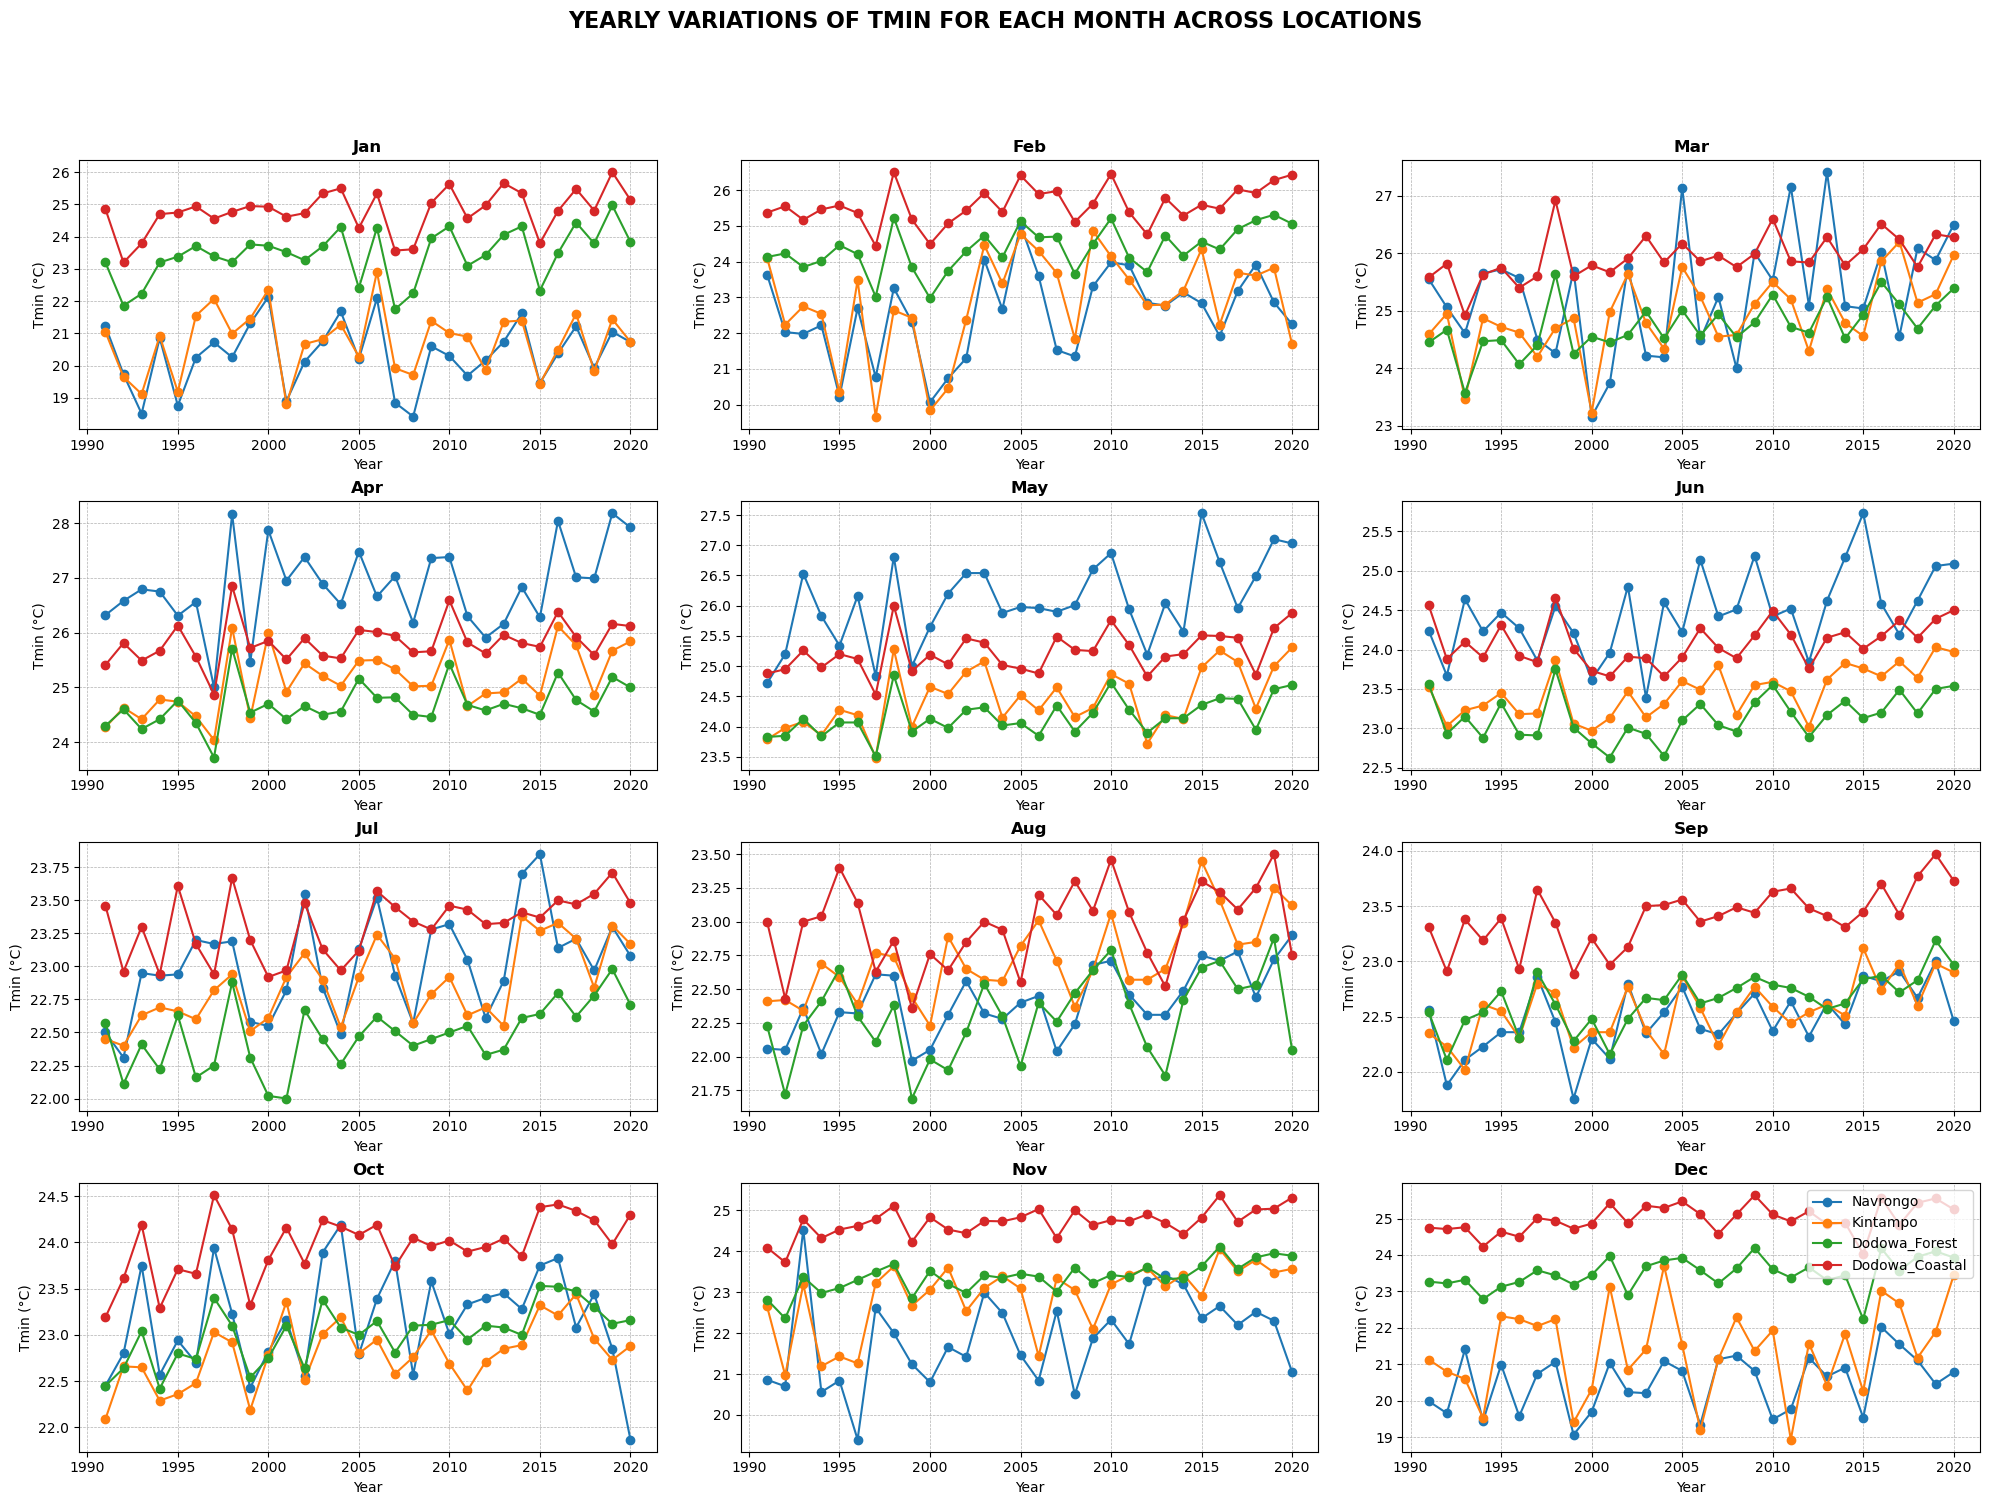

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
Navrongo = pd.read_csv('Navrongo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]
Kintampo = pd.read_csv('Kintampo_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]
Dodowa_Forest = pd.read_csv('Dodowa_Forest_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]
Dodowa_Coastal = pd.read_csv('Dodowa_Coastal_1991_2023_mmTn.txt', delim_whitespace=True, header=None, names=["year", "month", "Tmin"]).loc[0:359]

# Combine all datasets into a dictionary for easier access
datasets = {
    "Navrongo": Navrongo,
    "Kintampo": Kintampo,
    "Dodowa_Forest": Dodowa_Forest,
    "Dodowa_Coastal": Dodowa_Coastal
}

# Month names for the subplot titles
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Initialize the 3x4 subplot grid
fig, axes = plt.subplots(4, 3, figsize=(20, 15))
axes = axes.flatten()  # Flatten the 3x4 grid for easier indexing

# Loop through each month (1 to 12)
for month in range(1, 13):
    ax = axes[month - 1]  # Select the subplot for the current month

    # Loop through each location dataset
    for location, data in datasets.items():
        # Filter data for the current month
        monthly_data = data[data['month'] == month]

        # Plot the Tmin values against the year for the current location
        ax.plot(monthly_data['year'], monthly_data['Tmin'], label=location, marker='o', linestyle='-')

    # Customize each subplot
    ax.set_title(f"{month_names[month - 1]}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Tmin (°C)", fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.5)

# Add a legend to the last subplot
axes[11].legend(loc='upper right')# bbox_to_anchor=(1.3, 0.5))

# Adjust layout for better appearance
plt.tight_layout()
plt.suptitle("YEARLY VARIATIONS OF TMIN FOR EACH MONTH ACROSS LOCATIONS", fontsize=16, fontweight='bold', y=1.0)
plt.subplots_adjust(top=0.9)

# Save the plot
plt.savefig('yearly_variation.png', bbox_inches='tight', dpi=800)

# Show the plot
plt.show()


NEW DATASETS

In [23]:
ls


 Volume in drive C is Leo Nora
 Volume Serial Number is 0CCA-49D4

 Directory of C:\Users\WINFRED VORDOAGU\Desktop\PYTHON

06-Feb-25  06:43 PM    <DIR>          .
06-Feb-25  06:43 PM    <DIR>          ..
13-Jan-25  12:38 PM        43,501,509 .~Untitled2.ipynb
06-Feb-25  05:01 PM    <DIR>          .ipynb_checkpoints
18-Jul-22  07:15 PM             1,772 2151820525.ipynb
18-Jul-22  07:35 PM             1,275 2ghj.ipynb
30-Jan-25  05:53 AM        87,311,169 2m-temp.nc
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dRR_cgf.txt
06-Feb-25  12:28 PM           315,576 Accra_1981_2016_dRR_sat.txt
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dTn_cgf.txt
06-Feb-25  12:29 PM           315,576 Accra_1981_2016_dTn_sat.txt
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dTx_cgf.txt
06-Feb-25  12:29 PM           315,576 Accra_1981_2016_dTx_sat.txt
10-Mar-23  09:14 AM       252,480,856 Africa_cru_data.nc
19-Mar-23  05:47 PM        61,292,372 Africa_temp.nc
28-Jan-25  11:15 AM     

06-Feb-25  12:00 PM           315,576 Koforidua_1981_2016_dTx_cgf.txt
06-Feb-25  12:28 PM           315,576 Koforidua_1981_2016_dTx_sat.txt
28-Jan-25  11:34 AM           262,992 Koforidua_1991_2020_dRR.txt
28-Jan-25  11:34 AM           262,992 Koforidua_1991_2020_dTn.txt
28-Jan-25  11:34 AM           262,992 Koforidua_1991_2020_dTx.txt
09-Dec-24  08:52 AM             3,598 KORLEY's aSSIGNMENT (1).ipynb
20-Dec-24  11:51 AM           145,936 KORLEY's aSSIGNMENT.ipynb
06-Feb-25  12:00 PM           315,576 Kumasi_1981_2016_dRR_cgf.txt
06-Feb-25  12:28 PM           315,576 Kumasi_1981_2016_dRR_sat.txt
06-Feb-25  12:00 PM           315,576 Kumasi_1981_2016_dTn_cgf.txt
06-Feb-25  12:28 PM           315,576 Kumasi_1981_2016_dTn_sat.txt
06-Feb-25  12:00 PM           315,576 Kumasi_1981_2016_dTx_cgf.txt
06-Feb-25  12:28 PM           315,576 Kumasi_1981_2016_dTx_sat.txt
27-May-23  02:20 PM             1,952 LEONORA VORD.ipynb
18-Jun-24  01:23 PM            26,985 Maximum Temp.csv
17-Mar-24  08:18

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
Navrongo_1981_2016_Tmin = pd.read_csv('Navrongo_1981_2016_dTn_cgf.txt', delim_whitespace=True, header=None, names=["year","month","day", "Tmin"])
Navrongo_1981_2016_Tmax = pd.read_csv('Navrongo_1981_2016_dTx_cgf.txt', delim_whitespace=True, header=None, names=["year","month","day", "Tmax"])
Navrongo_1981_2016_RR = pd.read_csv('Navrongo_1981_2016_dRR_cgf.txt', delim_whitespace=True, header=None, names=["year","month","day", "RR"])


In [10]:
Navrongo_1981_2016_Tmin

,year,month,day,Tmin
0,1981,1,1,18.9
1,1981,1,2,20.0
2,1981,1,3,18.3
3,1981,1,4,19.4
4,1981,1,5,18.9
...,...,...,...,...
13144,2016,12,27,18.5
13145,2016,12,28,20.9
13146,2016,12,29,20.0
13147,2016,12,30,19.8


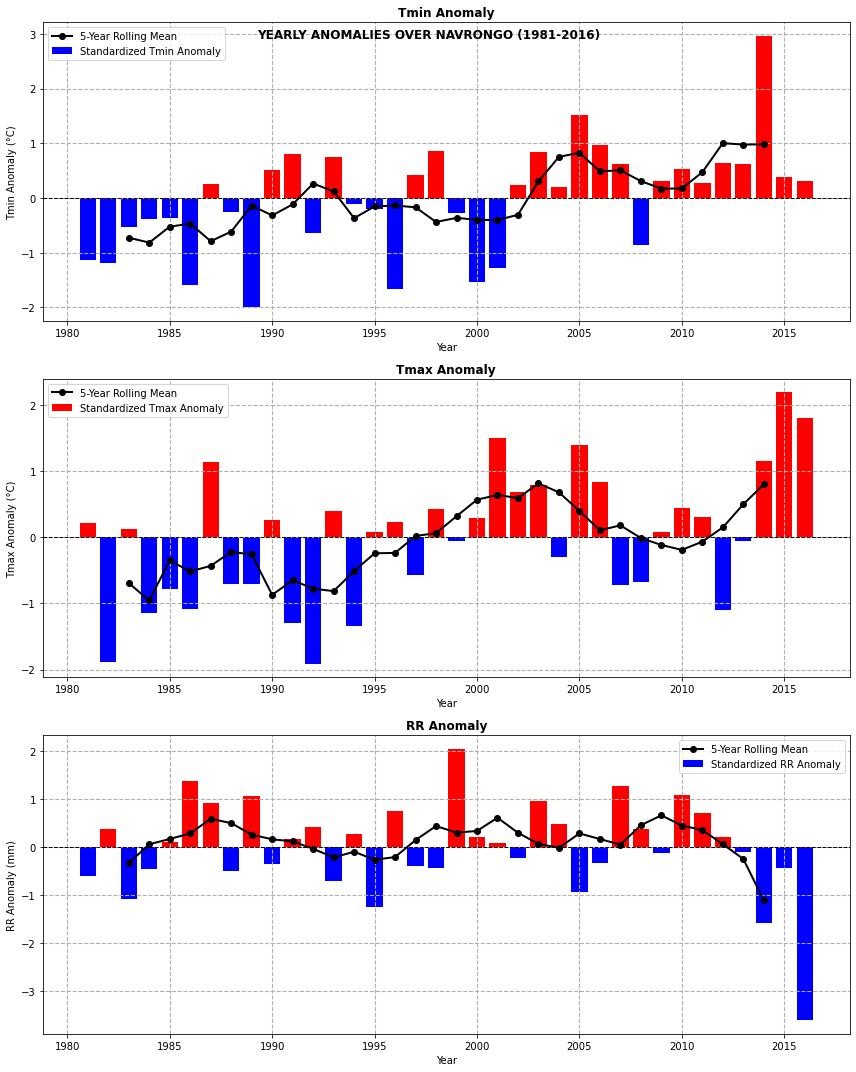

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
Navrongo_Tmin = pd.read_csv('Navrongo_1981_2016_dTn_cgf.txt', delim_whitespace=True, header=None, names=["year", "month", "day", "Tmin"])
Navrongo_Tmax = pd.read_csv('Navrongo_1981_2016_dTx_cgf.txt', delim_whitespace=True, header=None, names=["year", "month", "day", "Tmax"])
Navrongo_RR = pd.read_csv('Navrongo_1981_2016_dRR_cgf.txt', delim_whitespace=True, header=None, names=["year", "month", "day", "RR"])

# Aggregate daily data to yearly means
yearly_Tmin = Navrongo_Tmin.groupby("year")["Tmin"].mean().reset_index()
yearly_Tmax = Navrongo_Tmax.groupby("year")["Tmax"].mean().reset_index()
yearly_RR = Navrongo_RR.groupby("year")["RR"].mean().reset_index()

# Merge datasets into a single DataFrame
Navrongo = yearly_Tmin.merge(yearly_Tmax, on="year").merge(yearly_RR, on="year")

# Function to calculate anomalies and 5-year rolling mean
def calculate_anomalies_and_rolling_mean(data, variable):
    long_term_mean = data[variable].mean()
    std_dev = data[variable].std()
    data[f'standardized_anomaly_{variable}'] = (data[variable] - long_term_mean) / std_dev
    data[f'rolling_mean_{variable}'] = data[f'standardized_anomaly_{variable}'].rolling(window=5, center=True).mean()
    return data

# Variables and units
variables = {
    'Tmin': '°C',
    'Tmax': '°C',
    'RR': 'mm'
}

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15))
axes = axes.flatten()

# Loop through variables and plot
for i, (variable, unit) in enumerate(variables.items()):
    anomalies = calculate_anomalies_and_rolling_mean(Navrongo, variable)
    colors = ['red' if val > 0 else 'blue' for val in anomalies[f'standardized_anomaly_{variable}']]
    
    axes[i].bar(anomalies['year'], anomalies[f'standardized_anomaly_{variable}'], color=colors, label=f'Standardized {variable} Anomaly')
    axes[i].plot(anomalies['year'], anomalies[f'rolling_mean_{variable}'], color='black', linewidth=2, marker='o', label='5-Year Rolling Mean')
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)
    
    axes[i].set_title(f'{variable} Anomaly', fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'{variable} Anomaly ({unit})')
    axes[i].grid(True, linestyle='--', linewidth=1.1)
    axes[i].legend(loc='best')
    
plt.tight_layout()
plt.suptitle('YEARLY ANOMALIES OVER NAVRONGO (1981-2016)', fontsize=12, fontweight='bold', y=0.97)
#fig.savefig('NAVRONGO_YEARLY_ANOMALIES.png', bbox_inches='tight', dpi=500)
plt.show()


In [25]:
ls

 Volume in drive C is Leo Nora
 Volume Serial Number is 0CCA-49D4

 Directory of C:\Users\WINFRED VORDOAGU\Desktop\PYTHON

07-Feb-25  08:31 AM    <DIR>          .
07-Feb-25  08:31 AM    <DIR>          ..
13-Jan-25  12:38 PM        43,501,509 .~Untitled2.ipynb
06-Feb-25  05:01 PM    <DIR>          .ipynb_checkpoints
18-Jul-22  07:15 PM             1,772 2151820525.ipynb
18-Jul-22  07:35 PM             1,275 2ghj.ipynb
30-Jan-25  05:53 AM        87,311,169 2m-temp.nc
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dRR_cgf.txt
06-Feb-25  12:28 PM           315,576 Accra_1981_2016_dRR_sat.txt
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dTn_cgf.txt
06-Feb-25  12:29 PM           315,576 Accra_1981_2016_dTn_sat.txt
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dTx_cgf.txt
06-Feb-25  12:29 PM           315,576 Accra_1981_2016_dTx_sat.txt
10-Mar-23  09:14 AM       252,480,856 Africa_cru_data.nc
19-Mar-23  05:47 PM        61,292,372 Africa_temp.nc
28-Jan-25  11:15 AM     

In [24]:
import pandas as pd

In [29]:
dforest= pd.read_csv('DForest.txt', delim_whitespace=True)
dforest

,DD/MM/YY,Tmin,Tmax,Tmean,Rain,RH,Humidex,UTCI
0,01/01/1991,21.51,29.05,25.28,0.0,45.87,27.92,26.26
1,02/01/1991,18.81,29.96,24.38,0.0,45.48,26.52,26.62
2,03/01/1991,19.76,30.43,25.09,0.0,53.25,28.94,28.53
3,04/01/1991,20.71,31.59,26.15,0.0,57.39,31.39,29.76
4,05/01/1991,21.61,31.73,26.67,0.0,64.02,33.53,30.92
...,...,...,...,...,...,...,...,...
12048,27/12/2023,26.39,34.90,30.64,0.0,96.28,48.57,32.60
12049,28/12/2023,26.16,33.49,29.83,0.0,91.44,45.57,32.52
12050,29/12/2023,25.83,34.59,30.21,0.0,89.13,45.87,32.12
12051,30/12/2023,25.98,35.39,30.69,0.0,91.45,47.51,32.23


In [58]:
import pandas as pd

# Load the data
dforest = pd.read_csv('DForest.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
dforest[['day', 'month', 'year']] = dforest['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
dforest['day'] = dforest['day'].astype(int)
dforest['month'] = dforest['month'].astype(int)
dforest['year'] = dforest['year'].astype(int)
dforest = dforest.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in dforest.columns if col not in ['day', 'month', 'year']]
dforest = dforest[columns_order]
dforest.to_csv('dforst.csv')
# Load the data
dcoastal = pd.read_csv('DCoastal.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
dcoastal[['day', 'month', 'year']] = dcoastal['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
dcoastal['day'] = dcoastal['day'].astype(int)
dcoastal['month'] = dcoastal['month'].astype(int)
dcoastal['year'] = dcoastal['year'].astype(int)
dcoastal = dcoastal.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in dcoastal.columns if col not in ['day', 'month', 'year']]
dcoastal = dcoastal[columns_order]
dcoastal.to_csv('dcoast.csv')

# Load the data
kin = pd.read_csv('KINTAMP.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
kin[['day', 'month', 'year']] = kin['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
kin['day'] = kin['day'].astype(int)
kin['month'] = kin['month'].astype(int)
kin['year'] = kin['year'].astype(int)
kin = kin.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in kin.columns if col not in ['day', 'month', 'year']]
kin = kin[columns_order]
kin.to_csv('Kin.csv')

# Load the data
Nav = pd.read_csv('NAV.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
Nav[['day', 'month', 'year']] = Nav['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
Nav['day'] = Nav['day'].astype(int)
Nav['month'] = Nav['month'].astype(int)
Nav['year'] = Nav['year'].astype(int)
Nav = Nav.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in Nav.columns if col not in ['day', 'month', 'year']]
Nav = Nav[columns_order]
Nav.to_csv('Nav.csv')

In [53]:
dforest.loc[0:10957]

,day,month,year,Tmin,Tmax,Tmean,Rain,RH,Humidex,UTCI
0,1,1,1991,21.51,29.05,25.28,0.0,45.87,27.92,26.26
1,2,1,1991,18.81,29.96,24.38,0.0,45.48,26.52,26.62
2,3,1,1991,19.76,30.43,25.09,0.0,53.25,28.94,28.53
3,4,1,1991,20.71,31.59,26.15,0.0,57.39,31.39,29.76
4,5,1,1991,21.61,31.73,26.67,0.0,64.02,33.53,30.92
...,...,...,...,...,...,...,...,...,...,...
10953,27,12,2020,24.25,32.73,28.49,0.0,77.25,39.59,31.25
10954,28,12,2020,24.57,33.53,29.05,0.0,76.84,40.61,31.39
10955,29,12,2020,23.51,33.85,28.68,0.0,72.98,39.03,31.18
10956,30,12,2020,23.46,34.43,28.95,0.0,75.26,40.06,30.94


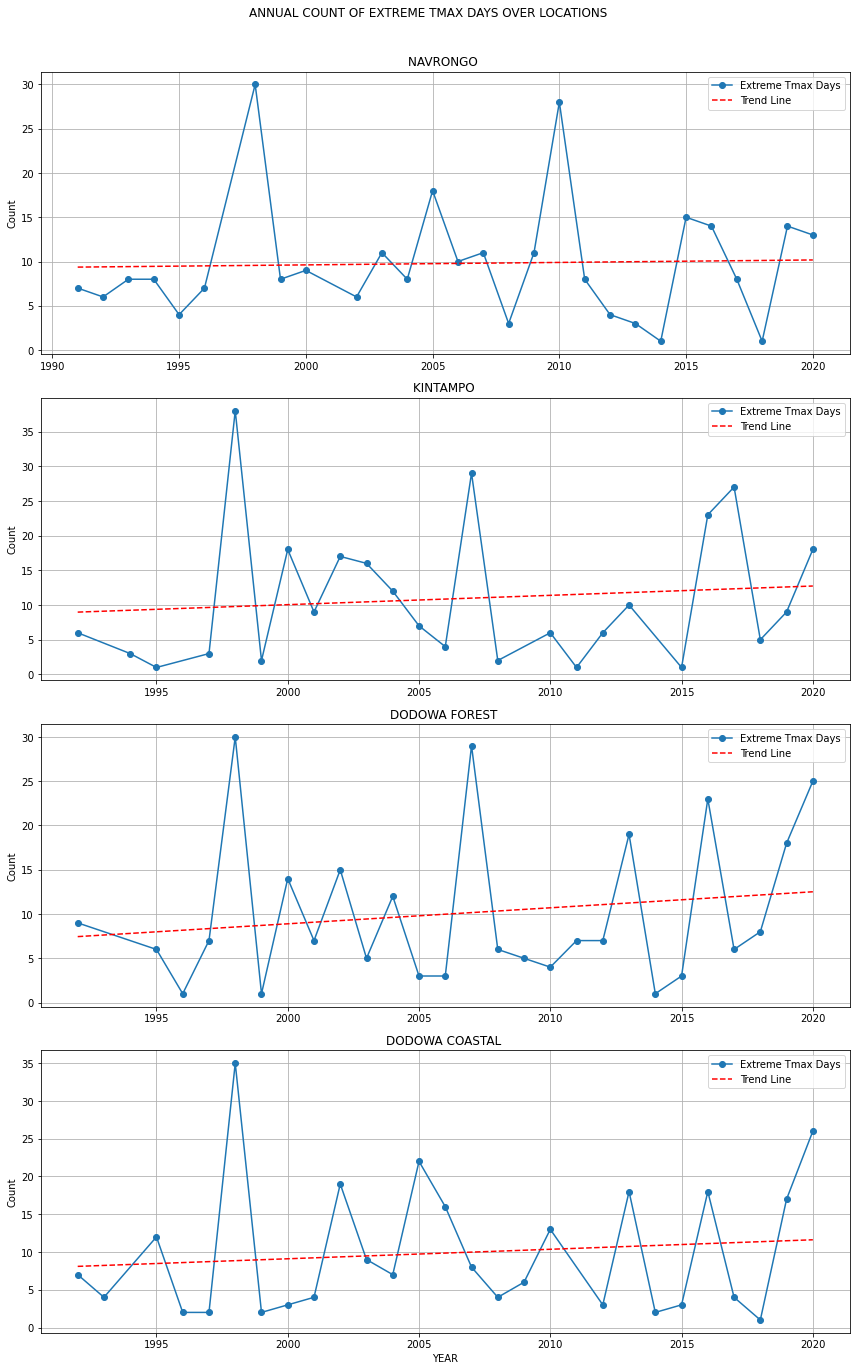

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the datasets for four locations (assuming they are in separate CSV files)
locations = ["Nav.csv", "Kin.csv", "dforst.csv", "dcoast.csv"]
location_names = ["NAVRONGO", "KINTAMPO", "DODOWA FOREST", "DODOWA COASTAL"]

fig, axes = plt.subplots(4, 1, figsize=(12, 20))

for i, (file, name) in enumerate(zip(locations, location_names)):
    df = pd.read_csv(file)  # Change to the actual file paths if needed
    df = df.loc[0:10957]
    # Calculate the 97.5th percentile of Tmax
    percentile_97_5 = df["Tmax"].quantile(0.975)
    
    # Identify days where Tmax exceeds the 97.5th percentile
    df_exceeding = df[df["Tmax"] > percentile_97_5]
    
    # Count number of exceeding days per year
    exceeding_days_per_year = df_exceeding.groupby("year").size()
    
    # Plot the results
    axes[i].plot(exceeding_days_per_year.index, exceeding_days_per_year.values, marker='o', linestyle='-', label="Extreme Tmax Days")
    
    # Add trend line
    if len(exceeding_days_per_year) > 1:
        z = np.polyfit(exceeding_days_per_year.index, exceeding_days_per_year.values, 1)
        p = np.poly1d(z)
        axes[i].plot(exceeding_days_per_year.index, p(exceeding_days_per_year.index), linestyle='--', color='red', label="Trend Line")
    
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"{name} ")
    axes[i].legend()
    axes[i].grid()

plt.xlabel("YEAR")
plt.suptitle("ANNUAL COUNT OF EXTREME TMAX DAYS OVER LOCATIONS")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [68]:
ls

 Volume in drive C is Leo Nora
 Volume Serial Number is 0CCA-49D4

 Directory of C:\Users\WINFRED VORDOAGU\Desktop\PYTHON

07-Feb-25  01:05 PM    <DIR>          .
07-Feb-25  01:05 PM    <DIR>          ..
13-Jan-25  12:38 PM        43,501,509 .~Untitled2.ipynb
06-Feb-25  05:01 PM    <DIR>          .ipynb_checkpoints
18-Jul-22  07:15 PM             1,772 2151820525.ipynb
18-Jul-22  07:35 PM             1,275 2ghj.ipynb
30-Jan-25  05:53 AM        87,311,169 2m-temp.nc
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dRR_cgf.txt
06-Feb-25  12:28 PM           315,576 Accra_1981_2016_dRR_sat.txt
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dTn_cgf.txt
06-Feb-25  12:29 PM           315,576 Accra_1981_2016_dTn_sat.txt
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dTx_cgf.txt
06-Feb-25  12:29 PM           315,576 Accra_1981_2016_dTx_sat.txt
10-Mar-23  09:14 AM       252,480,856 Africa_cru_data.nc
19-Mar-23  05:47 PM        61,292,372 Africa_temp.nc
28-Jan-25  11:15 AM     

23-Jan-25  06:49 PM             7,524 Navrongo_1991_2023_mmRR.txt
23-Jan-25  06:49 PM             7,524 Navrongo_1991_2023_mmTm.txt
23-Jan-25  06:49 PM             7,524 Navrongo_1991_2023_mmTn.txt
23-Jan-25  06:49 PM             7,524 Navrongo_1991_2023_mmTx.txt
23-Jan-25  06:49 PM             7,524 Navrongo_1991_2023_mmUTCI.txt
23-Jan-25  06:47 PM               462 Navrongo_1991_2023_yyHI.txt
23-Jan-25  06:47 PM               462 Navrongo_1991_2023_yyHumidex.txt
23-Jan-25  06:47 PM               462 Navrongo_1991_2023_yyRH.txt
23-Jan-25  06:47 PM               462 Navrongo_1991_2023_yyRR.txt
23-Jan-25  06:47 PM               462 Navrongo_1991_2023_yyTm.txt
23-Jan-25  06:47 PM               462 Navrongo_1991_2023_yyTn.txt
23-Jan-25  06:47 PM               462 Navrongo_1991_2023_yyTx.txt
23-Jan-25  06:47 PM               462 Navrongo_1991_2023_yyUTCI.txt
21-Jan-25  08:52 AM            12,972 Negative_Rainfall_Data.xlsx
06-Feb-25  04:36 PM               850 new_pro.ipynb
06-Feb-25  04:5

CORRELATION

In [ ]:
Navrongo_1981_2016_dRR_cgf.txt
Navrongo_1981_2016_dRR_sat.txt
Wa_1981_2016_dRR_cgf.txt
Wa_1981_2016_dRR_sat.txt
Tamale_1981_2016_dRR_cgf.txt
Tamale_1981_2016_dRR_sat.txt
Sunyani_1981_2016_dRR_cgf.txt
Sunyani_1981_2016_dRR_sat.txt
Tema_1981_2016_dRR_cgf.txt
Tema_1981_2016_dRR_sat.txt
Accra_1981_2016_dRR_cgf.txt
Accra_1981_2016_dRR_sat.txt
Koforidua_1981_2016_dRR_cgf.txt
Koforidua_1981_2016_dRR_sat.txt
Kumasi_1981_2016_dRR_cgf.txt
Kumasi_1981_2016_dRR_sat.txt
Takoradi_1981_2016_dRR_cgf.txt
Takoradi_1981_2016_dRR_sat.txt

In [73]:
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_sat=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])
Navrongo_gauge=pd.read_csv('Takoradi_1981_2016_dRR_sat.txt',delim_whitespace=True, names=['year','month','day','RR'])


,year,month,day,RR
0,1981,1,1,0.00
1,1981,1,2,0.00
2,1981,1,3,0.00
3,1981,1,4,0.00
4,1981,1,5,0.00
...,...,...,...,...
13144,2016,12,27,0.41
13145,2016,12,28,0.00
13146,2016,12,29,0.00
13147,2016,12,30,0.00


In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define locations and corresponding files
locations = ["Navrongo", "Wa", "Tamale", "Sunyani", "Tema", "Accra", "Koforidua", "Kumasi", "Takoradi"]
gauge_files = [f"{loc}_1981_2016_dRR_cgf.txt" for loc in locations]
sat_files = [f"{loc}_1981_2016_dRR_sat.txt" for loc in locations]

# Load data into dictionaries
gauge_data = {loc: pd.read_csv(gauge_file, delim_whitespace=True, names=['year', 'month', 'day', 'RR'])
              for loc, gauge_file in zip(locations, gauge_files)}

sat_data = {loc: pd.read_csv(sat_file, delim_whitespace=True, names=['year', 'month', 'day', 'RR'])
            for loc, sat_file in zip(locations, sat_files)}

# Now you have separate dictionaries containing the correct gauge and satellite data for each location


In [75]:
gauge_data

{'Navrongo':        year  month  day   RR
 0      1981      1    1  0.0
 1      1981      1    2  0.0
 2      1981      1    3  0.0
 3      1981      1    4  0.0
 4      1981      1    5  0.0
 ...     ...    ...  ...  ...
 13144  2016     12   27  0.0
 13145  2016     12   28  0.0
 13146  2016     12   29  0.0
 13147  2016     12   30  0.0
 13148  2016     12   31  0.0
 
 [13149 rows x 4 columns],
 'Wa':        year  month  day    RR
 0      1981      1    1  0.82
 1      1981      1    2  0.05
 2      1981      1    3  0.00
 3      1981      1    4  0.00
 4      1981      1    5  0.00
 ...     ...    ...  ...   ...
 13144  2016     12   27  0.00
 13145  2016     12   28  0.00
 13146  2016     12   29  1.16
 13147  2016     12   30  0.00
 13148  2016     12   31  0.00
 
 [13149 rows x 4 columns],
 'Tamale':        year  month  day   RR
 0      1981      1    1  0.0
 1      1981      1    2  0.0
 2      1981      1    3  0.0
 3      1981      1    4  0.0
 4      1981      1    5  0.0
 .

Monthly Analysis: Gauge vs Satellite Rainfall

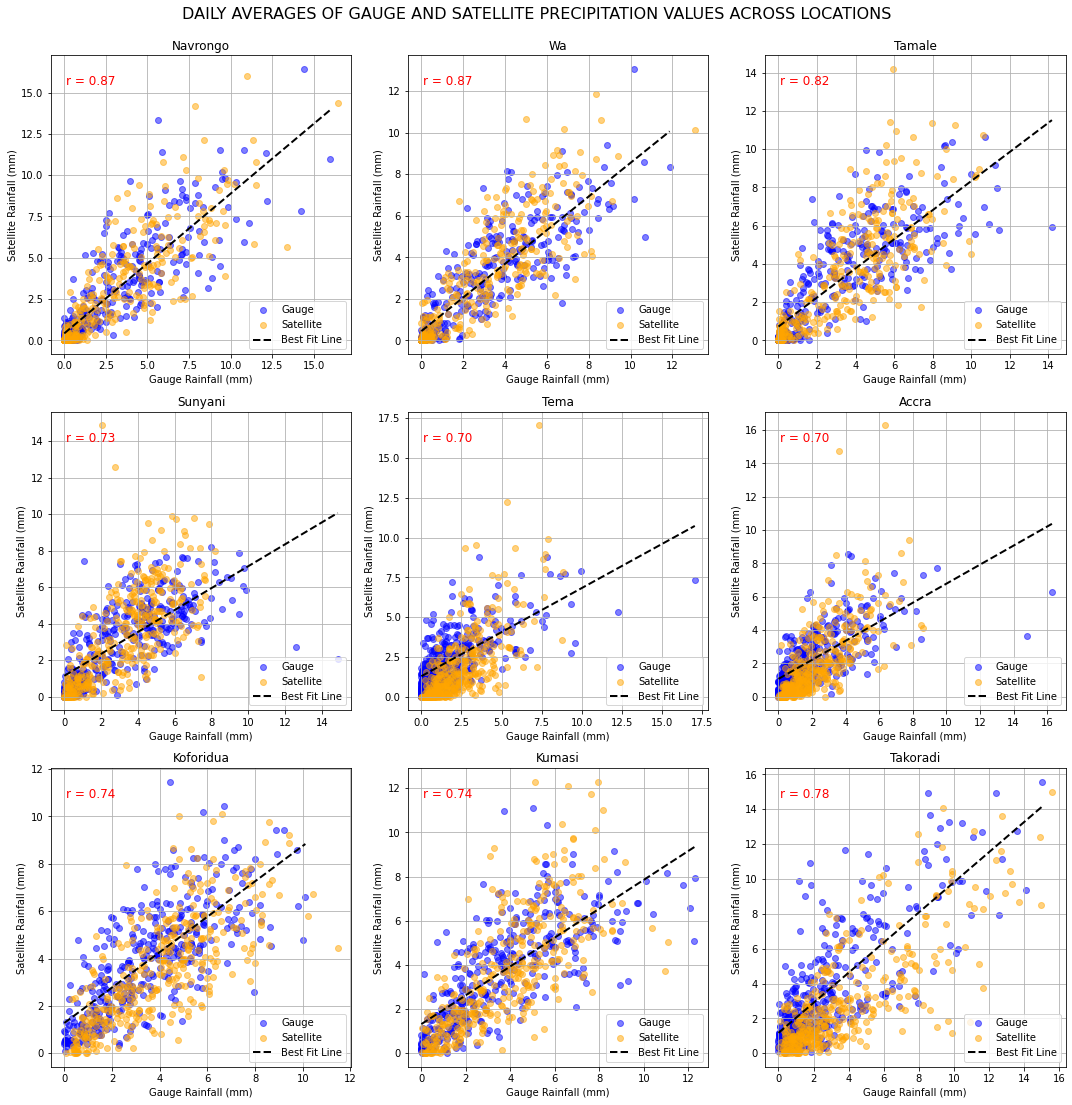

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define locations and corresponding files
locations = ["Navrongo", "Wa", "Tamale", "Sunyani", "Tema", "Accra", "Koforidua", "Kumasi", "Takoradi"]
gauge_files = [f"{loc}_1981_2016_dRR_cgf.txt" for loc in locations]
sat_files = [f"{loc}_1981_2016_dRR_sat.txt" for loc in locations]

# Load data into dictionaries
gauge_data = {loc: pd.read_csv(gauge_file, delim_whitespace=True, names=['year', 'month', 'day', 'RR'])
              for loc, gauge_file in zip(locations, gauge_files)}

sat_data = {loc: pd.read_csv(sat_file, delim_whitespace=True, names=['year', 'month', 'day', 'RR'])
            for loc, sat_file in zip(locations, sat_files)}

# Initialize plot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # 3x3 subplot grid
axes = axes.flatten()

for i, loc in enumerate(locations):
    # Merge gauge and satellite datasets on year, month, and day
    merged_df = pd.merge(gauge_data[loc], sat_data[loc], on=['year', 'month', 'day'], suffixes=('_gauge', '_sat'))
    
    # Compute daily averages across all years
    daily_avg_df = merged_df.groupby(['month', 'day'])[['RR_gauge', 'RR_sat']].mean().reset_index()

    # Compute correlation
    correlation = daily_avg_df["RR_gauge"].corr(daily_avg_df["RR_sat"])
    
    # Scatter plot
    axes[i].scatter(daily_avg_df["RR_gauge"], daily_avg_df["RR_sat"], alpha=0.5, color="blue", label="Gauge")
    axes[i].scatter(daily_avg_df["RR_sat"], daily_avg_df["RR_gauge"], alpha=0.5, color="orange", label="Satellite")
    
    # Compute and plot line of best fit
    m, b = np.polyfit(daily_avg_df["RR_gauge"], daily_avg_df["RR_sat"], 1)  # Linear fit (y = mx + b)
    x_fit = np.linspace(daily_avg_df["RR_gauge"].min(), daily_avg_df["RR_gauge"].max(), 100)
    y_fit = m * x_fit + b
    axes[i].plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, label="Best Fit Line")
    
    # Labels and title
    axes[i].set_xlabel("Gauge Rainfall (mm)", fontsize=10)
    axes[i].set_ylabel("Satellite Rainfall (mm)", fontsize=10)
    axes[i].set_title(f"{loc}", fontsize=12)
    
    # Annotate correlation coefficient
    axes[i].text(0.05, 0.9, f"r = {correlation:.2f}", transform=axes[i].transAxes, fontsize=12, color="red")
    
    axes[i].grid(True)
    axes[i].legend(loc='lower right')

# Adjust layout
plt.tight_layout()
plt.suptitle("DAILY AVERAGES OF GAUGE AND SATELLITE PRECIPITATION VALUES ACROSS LOCATIONS", fontsize=16, y=1.02)
plt.savefig('DAILY_All_Locations.png', bbox_inches='tight', dpi=800)
plt.show()


In [113]:
ls

 Volume in drive C is Leo Nora
 Volume Serial Number is 0CCA-49D4

 Directory of C:\Users\WINFRED VORDOAGU\Desktop\PYTHON

07-Feb-25  03:03 PM    <DIR>          .
07-Feb-25  03:03 PM    <DIR>          ..
13-Jan-25  12:38 PM        43,501,509 .~Untitled2.ipynb
06-Feb-25  05:01 PM    <DIR>          .ipynb_checkpoints
18-Jul-22  07:15 PM             1,772 2151820525.ipynb
18-Jul-22  07:35 PM             1,275 2ghj.ipynb
30-Jan-25  05:53 AM        87,311,169 2m-temp.nc
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dRR_cgf.txt
06-Feb-25  12:28 PM           315,576 Accra_1981_2016_dRR_sat.txt
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dTn_cgf.txt
06-Feb-25  12:29 PM           315,576 Accra_1981_2016_dTn_sat.txt
06-Feb-25  12:00 PM           315,576 Accra_1981_2016_dTx_cgf.txt
06-Feb-25  12:29 PM           315,576 Accra_1981_2016_dTx_sat.txt
10-Mar-23  09:14 AM       252,480,856 Africa_cru_data.nc
19-Mar-23  05:47 PM        61,292,372 Africa_temp.nc
28-Jan-25  11:15 AM     

In [120]:
pd.read_csv('Navrongo_1981_2016_dTx_cgf.txt',delim_whitespace=True, names=['year','month','day','Tmax'])

,year,month,day,Tmax
0,1981,1,1,35.6
1,1981,1,2,33.9
2,1981,1,3,33.3
3,1981,1,4,33.3
4,1981,1,5,33.3
...,...,...,...,...
13144,2016,12,27,34.3
13145,2016,12,28,34.6
13146,2016,12,29,35.0
13147,2016,12,30,36.6


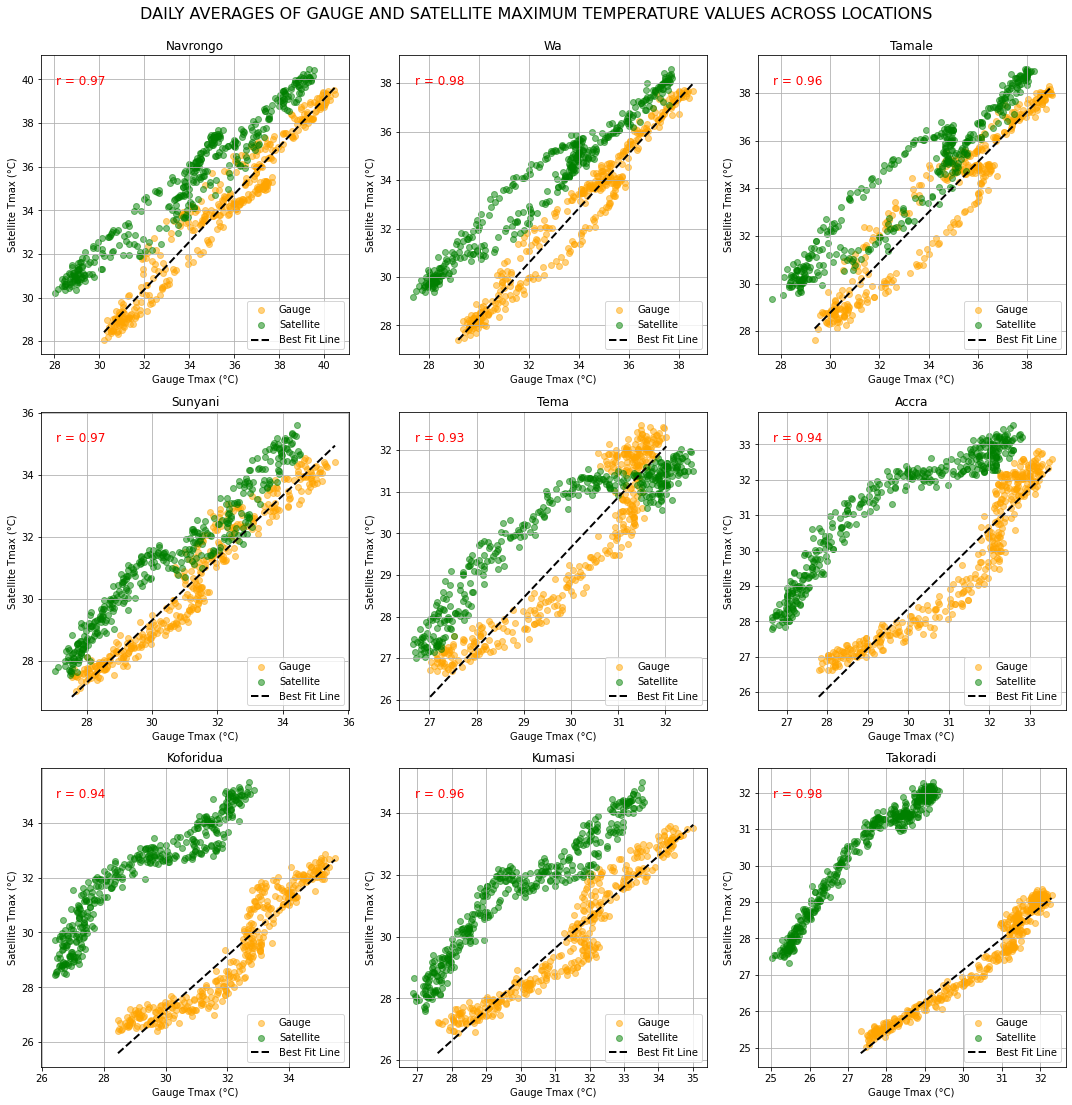

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define locations and corresponding files
locations = ["Navrongo", "Wa", "Tamale", "Sunyani", "Tema", "Accra", "Koforidua", "Kumasi", "Takoradi"]
gauge_files = [f"{loc}_1981_2016_dTx_cgf.txt" for loc in locations]
sat_files = [f"{loc}_1981_2016_dTx_sat.txt" for loc in locations]

# Load data into dictionaries
gauge_data = {loc: pd.read_csv(gauge_file, delim_whitespace=True, names=['year', 'month', 'day', 'Tmax'])
              for loc, gauge_file in zip(locations, gauge_files)}

sat_data = {loc: pd.read_csv(sat_file, delim_whitespace=True, names=['year', 'month', 'day', 'Tmax'])
            for loc, sat_file in zip(locations, sat_files)}

# Initialize plot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # 3x3 subplot grid
axes = axes.flatten()

for i, loc in enumerate(locations):
    # Merge gauge and satellite datasets on year, month, and day
    merged_df = pd.merge(gauge_data[loc], sat_data[loc], on=['year', 'month', 'day'], suffixes=('_gauge', '_sat'))
    
    # Compute daily averages across all years
    daily_avg_df = merged_df.groupby(['month', 'day'])[['Tmax_gauge', 'Tmax_sat']].mean().reset_index()

    # Compute correlation
    correlation = daily_avg_df["Tmax_gauge"].corr(daily_avg_df["Tmax_sat"])
    
    # Scatter plot
    axes[i].scatter(daily_avg_df["Tmax_gauge"], daily_avg_df["Tmax_sat"], alpha=0.5, color="orange", label="Gauge")
    axes[i].scatter(daily_avg_df["Tmax_sat"], daily_avg_df["Tmax_gauge"], alpha=0.5, color="green", label="Satellite")
    
    # Compute and plot line of best fit
    m, b = np.polyfit(daily_avg_df["Tmax_gauge"], daily_avg_df["Tmax_sat"], 1)  # Linear fit (y = mx + b)
    x_fit = np.linspace(daily_avg_df["Tmax_gauge"].min(), daily_avg_df["Tmax_gauge"].max(), 100)
    y_fit = m * x_fit + b
    axes[i].plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, label="Best Fit Line")
    
    # Labels and title
    axes[i].set_xlabel("Gauge Tmax (°C)", fontsize=10)
    axes[i].set_ylabel("Satellite Tmax (°C)", fontsize=10)
    axes[i].set_title(f"{loc}", fontsize=12)
    
    # Annotate correlation coefficient
    axes[i].text(0.05, 0.9, f"r = {correlation:.2f}", transform=axes[i].transAxes, fontsize=12, color="red")
    
    axes[i].grid(True)
    axes[i].legend(loc='lower right')

# Adjust layout
plt.tight_layout()
plt.suptitle("DAILY AVERAGES OF GAUGE AND SATELLITE MAXIMUM TEMPERATURE VALUES ACROSS LOCATIONS", fontsize=16, y=1.02)
#plt.savefig('DAILY_TMAX_All_Locations.png', bbox_inches='tight', dpi=800)
plt.show()


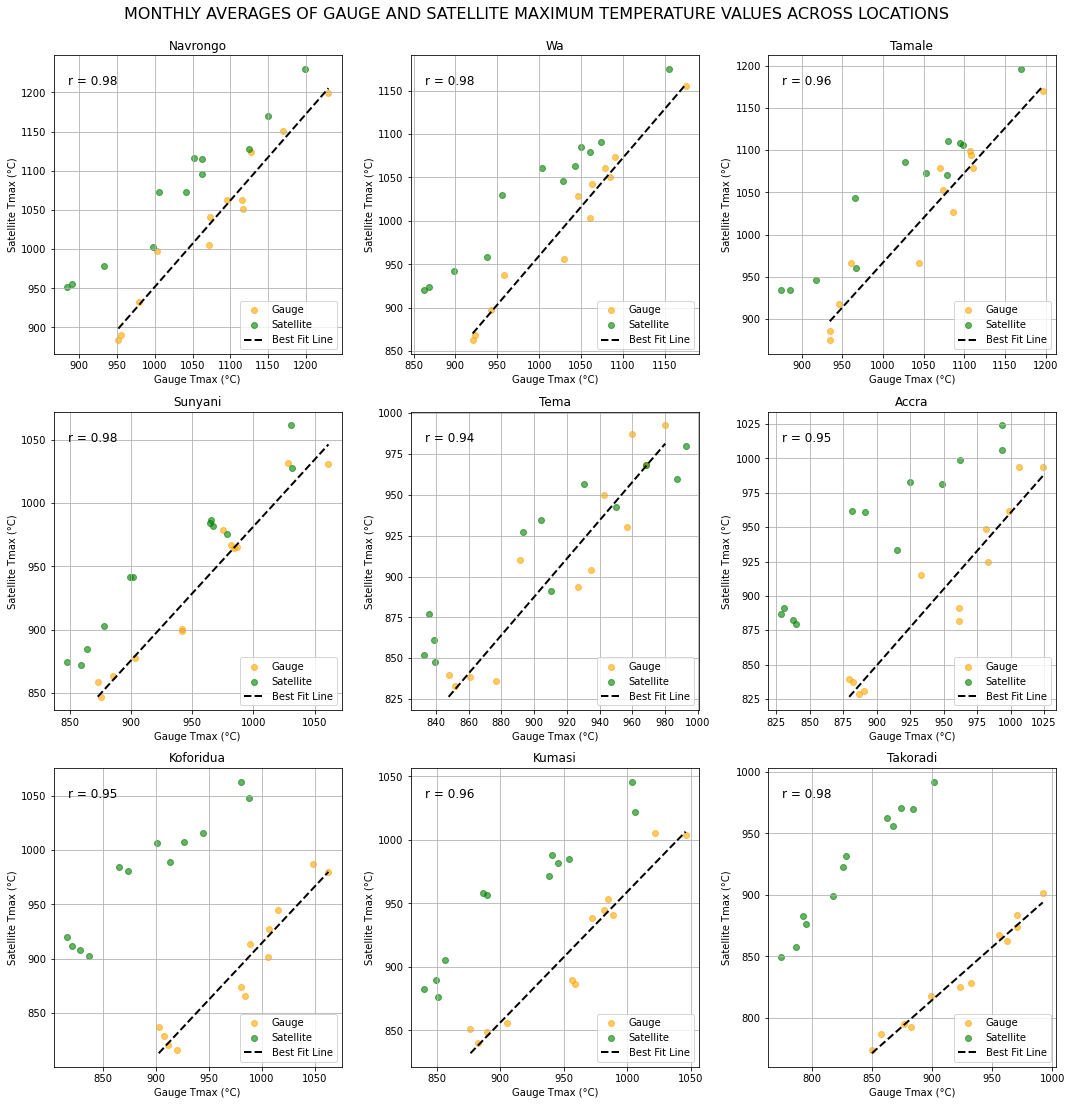

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

# Define locations and corresponding files
locations = ["Navrongo", "Wa", "Tamale", "Sunyani", "Tema", "Accra", "Koforidua", "Kumasi", "Takoradi"]
gauge_files = {loc: f"{loc}_1981_2016_dTx_cgf.txt" for loc in locations}
sat_files = {loc: f"{loc}_1981_2016_dTx_sat.txt" for loc in locations}

# Load data
gauge_data = {loc: pd.read_csv(gauge_files[loc], delim_whitespace=True, names=['year', 'month', 'day', 'Tmax']) 
              for loc in locations}
sat_data = {loc: pd.read_csv(sat_files[loc], delim_whitespace=True, names=['year', 'month', 'day', 'Tmax']) 
            for loc in locations}

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, loc in enumerate(locations):
    # Merge gauge and satellite datasets
    merged_df = pd.merge(gauge_data[loc], sat_data[loc], on=['year', 'month', 'day'], suffixes=('_gauge', '_sat'))
    
    # Aggregate by month
    #monthly_df = merged_df.groupby("month")[["RR_gauge", "RR_sat"]].sum().reset_index()
  
    
    # Compute monthly total rainfall
    monthly_total = merged_df.groupby(["year", "month"])[["Tmax_gauge", "Tmax_sat"]].sum().reset_index()
    
    # Compute monthly mean rainfall (divide by number of years)
    num_years = len(monthly_total["year"].unique())  # Number of years in dataset
    monthly_df = monthly_total.groupby("month")[["Tmax_gauge", "Tmax_sat"]].mean()   # Monthly mean
    
    
    
      # Compute correlation
    correlation = monthly_df["Tmax_gauge"].corr(monthly_df["Tmax_sat"])
    
    # Scatter plot
    axes[i].scatter(monthly_df["Tmax_gauge"], monthly_df["Tmax_sat"], color='orange', label="Gauge", alpha=0.6)
    axes[i].scatter(monthly_df["Tmax_sat"], monthly_df["Tmax_gauge"], color='green', label="Satellite", alpha=0.6)
    
     # Compute and plot line of best fit
    m, b = np.polyfit(monthly_df["Tmax_gauge"], monthly_df["Tmax_sat"], 1)  # Linear fit (y = mx + b)
    x_fit = np.linspace(monthly_df["Tmax_gauge"].min(), monthly_df["Tmax_gauge"].max(), 100)
    y_fit = m * x_fit + b
    axes[i].plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, label="Best Fit Line")
    
    # Labels and title
    axes[i].set_xlabel("Gauge Tmax (°C)", fontsize=10)
    axes[i].set_ylabel("Satellite Tmax (°C)", fontsize=10)
    axes[i].set_title(f"{loc}", fontsize=12)
    
    # Annotate correlation coefficient
    axes[i].text(0.05, 0.9, f"r = {correlation:.2f}", transform=axes[i].transAxes, fontsize=12, color="black")
    
    axes[i].grid(True)
    axes[i].legend(loc='lower right')

plt.tight_layout()
plt.suptitle("MONTHLY AVERAGES OF GAUGE AND SATELLITE MAXIMUM TEMPERATURE VALUES ACROSS LOCATIONS", fontsize=16, y=1.02)
#plt.savefig('MONTHLY_All_Locations.png', bbox_inches='tight', dpi=800)
plt.show()


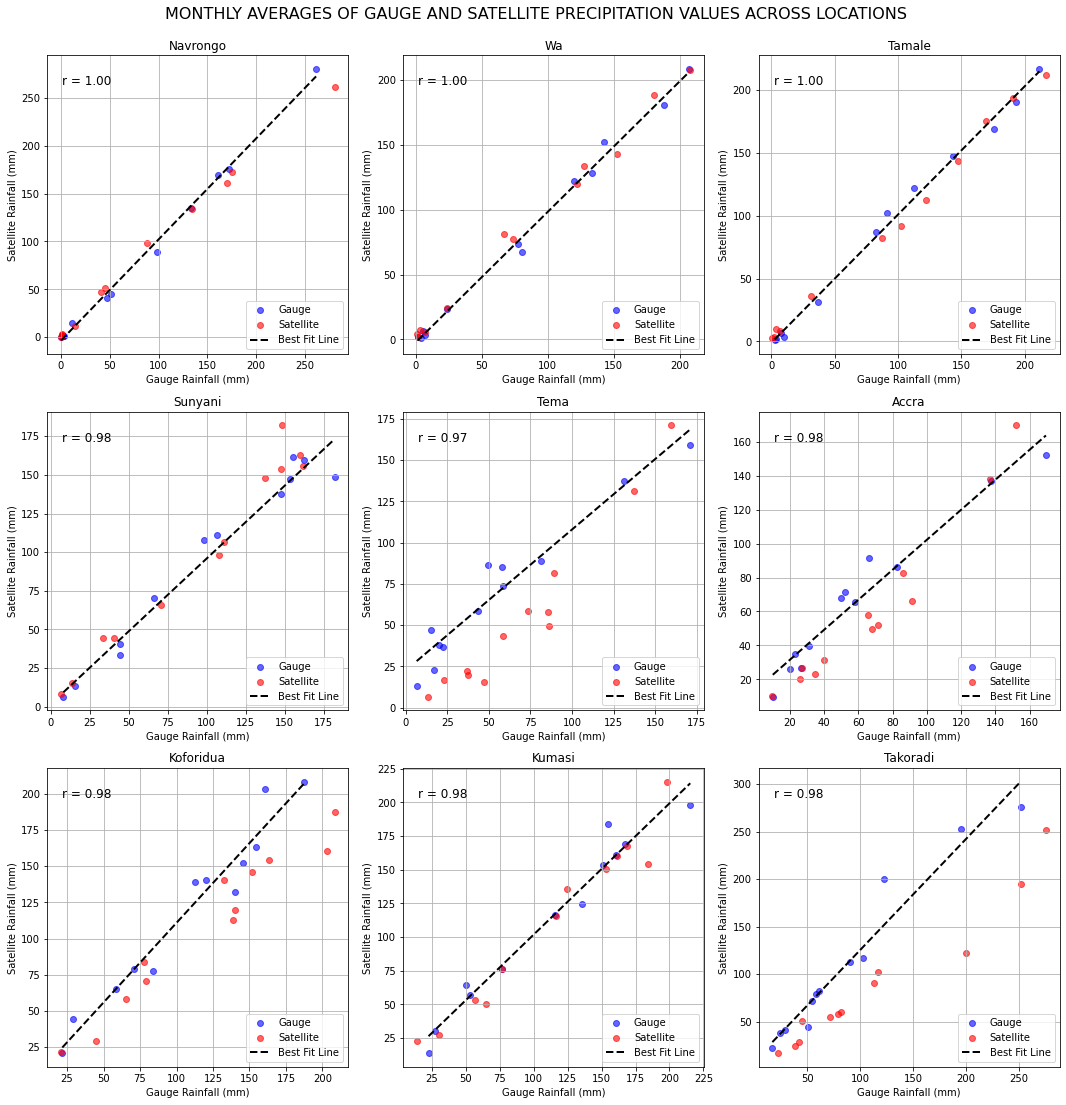

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

# Define locations and corresponding files
locations = ["Navrongo", "Wa", "Tamale", "Sunyani", "Tema", "Accra", "Koforidua", "Kumasi", "Takoradi"]
gauge_files = {loc: f"{loc}_1981_2016_dRR_cgf.txt" for loc in locations}
sat_files = {loc: f"{loc}_1981_2016_dRR_sat.txt" for loc in locations}

# Load data
gauge_data = {loc: pd.read_csv(gauge_files[loc], delim_whitespace=True, names=['year', 'month', 'day', 'RR']) 
              for loc in locations}
sat_data = {loc: pd.read_csv(sat_files[loc], delim_whitespace=True, names=['year', 'month', 'day', 'RR']) 
            for loc in locations}

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, loc in enumerate(locations):
    # Merge gauge and satellite datasets
    merged_df = pd.merge(gauge_data[loc], sat_data[loc], on=['year', 'month', 'day'], suffixes=('_gauge', '_sat'))
    
    # Aggregate by month
    #monthly_df = merged_df.groupby("month")[["RR_gauge", "RR_sat"]].sum().reset_index()
  
    
    # Compute monthly total rainfall
    monthly_total = merged_df.groupby(["year", "month"])[["RR_gauge", "RR_sat"]].sum().reset_index()
    
    # Compute monthly mean rainfall (divide by number of years)
    num_years = len(monthly_total["year"].unique())  # Number of years in dataset
    monthly_df = monthly_total.groupby("month")[["RR_gauge", "RR_sat"]].sum() / num_years  # Monthly mean
    
    
    
      # Compute correlation
    correlation = monthly_df["RR_gauge"].corr(monthly_df["RR_sat"])
    
    # Scatter plot
    axes[i].scatter(monthly_df["RR_gauge"], monthly_df["RR_sat"], color='blue', label="Gauge", alpha=0.6)
    axes[i].scatter(monthly_df["RR_sat"], monthly_df["RR_gauge"], color='red', label="Satellite", alpha=0.6)
    
     # Compute and plot line of best fit
    m, b = np.polyfit(monthly_df["RR_gauge"], monthly_df["RR_sat"], 1)  # Linear fit (y = mx + b)
    x_fit = np.linspace(monthly_df["RR_gauge"].min(), monthly_df["RR_gauge"].max(), 100)
    y_fit = m * x_fit + b
    axes[i].plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, label="Best Fit Line")
    
    # Labels and title
    axes[i].set_xlabel("Gauge Rainfall (mm)", fontsize=10)
    axes[i].set_ylabel("Satellite Rainfall (mm)")
    axes[i].set_title(f"{loc}", fontsize=12)
    
    # Annotate correlation coefficient
    axes[i].text(0.05, 0.9, f"r = {correlation:.2f}", transform=axes[i].transAxes, fontsize=12, color="black")
    
    axes[i].grid(True)
    axes[i].legend(loc='lower right')

plt.tight_layout()
plt.suptitle("MONTHLY AVERAGES OF GAUGE AND SATELLITE PRECIPITATION VALUES ACROSS LOCATIONS", fontsize=16, y=1.02)
plt.savefig('MONTHLY_All_Locations.png', bbox_inches='tight', dpi=800)
plt.show()


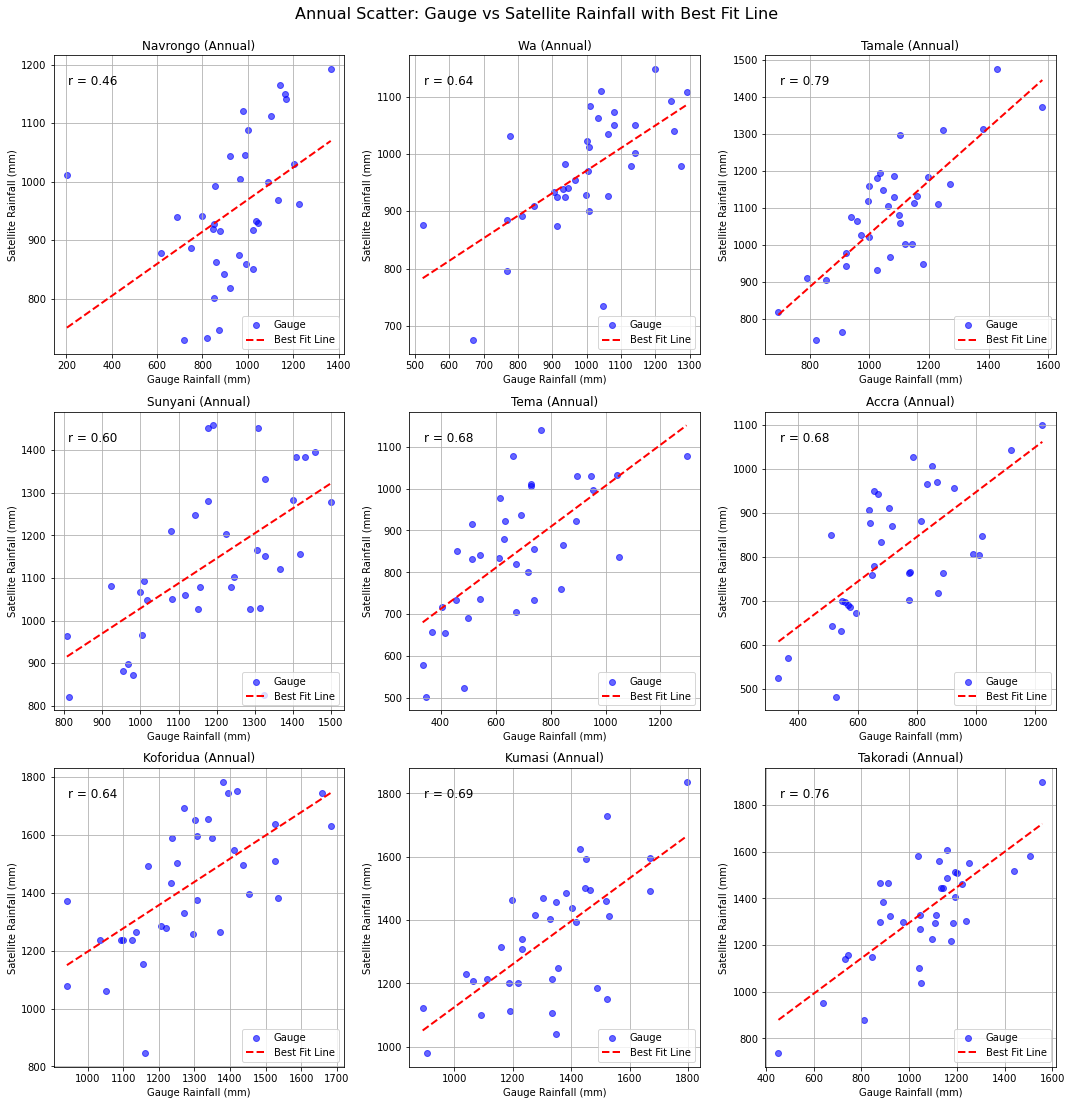

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, loc in enumerate(locations):
    # Merge gauge and satellite datasets
    merged_df = pd.merge(gauge_data[loc], sat_data[loc], on=['year', 'month', 'day'], suffixes=('_gauge', '_sat'))
    
    # Aggregate by year
    annual_df = merged_df.groupby("year")[["RR_gauge", "RR_sat"]].sum().reset_index()
    
    # Compute correlation
    correlation = annual_df["RR_gauge"].corr(annual_df["RR_sat"])
    
    # Scatter plot
    axes[i].scatter(annual_df["RR_gauge"], annual_df["RR_sat"], color='blue', label="Gauge", alpha=0.6)
    
    # Compute and plot line of best fit
    m, b = np.polyfit(annual_df["RR_gauge"], annual_df["RR_sat"], 1)  # Linear fit (y = mx + b)
    x_fit = np.linspace(annual_df["RR_gauge"].min(), annual_df["RR_gauge"].max(), 100)
    y_fit = m * x_fit + b
    axes[i].plot(x_fit, y_fit, color="red", linestyle="--", linewidth=2, label="Best Fit Line")
    
    # Labels and title
    axes[i].set_xlabel("Gauge Rainfall (mm)", fontsize=10)
    axes[i].set_ylabel("Satellite Rainfall (mm)", fontsize=10)
    axes[i].set_title(f"{loc} (Annual)", fontsize=12)
    
    # Annotate correlation coefficient
    axes[i].text(0.05, 0.9, f"r = {correlation:.2f}", transform=axes[i].transAxes, fontsize=12, color="black")
    
    axes[i].grid(True)
    axes[i].legend(loc='lower right')

plt.tight_layout()
plt.suptitle("Annual Scatter: Gauge vs Satellite Rainfall with Best Fit Line", fontsize=16, y=1.02)
plt.show()


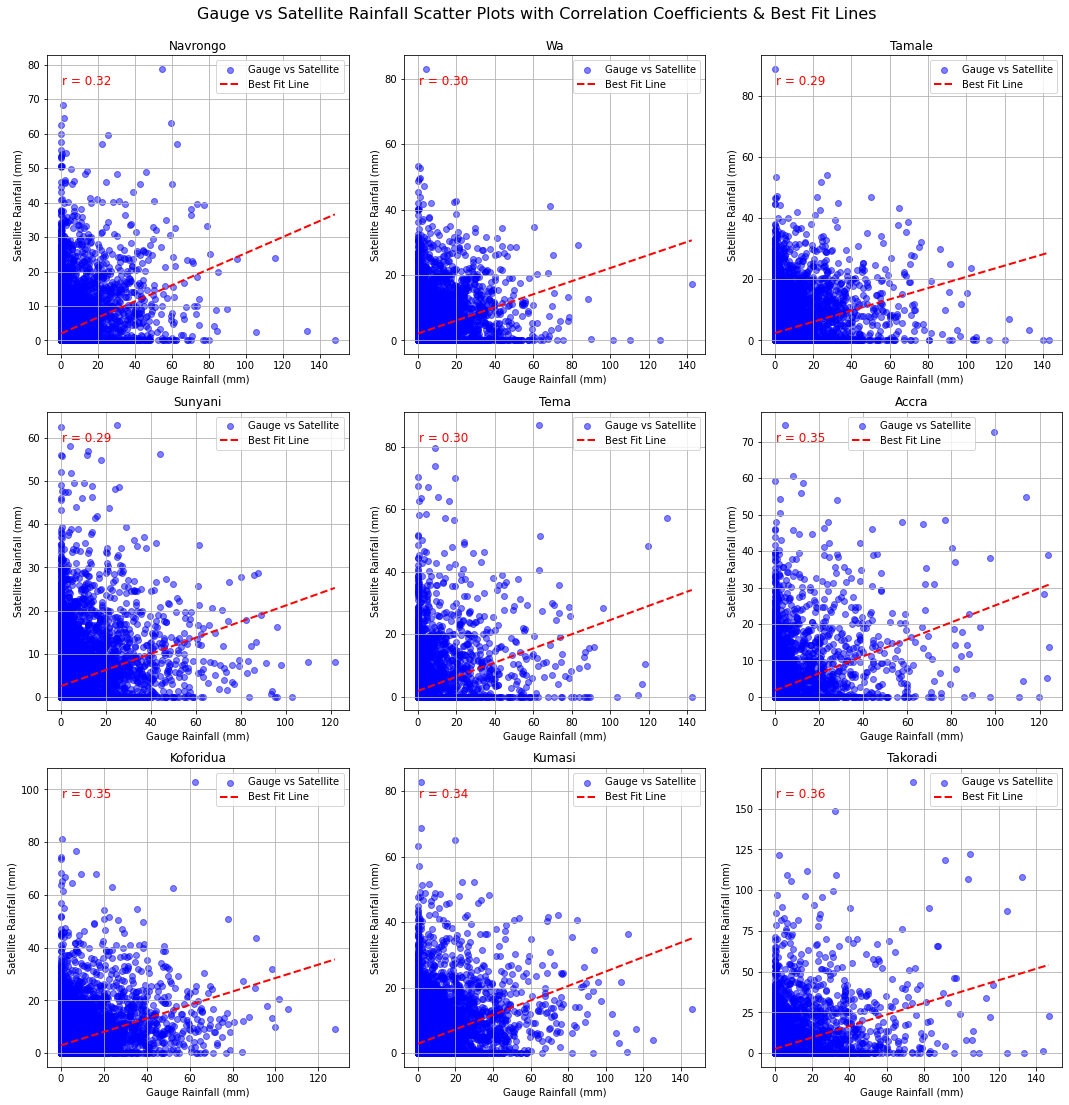

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define locations and corresponding files
locations = ["Navrongo", "Wa", "Tamale", "Sunyani", "Tema", "Accra", "Koforidua", "Kumasi", "Takoradi"]
gauge_files = [f"{loc}_1981_2016_dRR_cgf.txt" for loc in locations]
sat_files = [f"{loc}_1981_2016_dRR_sat.txt" for loc in locations]

# Load data into dictionaries
gauge_data = {loc: pd.read_csv(gauge_file, delim_whitespace=True, names=['year', 'month', 'day', 'RR'])
              for loc, gauge_file in zip(locations, gauge_files)}

sat_data = {loc: pd.read_csv(sat_file, delim_whitespace=True, names=['year', 'month', 'day', 'RR'])
            for loc, sat_file in zip(locations, sat_files)}

# Initialize plot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # 3x3 subplot grid
axes = axes.flatten()

for i, loc in enumerate(locations):
    # Merge gauge and satellite datasets on year, month, and day
    merged_df = pd.merge(gauge_data[loc], sat_data[loc], on=['year', 'month', 'day'], suffixes=('_gauge', '_sat'))
    
    # Compute correlation
    correlation = merged_df["RR_gauge"].corr(merged_df["RR_sat"])
    
    # Scatter plot
    axes[i].scatter(merged_df["RR_gauge"], merged_df["RR_sat"], alpha=0.5, color="blue", label="Gauge vs Satellite")
    
    # Compute and plot line of best fit
    m, b = np.polyfit(merged_df["RR_gauge"], merged_df["RR_sat"], 1)  # Linear fit (y = mx + b)
    x_fit = np.linspace(merged_df["RR_gauge"].min(), merged_df["RR_gauge"].max(), 100)
    y_fit = m * x_fit + b
    axes[i].plot(x_fit, y_fit, color="red", linestyle="--", linewidth=2, label="Best Fit Line")
    
    # Add labels and title
    axes[i].set_xlabel("Gauge Rainfall (mm)", fontsize=10)
    axes[i].set_ylabel("Satellite Rainfall (mm)", fontsize=10)
    axes[i].set_title(f"{loc}", fontsize=12)
    
    # Annotate correlation coefficient
    axes[i].text(0.05, 0.9, f"r = {correlation:.2f}", transform=axes[i].transAxes, fontsize=12, color="red")
    
    axes[i].grid(True)
    axes[i].legend()

# Adjust layout
plt.tight_layout()
plt.suptitle("Gauge vs Satellite Rainfall Scatter Plots with Correlation Coefficients & Best Fit Lines", fontsize=16, y=1.02)
plt.show()


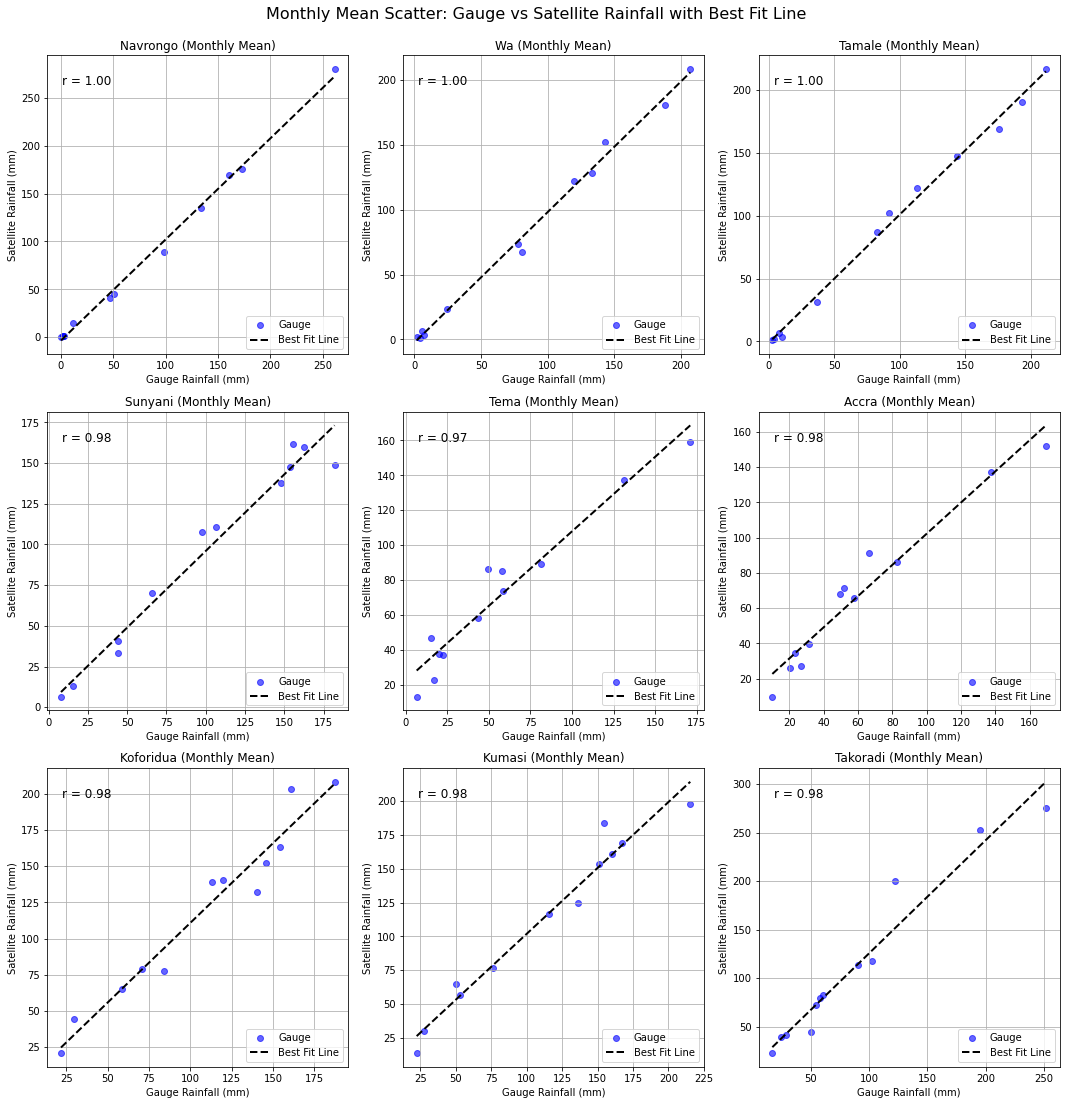

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define locations and corresponding files
locations = ["Navrongo", "Wa", "Tamale", "Sunyani", "Tema", "Accra", "Koforidua", "Kumasi", "Takoradi"]
gauge_files = {loc: f"{loc}_1981_2016_dRR_cgf.txt" for loc in locations}
sat_files = {loc: f"{loc}_1981_2016_dRR_sat.txt" for loc in locations}

# Load data
gauge_data = {loc: pd.read_csv(gauge_files[loc], delim_whitespace=True, names=['year', 'month', 'day', 'RR']) 
              for loc in locations}
sat_data = {loc: pd.read_csv(sat_files[loc], delim_whitespace=True, names=['year', 'month', 'day', 'RR']) 
            for loc in locations}

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, loc in enumerate(locations):
    # Merge gauge and satellite datasets
    merged_df = pd.merge(gauge_data[loc], sat_data[loc], on=['year', 'month', 'day'], suffixes=('_gauge', '_sat'))
    
    # Compute monthly total rainfall
    monthly_total = merged_df.groupby(["year", "month"])[["RR_gauge", "RR_sat"]].sum().reset_index()
    
    # Compute monthly mean rainfall (divide by number of years)
    num_years = len(monthly_total["year"].unique())  # Number of years in dataset
    monthly_mean = monthly_total.groupby("month")[["RR_gauge", "RR_sat"]].sum() / num_years  # Monthly mean
    
    # Compute correlation
    correlation = monthly_mean["RR_gauge"].corr(monthly_mean["RR_sat"])
    
    # Scatter plot
    axes[i].scatter(monthly_mean["RR_gauge"], monthly_mean["RR_sat"], color='blue', label="Gauge", alpha=0.6)
    
    # Compute and plot line of best fit
    m, b = np.polyfit(monthly_mean["RR_gauge"], monthly_mean["RR_sat"], 1)  # Linear fit (y = mx + b)
    x_fit = np.linspace(monthly_mean["RR_gauge"].min(), monthly_mean["RR_gauge"].max(), 100)
    y_fit = m * x_fit + b
    axes[i].plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, label="Best Fit Line")
    
    # Labels and title
    axes[i].set_xlabel("Gauge Rainfall (mm)", fontsize=10)
    axes[i].set_ylabel("Satellite Rainfall (mm)", fontsize=10)
    axes[i].set_title(f"{loc} (Monthly Mean)", fontsize=12)
    
    # Annotate correlation coefficient
    axes[i].text(0.05, 0.9, f"r = {correlation:.2f}", transform=axes[i].transAxes, fontsize=12, color="black")
    
    axes[i].grid(True)
    axes[i].legend(loc='lower right')

plt.tight_layout()
plt.suptitle("Monthly Mean Scatter: Gauge vs Satellite Rainfall with Best Fit Line", fontsize=16, y=1.02)
plt.show()


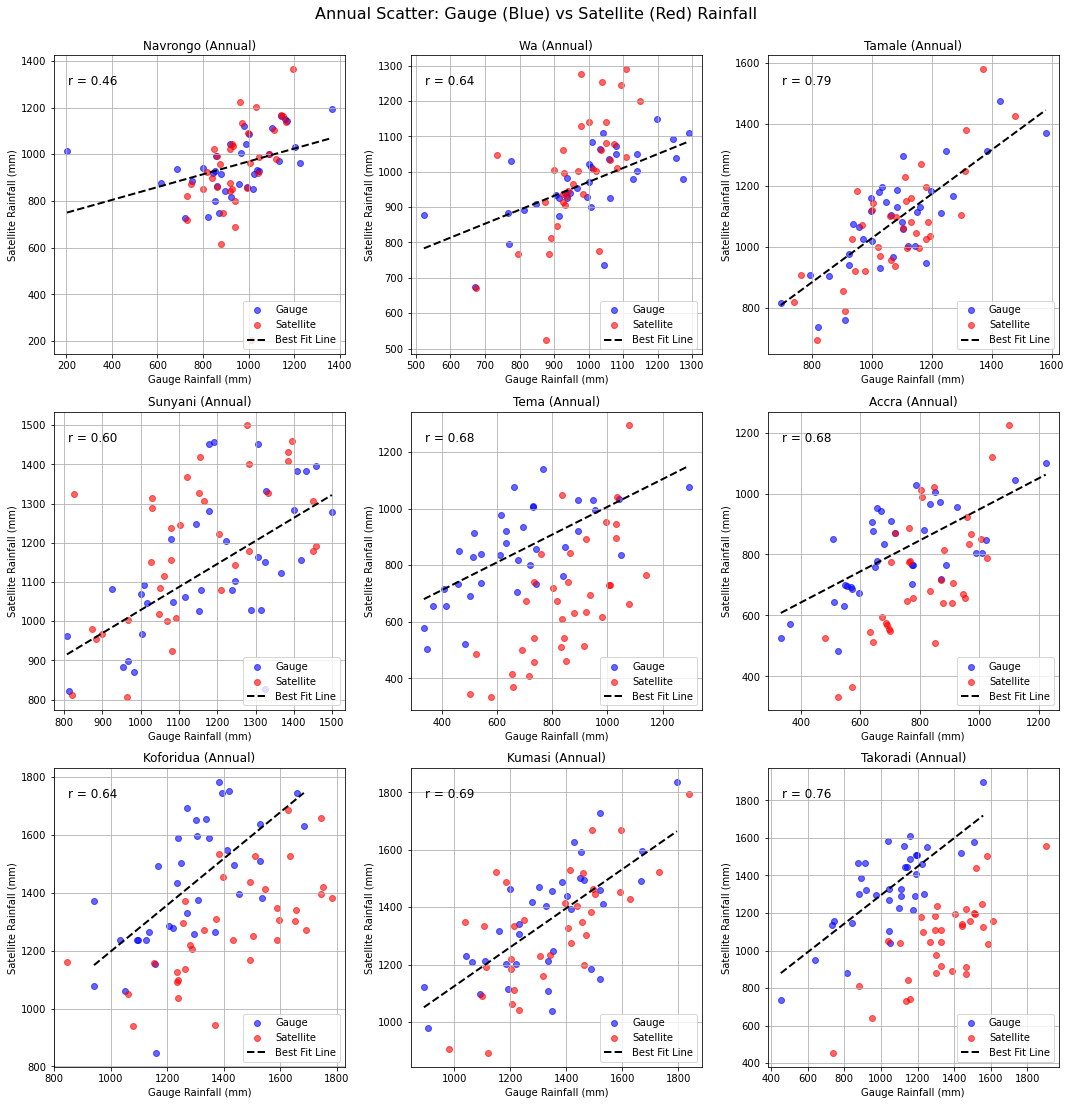

In [99]:
# Create figure
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, loc in enumerate(locations):
    # Merge gauge and satellite datasets
    merged_df = pd.merge(gauge_data[loc], sat_data[loc], on=['year', 'month', 'day'], suffixes=('_gauge', '_sat'))
    
    # Aggregate by year
    annual_df = merged_df.groupby("year")[["RR_gauge", "RR_sat"]].sum().reset_index()
    
    # Compute correlation
    correlation = annual_df["RR_gauge"].corr(annual_df["RR_sat"])
    
    # Scatter plot
    axes[i].scatter(annual_df["RR_gauge"], annual_df["RR_sat"], color='blue', label="Gauge", alpha=0.6)
    axes[i].scatter(annual_df["RR_sat"], annual_df["RR_gauge"], color='red', label="Satellite", alpha=0.6)
    
     # Compute and plot line of best fit
    m, b = np.polyfit(annual_df["RR_gauge"], annual_df["RR_sat"], 1)  # Linear fit (y = mx + b)
    x_fit = np.linspace(annual_df["RR_gauge"].min(), annual_df["RR_gauge"].max(), 100)
    y_fit = m * x_fit + b
    axes[i].plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, label="Best Fit Line")
    
    # Labels and title
    axes[i].set_xlabel("Gauge Rainfall (mm)", fontsize=10)
    axes[i].set_ylabel("Satellite Rainfall (mm)", fontsize=10)
    axes[i].set_title(f"{loc} (Annual)", fontsize=12)
    
    # Annotate correlation coefficient
    axes[i].text(0.05, 0.9, f"r = {correlation:.2f}", transform=axes[i].transAxes, fontsize=12, color="black")
    
    axes[i].grid(True)
    axes[i].legend(loc='lower right')

plt.tight_layout()
plt.suptitle("Annual Scatter: Gauge (Blue) vs Satellite (Red) Rainfall", fontsize=16, y=1.02)
plt.show()


In [ ]:
import pandas as pd

# Load the data
dforest = pd.read_csv('DForest.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
dforest[['day', 'month', 'year']] = dforest['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
dforest['day'] = dforest['day'].astype(int)
dforest['month'] = dforest['month'].astype(int)
dforest['year'] = dforest['year'].astype(int)
dforest = dforest.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in dforest.columns if col not in ['day', 'month', 'year']]
dforest = dforest[columns_order]
dforest.to_csv('dforst.csv')
# Load the data
dcoastal = pd.read_csv('DCoastal.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
dcoastal[['day', 'month', 'year']] = dcoastal['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
dcoastal['day'] = dcoastal['day'].astype(int)
dcoastal['month'] = dcoastal['month'].astype(int)
dcoastal['year'] = dcoastal['year'].astype(int)
dcoastal = dcoastal.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in dcoastal.columns if col not in ['day', 'month', 'year']]
dcoastal = dcoastal[columns_order]
dcoastal.to_csv('dcoast.csv')

# Load the data
kin = pd.read_csv('KINTAMP.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
kin[['day', 'month', 'year']] = kin['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
kin['day'] = kin['day'].astype(int)
kin['month'] = kin['month'].astype(int)
kin['year'] = kin['year'].astype(int)
kin = kin.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in kin.columns if col not in ['day', 'month', 'year']]
kin = kin[columns_order]
kin.to_csv('Kin.csv')

# Load the data
Nav = pd.read_csv('NAV.txt', delim_whitespace=True)

# Split the DD/MM/YY column into day, month, and year
Nav[['day', 'month', 'year']] = Nav['DD/MM/YY'].str.split('/', expand=True)

# Convert the columns to integers for further processing, if needed
Nav['day'] = Nav['day'].astype(int)
Nav['month'] = Nav['month'].astype(int)
Nav['year'] = Nav['year'].astype(int)
Nav = Nav.drop(columns=['DD/MM/YY'])
# Reorder the columns to bring day, month, and year to the beginning
columns_order = ['day', 'month', 'year'] + [col for col in Nav.columns if col not in ['day', 'month', 'year']]
Nav = Nav[columns_order]
Nav.to_csv('Nav.csv')